# Evaluating Hallucination, Accuracy, and Misinformation in Large Language Models for Medical Question Answering

## A Comparative Study of Retrieval-Augmented Generation and Citation Prompting

**Dataset:** [MedHAM on HuggingFace](https://huggingface.co/datasets/Hussam-q/MedHAM)

---

This notebook provides a complete analysis of the **MedHAM** benchmark — a multi-layer evaluation dataset
measuring hallucination, accuracy, and misinformation in four large language models answering
1,000 evidence-based medical questions under a 2×2 factorial experimental design.

The evaluation pipeline combines five automated layers (BioBERT semantic similarity, MedNLI inference,
CrossRef/PubMed citation verification, FActScore atomic claim grounding, and a 4-judge blind LLM panel)
following Verga et al. (2024).


---

## Research Questions and Hypotheses

| ID | Full Statement |
|---|---|
| **RQ1** | To what extent do large language models produce hallucinated, inaccurate, and medically misinformative responses when answering evidence-based medical questions? |
| **RQ2** | How do retrieval-augmented generation and citation prompting — separately and together — affect hallucination, accuracy, and misinformation in large language model responses to medical questions, and do these effects differ across models and question difficulty levels? |
| **H2.1** | Retrieval-augmented generation will reduce hallucination and misinformation rates and improve accuracy scores relative to the no-retrieval baseline. |
| **H2.2** | The effect of retrieval augmentation and citation prompting on hallucination and misinformation rates and accuracy scores will be stronger for smaller models than for larger models. |
| **H2.3** | Citation prompting will reduce hallucination and misinformation rates and improve accuracy scores relative to zero-shot prompting. |
| **H2.4** | The combination of retrieval-augmented generation and citation prompting will yield lower hallucination and misinformation rates and higher accuracy scores than retrieval augmentation or citation prompting applied independently. |

---

## Experimental Design — 2×2 Factorial

| Prompt Format | No RAG | RAG |
|---|---|---|
| **Zero-Shot** | ZS\_NoRAG *(baseline)* | ZS\_RAG |
| **Citation-Required** | CIT\_NoRAG | CIT\_RAG |

**Tested Models (4):**
- GPT-4o (`gpt-4o-2024-11-20`) — Commercial Large
- Claude Sonnet 4.6 (`claude-sonnet-4-6`) — Commercial Large
- Gemini 2.5 Flash (`gemini-2.5-flash`) — Commercial Large
- Llama 3.1 8B (`llama-3.1-8b-instant`) — Open Source Small

**Judge Panel (4, blind):** GPT-4o · Claude Sonnet 4.6 · Gemini 2.5 Flash · DeepSeek V4 Flash
(DeepSeek is independent — it evaluated all models but was never itself evaluated)

---

## Dataset Structure

| Table | Rows | Description |
|---|---|---|
| `benchmark_items` | 1,000 | Medical questions + ground truths (MedHallu pqa_labeled) |
| `models` | 5 | LLMs used as tested models and/or judges |
| `prompt_strategies` | 4 | 2×2 factorial conditions |
| `rag_contexts` | 1,000 | Retrieved PubMed context per question |
| `model_responses` | 16,000 | Raw LLM responses — 4 models × 4 strategies × 1,000 questions |
| `evaluation_signals` | 16,000 | Automated signals: BioBERT, NLI, citations, FActScore |
| `judge_evaluations` | 64,000 | Per-judge votes — 4 judges × 16,000 responses |
| `evaluation_results` | 16,000 | Final aggregated labels: accuracy, hallucination, misinformation |


---
## Setup

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal
from statsmodels.stats.inter_rater import fleiss_kappa
import scipy
import statsmodels
import sys
from itertools import combinations

os.makedirs('charts', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.frameon': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.constrained_layout.use': False,
})

MODEL_COLORS = {
    'GPT-4o':           '#1B3A5C',
    'Claude Sonnet':    '#C4A882',
    'Gemini 2.5 Flash': '#C4687A',
    'Llama 3.1 8B':     '#2D6A4F',
}
COND_COLORS = {
    'ZS_NoRAG':  '#C4A882',
    'ZS_RAG':    '#C4687A',
    'CIT_NoRAG': '#2D6A4F',
    'CIT_RAG':   '#1B3A5C',
}

OUTCOME_COLORS = {
    'hallucination':     '#C4687A',
    'no_hallucination':  '#1B3A5C',
    'misinformation':    '#C4A882',
    'no_misinformation': '#1B3A5C',
    'inaccurate':        '#C4687A',
    'partial':           '#C4A882',
    'accurate':          '#1B3A5C',
    'real_citation':     '#1B3A5C',
    'fake_citation':     '#C4687A',
    'rag':               '#1B3A5C',
    'no_rag':            '#C4A882',
    'improvement':       '#1B3A5C',
    'worsening':         '#C4687A',
}

MODEL_ORDER = ['GPT-4o', 'Claude Sonnet', 'Gemini 2.5 Flash', 'Llama 3.1 8B']
COND_ORDER  = ['ZS_NoRAG', 'ZS_RAG', 'CIT_NoRAG', 'CIT_RAG']



RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def rank_biserial(u, n1, n2):
    """Rank-biserial correlation for Mann-Whitney U."""
    return 1 - (2 * u) / (n1 * n2)

def cramers_v(chi2, n, k):
    return np.sqrt(chi2 / (n * (k - 1))) if n and k > 1 else np.nan

def interpret_r(r):
    r = abs(r)
    if r < 0.1: return 'negligible'
    if r < 0.3: return 'small'
    if r < 0.5: return 'moderate'
    return 'large'

def interpret_v(v):
    return interpret_r(v)

def clustered_bootstrap_ci(df_in, value_col, cluster_col='item_id', statistic=np.mean, n_resamples=1000, ci=0.95):
    """Clustered bootstrap CI that resamples items rather than individual rows."""
    rng = np.random.default_rng(RANDOM_SEED)
    clusters = pd.Series(df_in[cluster_col].dropna().unique())
    if len(clusters) == 0:
        return np.nan, np.nan
    grouped = {c: g for c, g in df_in.groupby(cluster_col)}
    boot_stats = []
    for _ in range(n_resamples):
        sampled_clusters = rng.choice(clusters, size=len(clusters), replace=True)
        boot_sample = pd.concat([grouped[c] for c in sampled_clusters], ignore_index=True)
        boot_stats.append(statistic(boot_sample[value_col].dropna()))
    alpha = (1 - ci) / 2
    return np.percentile(boot_stats, [alpha * 100, (1 - alpha) * 100])

def fleiss_matrix_from_votes(judge_votes, response_col, vote_col):
    vote_table = judge_votes.pivot_table(index=response_col, columns='judge_label', values=vote_col, aggfunc='first')
    vote_table = vote_table.dropna()
    categories = sorted(pd.Series(vote_table.values.ravel()).dropna().unique())
    matrix = np.array([(vote_table == cat).sum(axis=1).values for cat in categories]).T
    return matrix

def kappa_interpretation(kappa):
    if kappa < 0: return 'Poor'
    if kappa < 0.2: return 'Slight'
    if kappa < 0.4: return 'Fair'
    if kappa < 0.6: return 'Moderate'
    if kappa < 0.8: return 'Substantial'
    return 'Strong'

def add_chart_subtitle(ax, text):
    ax.text(0.5, 1.02, text, transform=ax.transAxes, ha='center', va='bottom',
            fontsize=9, color='#7f7f7f', style='italic')

from matplotlib.axes import Axes
_ORIG_AXES_LEGEND = Axes.legend
_ORIG_AXES_SET_TITLE = Axes.set_title
_ORIG_SAVEFIG = plt.savefig
_ORIG_SHOW = plt.show

def _subtitle_text(title):
    lower = str(title).lower()
    if 'hallucination' in lower:
        return 'Lower values indicate fewer hallucinated responses'
    if 'accuracy' in lower:
        return 'Higher values indicate more accurate responses'
    if 'misinformation' in lower:
        return 'Lower values indicate less medical misinformation'
    if 'delta' in lower or 'effect' in lower:
        return 'Negative values indicate reduction attributable to treatment'
    return None

def _add_interpretive_subtitle(ax, title):
    text = _subtitle_text(title)
    key = f'_subtitle_added_{hash(str(title))}'
    if text and not getattr(ax, key, False):
        ax.text(0.5, -0.22, text,
                transform=ax.transAxes, ha='center',
                fontsize=8, color='#6b7280', style='italic', clip_on=False)
        setattr(ax, key, True)

def _medham_set_title(self, label, *args, **kwargs):
    result = _ORIG_AXES_SET_TITLE(self, label, *args, **kwargs)
    _add_interpretive_subtitle(self, label)
    return result

def _medham_legend(self, *args, **kwargs):
    kwargs['bbox_to_anchor'] = (1.01, 1)
    kwargs['loc'] = 'upper left'
    kwargs['borderaxespad'] = 0
    kwargs['frameon'] = False
    return _ORIG_AXES_LEGEND(self, *args, **kwargs)

Axes.set_title = _medham_set_title
Axes.legend = _medham_legend

def standardize_figure(fig=None):
    fig = fig or plt.gcf()
    for ax in [a for a in fig.axes if hasattr(a, 'get_legend')]:
        ax.set_facecolor('white')
        leg = ax.get_legend()
        if leg is not None:
            leg.set_bbox_to_anchor((1.01, 1), transform=ax.transAxes)
            leg._loc = 2
            leg.set_frame_on(False)
    try:
        plt.tight_layout(rect=[0, 0.07, 0.82, 1])
    except Exception:
        pass
    return fig

def _medham_savefig(*args, **kwargs):
    standardize_figure(plt.gcf())
    kwargs.setdefault('bbox_inches', 'tight')
    kwargs.setdefault('facecolor', 'white')
    return _ORIG_SAVEFIG(*args, **kwargs)

def _medham_show(*args, **kwargs):
    standardize_figure(plt.gcf())
    return _ORIG_SHOW(*args, **kwargs)

plt.savefig = _medham_savefig
plt.show = _medham_show

print("Setup complete.")

from matplotlib.colors import LinearSegmentedColormap
ROSE_CMAP = LinearSegmentedColormap.from_list(
    "navy_gradient",
    ["#EBF5FB", "#BADDF5", "#74AEDA", "#3D7AB0", "#285480", "#1B3A5C"]
)
ROSE_CMAP_R = ROSE_CMAP.reversed()


Setup complete.


---
## Statistical Test Justification

*Explains why non-parametric tests, effect sizes, and clustered uncertainty estimates are used.*

Non-parametric tests (Mann-Whitney U, Kruskal-Wallis) are used throughout because `accuracy_consensus` is an ordinal 0-2 scale and hallucination/misinformation are binary; neither satisfies the normality assumption required for t-tests or ANOVA. Bonferroni correction is applied for all pairwise comparisons. Effect sizes are reported alongside all p-values because with N=16,000 observations, even negligible effects can reach statistical significance.

All inferential tests treat observations as independent. Because the same 1,000 items appear across 16,000 responses, this assumption is violated: observations are clustered by `item_id`. Clustered bootstrap CIs partially address this. A fully rigorous analysis would use mixed-effects models with random intercepts for `item_id`. P-values should be interpreted alongside effect sizes.


In [2]:
print("=== Reproducibility ===")
print(f"Python: {sys.version}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"statsmodels: {statsmodels.__version__}")
print(f"Random seed: {RANDOM_SEED}")
print("Dataset: Hussam-q/MedHAM (HuggingFace, CC-BY-4.0)")


=== Reproducibility ===
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pandas: 3.0.1
numpy: 2.4.3
scipy: 1.17.1
statsmodels: 0.14.6
Random seed: 42
Dataset: Hussam-q/MedHAM (HuggingFace, CC-BY-4.0)


---
## 1. Load Data from HuggingFace

*Loads the MedHAM tables, preferring the local parquet export when available so the notebook remains reproducible offline.*


In [3]:
from pathlib import Path

REPO = "Hussam-q/MedHAM"
LOCAL_EXPORT = Path("hf_upload")

print("Loading MedHAM tables...")

def _load(config):
    local_file = LOCAL_EXPORT / f"{config}.parquet"
    if local_file.exists():
        print(f"  using local {local_file}")
        return pd.read_parquet(local_file)
    from datasets import load_dataset
    return load_dataset(REPO, config, split="train", trust_remote_code=False).to_pandas()

items     = _load("benchmark_items")
models_df = _load("models")
strats    = _load("prompt_strategies")
rag_ctx   = _load("rag_contexts")
responses = _load("model_responses")
signals   = _load("evaluation_signals")
judges    = _load("judge_evaluations")
results   = _load("evaluation_results")

for name, tbl in [
    ('benchmark_items',    items),
    ('models',             models_df),
    ('prompt_strategies',  strats),
    ('rag_contexts',       rag_ctx),
    ('model_responses',    responses),
    ('evaluation_signals', signals),
    ('judge_evaluations',  judges),
    ('evaluation_results', results),
]:
    print(f"  {name:<25} {len(tbl):>7,} rows")
print(f"\n  Total: {len(items)+len(models_df)+len(strats)+len(rag_ctx)+len(responses)+len(signals)+len(judges)+len(results):,} rows")


Loading MedHAM tables...
  using local hf_upload\benchmark_items.parquet
  using local hf_upload\models.parquet
  using local hf_upload\prompt_strategies.parquet
  using local hf_upload\rag_contexts.parquet
  using local hf_upload\model_responses.parquet
  using local hf_upload\evaluation_signals.parquet
  using local hf_upload\judge_evaluations.parquet
  using local hf_upload\evaluation_results.parquet
  benchmark_items             1,000 rows
  models                          5 rows
  prompt_strategies               4 rows
  rag_contexts                1,000 rows
  model_responses            16,000 rows
  evaluation_signals         16,000 rows
  judge_evaluations          64,000 rows
  evaluation_results         16,000 rows

  Total: 114,009 rows


---
## 2. Build Master Dataframe

*Constructs the response-level analysis dataframe and joins model, strategy, item, and automated signal metadata.*


In [4]:
# model_name in the DB uses display names (GPT-4o, Claude Sonnet 4.6, etc.)
# model_version uses API identifiers (gpt-4o-2024-11-20, etc.)
name_map = {
    'GPT-4o':            'GPT-4o',
    'Claude Sonnet 4.6': 'Claude Sonnet',
    'Gemini 2.5 Flash':  'Gemini 2.5 Flash',
    'Llama 3.1 8B':      'Llama 3.1 8B',
}

df = (
    results
    .merge(responses[['response_id','item_id','model_id','strategy_id']], on='response_id')
    .merge(models_df[['model_id','model_name','model_type']], on='model_id')
    .merge(strats[['strategy_id','strategy_name','rag_enabled']], on='strategy_id')
    .merge(items[['item_id','hallucination_category','difficulty']], on='item_id')
)

df['model_label']      = df['model_name'].map(name_map)
df['rag']              = df['rag_enabled'].fillna(0).astype(int).astype(bool)
df['citation']         = df['strategy_name'].str.startswith('CIT')
df['model_type_label'] = df['model_type'].map({
    'commercial_large':  'Commercial Large',
    'open_source_small': 'Open Source Small',
})
df = df[df['model_label'].notna()].copy()
df['hallucination_label']  = df['hallucination_label'].astype(int)
df['misinformation_label'] = df['misinformation_label'].astype(int)
df['accuracy_score']       = df['accuracy_score'].astype(int)

# signals joined separately — only used in the automated signals section
df_sig = df.merge(
    signals[['response_id','biobert_f1','factscore_f1',
             'misinfo_nli_signal','intrinsic_nli_signal',
             'citation_fake_count','citation_real_count',
             'citation_verdict','automated_track_verdict']],
    on='response_id', how='left'
)

print(f"Master df:   {len(df):,} rows x {df.shape[1]} columns")
print(f"Signals df:  {len(df_sig):,} rows  (signals cols have {df_sig['biobert_f1'].isna().sum():,} NaN)")
print(f"Models:      {df['model_label'].unique().tolist()}")
print(f"Conditions:  {df['strategy_name'].unique().tolist()}")
df.head(3)


Master df:   16,000 rows x 23 columns
Signals df:  16,000 rows  (signals cols have 0 NaN)
Models:      ['GPT-4o', 'Claude Sonnet', 'Gemini 2.5 Flash', 'Llama 3.1 8B']
Conditions:  ['ZS_NoRAG', 'ZS_RAG', 'CIT_NoRAG', 'CIT_RAG']


,result_id,response_id,accuracy_score,hallucination_label,misinformation_label,accuracy_consensus,hallucination_consensus,misinformation_consensus,track_consensus,labelled_at,...,model_name,model_type,strategy_name,rag_enabled,hallucination_category,difficulty,model_label,rag,citation,model_type_label
0,1,1,1,1,0,1.0,1.00,0.0,1,2026-04-29T06:58:42.225564+00:00,...,GPT-4o,commercial_large,ZS_NoRAG,0,Mechanism and Pathway Misattribution,medium,GPT-4o,False,False,Commercial Large
1,2,2,1,1,0,1.0,1.00,0.0,1,2026-04-29T06:58:42.225564+00:00,...,Claude Sonnet 4.6,commercial_large,ZS_NoRAG,0,Mechanism and Pathway Misattribution,medium,Claude Sonnet,False,False,Commercial Large
2,3,3,1,0,0,1.5,0.25,0.0,1,2026-04-29T14:53:35.571597+00:00,...,Gemini 2.5 Flash,commercial_large,ZS_NoRAG,0,Mechanism and Pathway Misattribution,medium,Gemini 2.5 Flash,False,False,Commercial Large


---
## Key Findings

*Highlights the headline results with concrete computed values for rapid assessment.*


In [5]:
# Programmatic executive summary with concrete values computed directly from the current dataset.
no_rag_exec = df[~df['rag']]
with_rag_exec = df[df['rag']]
u_h21_exec, p_h21_acc_exec = mannwhitneyu(
    with_rag_exec['accuracy_consensus'].dropna(),
    no_rag_exec['accuracy_consensus'].dropna(),
    alternative='two-sided'
)
r_h21_exec = rank_biserial(u_h21_exec, len(with_rag_exec), len(no_rag_exec))
h21_acc_delta_exec = with_rag_exec['accuracy_consensus'].mean() - no_rag_exec['accuracy_consensus'].mean()
h21_hallu_delta_exec = with_rag_exec['hallucination_label'].mean() - no_rag_exec['hallucination_label'].mean()

no_cit_exec = df[~df['citation']]
with_cit_exec = df[df['citation']]
u_h23_exec, p_h23_acc_exec = mannwhitneyu(
    with_cit_exec['accuracy_consensus'].dropna(),
    no_cit_exec['accuracy_consensus'].dropna(),
    alternative='two-sided'
)
r_h23_exec = rank_biserial(u_h23_exec, len(with_cit_exec), len(no_cit_exec))
chi2_h23_exec, p_h23_hallu_exec, _, _ = chi2_contingency(pd.crosstab(df['hallucination_label'], df['citation']))
v_h23_exec = cramers_v(chi2_h23_exec, len(df), 2)

cit_rag_summary_exec = (
    df[df['strategy_name'].eq('CIT_RAG')]
    .groupby('model_label')
    .agg(hallucination_rate=('hallucination_label', 'mean'),
         mean_accuracy=('accuracy_consensus', 'mean'))
    .reindex(MODEL_ORDER)
)
best_cit_rag_model_exec = cit_rag_summary_exec.sort_values(
    ['hallucination_rate', 'mean_accuracy'], ascending=[True, False]
).index[0]
best_cit_rag_hallu_exec = cit_rag_summary_exec.loc[best_cit_rag_model_exec, 'hallucination_rate']

judge_tmp = judges.merge(models_df[['model_id','model_name']], left_on='judge_id', right_on='model_id', how='left')
judge_tmp['judge_label'] = judge_tmp['model_name'].map({
    'GPT-4o': 'GPT-4o',
    'Claude Sonnet 4.6': 'Claude Sonnet',
    'Gemini 2.5 Flash': 'Gemini 2.5 Flash',
    'DeepSeek V4 Flash': 'DeepSeek V4 Flash',
}).fillna(judge_tmp['model_name'])
kappa_values_exec = {}
for metric, vote_col in [
    ('Hallucination', 'judge_hallucination_vote'),
    ('Misinformation', 'judge_misinformation_vote'),
    ('Accuracy', 'judge_accuracy_score'),
]:
    matrix = fleiss_matrix_from_votes(judge_tmp, 'response_id', vote_col)
    kappa_values_exec[metric] = fleiss_kappa(matrix, method='fleiss')

deepseek_votes_exec = judge_tmp[judge_tmp['judge_label'].eq('DeepSeek V4 Flash')]
deepseek_model_exec = deepseek_votes_exec.merge(
    df[['response_id','model_label']], on='response_id'
).groupby('model_label').agg(
    hallu_rate=('judge_hallucination_vote', 'mean'),
    acc_mean=('judge_accuracy_score', 'mean')
).reindex(MODEL_ORDER)
panel_model_exec = df.groupby('model_label').agg(
    hallu_rate=('hallucination_label', 'mean'),
    acc_mean=('accuracy_consensus', 'mean')
).reindex(MODEL_ORDER)
deepseek_hallu_gap_exec = (panel_model_exec['hallu_rate'] - deepseek_model_exec['hallu_rate']).abs().mean()
deepseek_acc_gap_exec = (panel_model_exec['acc_mean'] - deepseek_model_exec['acc_mean']).abs().mean()
deepseek_conclusion_exec = 'similar in model ordering, but not identical in absolute rates' if deepseek_hallu_gap_exec < 0.20 else 'meaningfully different in absolute rates'

difficulty_rows_exec = []
for difficulty, sub in df.groupby('difficulty'):
    accuracy_delta = sub[sub['rag']]['accuracy_consensus'].mean() - sub[~sub['rag']]['accuracy_consensus'].mean()
    hallu_delta = sub[sub['rag']]['hallucination_label'].mean() - sub[~sub['rag']]['hallucination_label'].mean()
    difficulty_rows_exec.append({'difficulty': difficulty, 'accuracy_delta': accuracy_delta, 'hallucination_delta': hallu_delta})
difficulty_delta_exec = pd.DataFrame(difficulty_rows_exec).sort_values('accuracy_delta', ascending=False)
top_difficulty_exec = difficulty_delta_exec.iloc[0]

print("=== Key Findings (computed) ===")
print(f"- RAG was associated with higher accuracy overall: delta={h21_acc_delta_exec:+.3f}, p={p_h21_acc_exec:.4g}, r={r_h21_exec:.3f} ({interpret_r(r_h21_exec)} effect). Hallucination rate also increased by {h21_hallu_delta_exec:+.3f}, so the benefit is accuracy-specific rather than uniformly safety-improving.")
print(f"- The lowest CIT_RAG hallucination rate was achieved by {best_cit_rag_model_exec}: {best_cit_rag_hallu_exec:.3f}.")
print(f"- Fleiss' Kappa values: hallucination={kappa_values_exec['Hallucination']:.3f} ({kappa_interpretation(kappa_values_exec['Hallucination'])}), misinformation={kappa_values_exec['Misinformation']:.3f} ({kappa_interpretation(kappa_values_exec['Misinformation'])}), accuracy={kappa_values_exec['Accuracy']:.3f} ({kappa_interpretation(kappa_values_exec['Accuracy'])}).")
print(f"- DeepSeek-only sensitivity was {deepseek_conclusion_exec}: mean absolute hallucination-rate gap={deepseek_hallu_gap_exec:.3f}, mean absolute accuracy gap={deepseek_acc_gap_exec:.3f}.")
print(f"- RAG accuracy benefit was largest for {top_difficulty_exec['difficulty']} questions: accuracy delta={top_difficulty_exec['accuracy_delta']:+.3f}; hallucination delta={top_difficulty_exec['hallucination_delta']:+.3f}.")
print(f"- Citation prompting: H2.3 hallucination association p={p_h23_hallu_exec:.4g}, V={v_h23_exec:.3f} ({interpret_v(v_h23_exec)} effect); accuracy p={p_h23_acc_exec:.4g}, r={r_h23_exec:.3f} ({interpret_r(r_h23_exec)} effect).")


=== Key Findings (computed) ===
- RAG was associated with higher accuracy overall: delta=+0.464, p=0, r=-0.432 (moderate effect). Hallucination rate also increased by +0.134, so the benefit is accuracy-specific rather than uniformly safety-improving.
- The lowest CIT_RAG hallucination rate was achieved by Gemini 2.5 Flash: 0.446.
- Fleiss' Kappa values: hallucination=0.500 (Moderate), misinformation=0.258 (Fair), accuracy=0.426 (Moderate).
- DeepSeek-only sensitivity was similar in model ordering, but not identical in absolute rates: mean absolute hallucination-rate gap=0.153, mean absolute accuracy gap=0.140.
- RAG accuracy benefit was largest for hard questions: accuracy delta=+0.573; hallucination delta=+0.110.
- Citation prompting: H2.3 hallucination association p=9.011e-248, V=0.266 (small effect); accuracy p=1.337e-15, r=0.072 (negligible effect).


---
## 3. Dataset Overview

*Summarises the overall distribution of hallucination, misinformation, and accuracy outcomes before hypothesis testing.*


In [6]:
h_rate = df['hallucination_label'].mean()
m_rate = df['misinformation_label'].mean()
acc0   = (df['accuracy_score'] == 0).mean()
acc1   = (df['accuracy_score'] == 1).mean()
acc2   = (df['accuracy_score'] == 2).mean()

print("=== Overall Outcome Rates (N=16,000) ===")
print(f"  Hallucination rate:      {h_rate:.1%}")
print(f"  Misinformation rate:     {m_rate:.1%}")
print(f"  Accuracy 0 (inaccurate): {acc0:.1%}")
print(f"  Accuracy 1 (partial):    {acc1:.1%}")
print(f"  Accuracy 2 (accurate):   {acc2:.1%}")
print(f"  Mean accuracy consensus: {df['accuracy_consensus'].mean():.3f} / 2.0")
print()
print("=== Balance Check ===")
print(df.groupby(['model_label','strategy_name']).size().unstack().to_string())


=== Overall Outcome Rates (N=16,000) ===
  Hallucination rate:      62.4%
  Misinformation rate:     6.7%
  Accuracy 0 (inaccurate): 19.2%
  Accuracy 1 (partial):    67.7%
  Accuracy 2 (accurate):   13.1%
  Mean accuracy consensus: 1.119 / 2.0

=== Balance Check ===
strategy_name     CIT_NoRAG  CIT_RAG  ZS_NoRAG  ZS_RAG
model_label                                           
Claude Sonnet          1000     1000      1000    1000
GPT-4o                 1000     1000      1000    1000
Gemini 2.5 Flash       1000     1000      1000    1000
Llama 3.1 8B           1000     1000      1000    1000


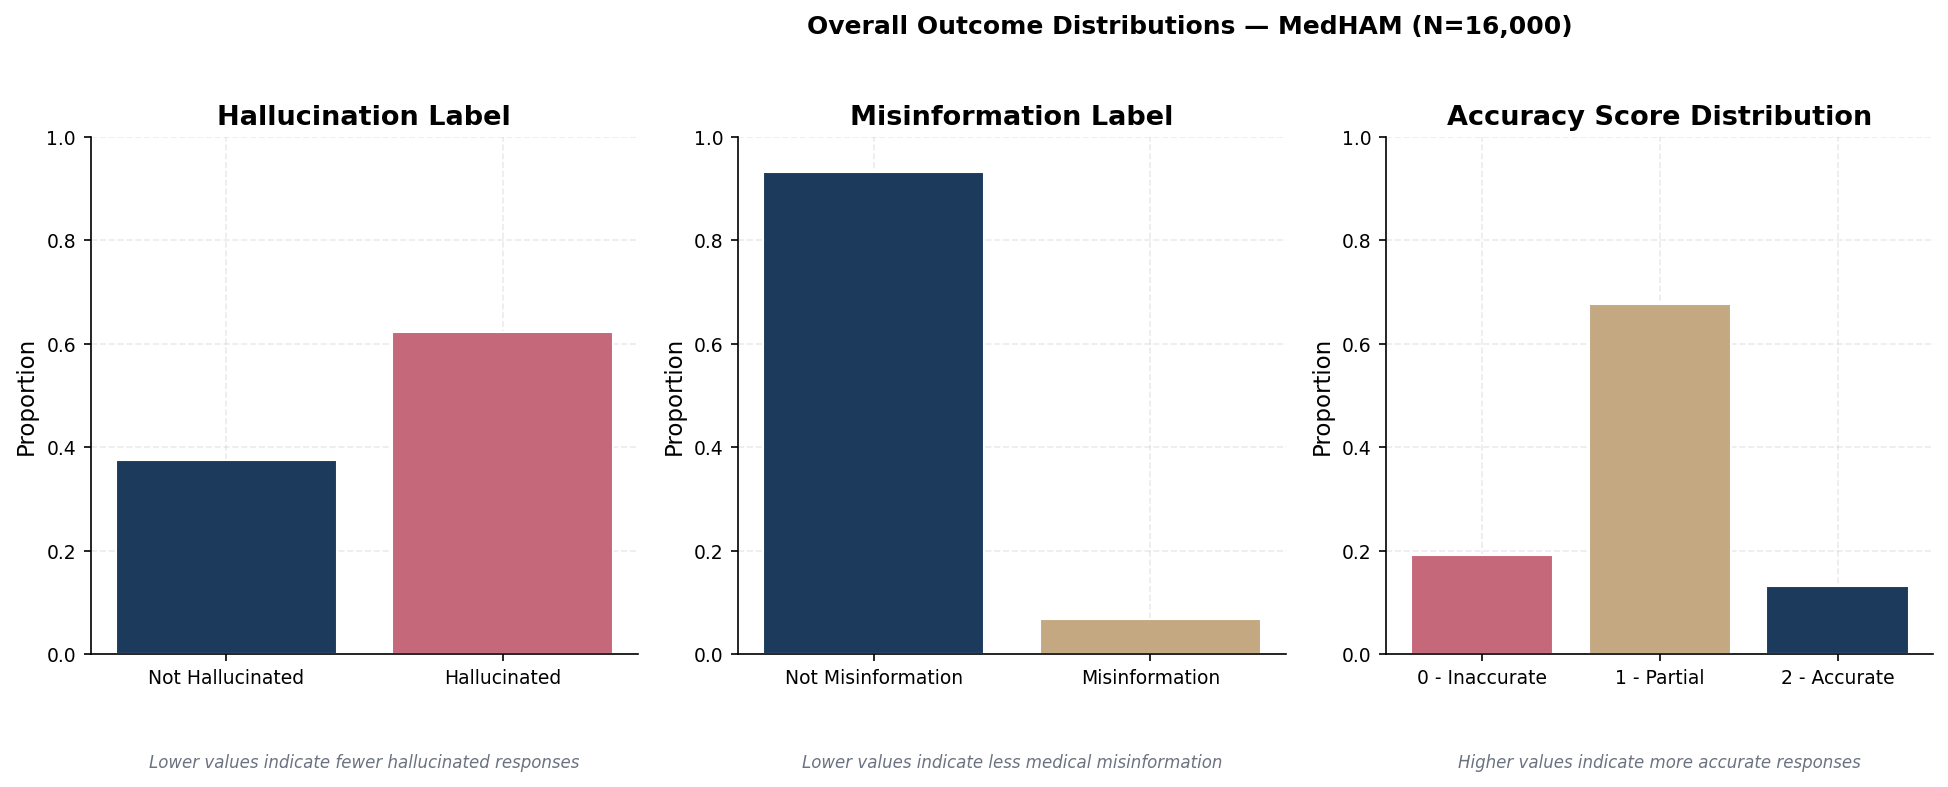

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

axes[0].bar(['Not Hallucinated', 'Hallucinated'],
            [1-h_rate, h_rate], color=[OUTCOME_COLORS['no_hallucination'], OUTCOME_COLORS['hallucination']], edgecolor='white')
axes[0].set_title('Hallucination Label', fontweight='bold')
axes[0].set_ylabel('Proportion')
axes[0].set_ylim(0, 1)
for i, v in enumerate([1-h_rate, h_rate]):
    # In-plot value labels removed for publication-quality readability.
    pass

axes[1].bar(['Not Misinformation', 'Misinformation'],
            [1-m_rate, m_rate], color=[OUTCOME_COLORS['no_misinformation'], OUTCOME_COLORS['misinformation']], edgecolor='white')
axes[1].set_title('Misinformation Label', fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_ylim(0, 1)
for i, v in enumerate([1-m_rate, m_rate]):
    # In-plot value labels removed for publication-quality readability.
    pass

bars = axes[2].bar(['0 - Inaccurate','1 - Partial','2 - Accurate'],
                   [acc0, acc1, acc2], color=[OUTCOME_COLORS['inaccurate'], OUTCOME_COLORS['partial'], OUTCOME_COLORS['accurate']], edgecolor='white')
axes[2].set_title('Accuracy Score Distribution', fontweight='bold')
axes[2].set_ylabel('Proportion')
axes[2].set_ylim(0, 1)
for bar, v in zip(bars, [acc0, acc1, acc2]):
    # In-plot value labels removed for publication-quality readability.
    pass

plt.suptitle('Overall Outcome Distributions — MedHAM (N=16,000)', fontsize=12, fontweight='bold', y=1.02)
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_01_overall_distributions.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---

## 4. RQ1 — Extent of Hallucination, Inaccuracy, and Misinformation

*Characterises model-level hallucination, misinformation, and accuracy patterns across all experimental conditions.*

**RQ1:** *To what extent do large language models produce hallucinated, inaccurate, and medically misinformative responses when answering evidence-based medical questions?*

This section characterises the baseline prevalence of each outcome measure across all four models and all
four experimental conditions (4,000 responses per model). Statistical comparisons across models use the
Kruskal-Wallis H-test on `accuracy_consensus` (continuous 0–2 scale), with pairwise Mann-Whitney U
tests corrected for multiplicity (Bonferroni, 6 pairs, α = 0.05/6 ≈ 0.0083).


In [8]:
model_stats = df.groupby('model_label').agg(
    hallucination_rate  = ('hallucination_label', 'mean'),
    misinformation_rate = ('misinformation_label', 'mean'),
    accuracy_mean       = ('accuracy_consensus',   'mean'),
    acc0_rate           = ('accuracy_score', lambda x: (x==0).mean()),
    acc1_rate           = ('accuracy_score', lambda x: (x==1).mean()),
    acc2_rate           = ('accuracy_score', lambda x: (x==2).mean()),
    n                   = ('response_id', 'count'),
).reindex(MODEL_ORDER)

print("=== RQ1: Per-Model Outcome Summary ===")
display_cols = ['hallucination_rate','misinformation_rate','accuracy_mean','n']
print(model_stats[display_cols].round(4).to_string())

groups = [df[df['model_label']==m]['accuracy_consensus'].values for m in MODEL_ORDER]
kw_stat, kw_p = kruskal(*groups)
print(f"\nKruskal-Wallis (accuracy_consensus): H={kw_stat:.3f}, p={kw_p:.4f}")

print("\nPairwise Mann-Whitney U (Bonferroni alpha=0.0083):")
for m1, m2 in combinations(MODEL_ORDER, 2):
    a = df[df['model_label']==m1]['accuracy_consensus'].values
    b = df[df['model_label']==m2]['accuracy_consensus'].values
    u, p = mannwhitneyu(a, b, alternative='two-sided')
    r = rank_biserial(u, len(a), len(b))
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"  {m1:<22} vs {m2:<22}  U={u:.0f}  p={p:.4f}  r={r:.3f} ({interpret_r(r)} effect)  {sig}")


=== RQ1: Per-Model Outcome Summary ===
                  hallucination_rate  misinformation_rate  accuracy_mean     n
model_label                                                                   
GPT-4o                        0.6708               0.0508         1.2132  4000
Claude Sonnet                 0.8255               0.0700         1.2129  4000
Gemini 2.5 Flash              0.1792               0.0302         1.0005  4000
Llama 3.1 8B                  0.8198               0.1175         1.0496  4000

Kruskal-Wallis (accuracy_consensus): H=411.398, p=0.0000

Pairwise Mann-Whitney U (Bonferroni alpha=0.0083):
  GPT-4o                 vs Claude Sonnet           U=7906835  p=0.3625  r=0.012 (negligible effect)  ns
  GPT-4o                 vs Gemini 2.5 Flash        U=9582976  p=0.0000  r=-0.198 (small effect)  ***
  GPT-4o                 vs Llama 3.1 8B            U=9267340  p=0.0000  r=-0.158 (small effect)  ***
  Claude Sonnet          vs Gemini 2.5 Flash        U=9616074  p=0.0

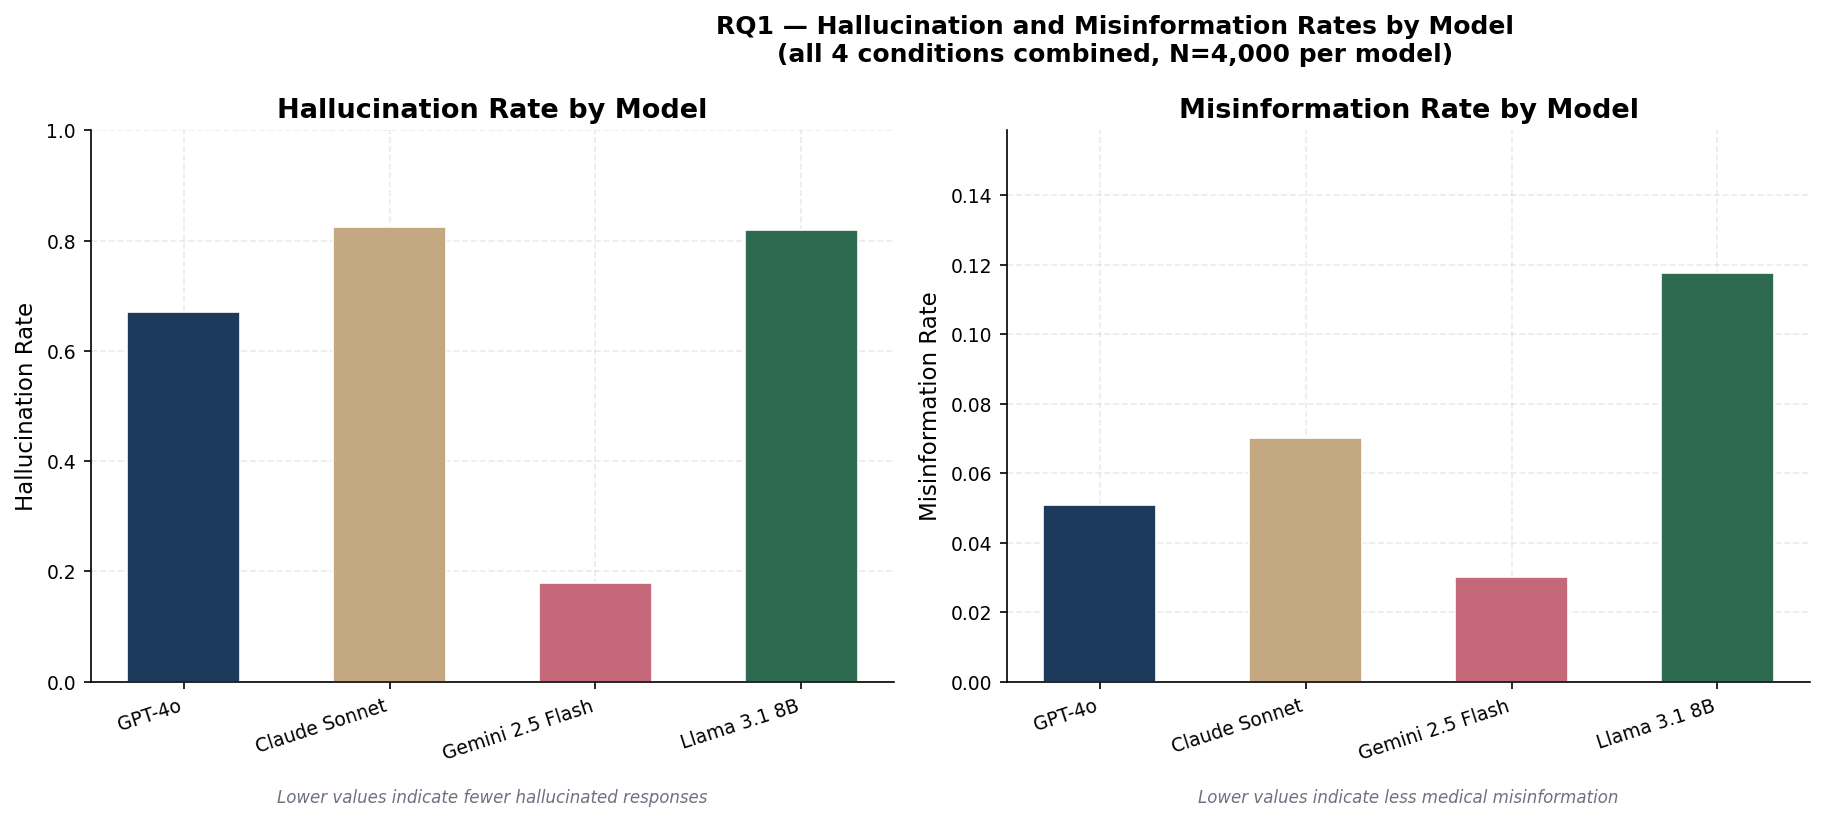

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(MODEL_ORDER))
w = 0.55
colors = [MODEL_COLORS[m] for m in MODEL_ORDER]

for ax, col, title, ylabel in [
    (axes[0], 'hallucination_rate',  'Hallucination Rate by Model',   'Hallucination Rate'),
    (axes[1], 'misinformation_rate', 'Misinformation Rate by Model',  'Misinformation Rate'),
]:
    vals = model_stats[col].values
    bars = ax.bar(x, vals, width=w, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=18, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, min(1, max(vals)*1.35))
    for bar, v in zip(bars, vals):
        # In-plot value labels removed for publication-quality readability.
        pass

plt.suptitle('RQ1 — Hallucination and Misinformation Rates by Model\n(all 4 conditions combined, N=4,000 per model)',
             fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_02_rates_by_model.png', bbox_inches='tight')
plt.show()
plt.close(fig)


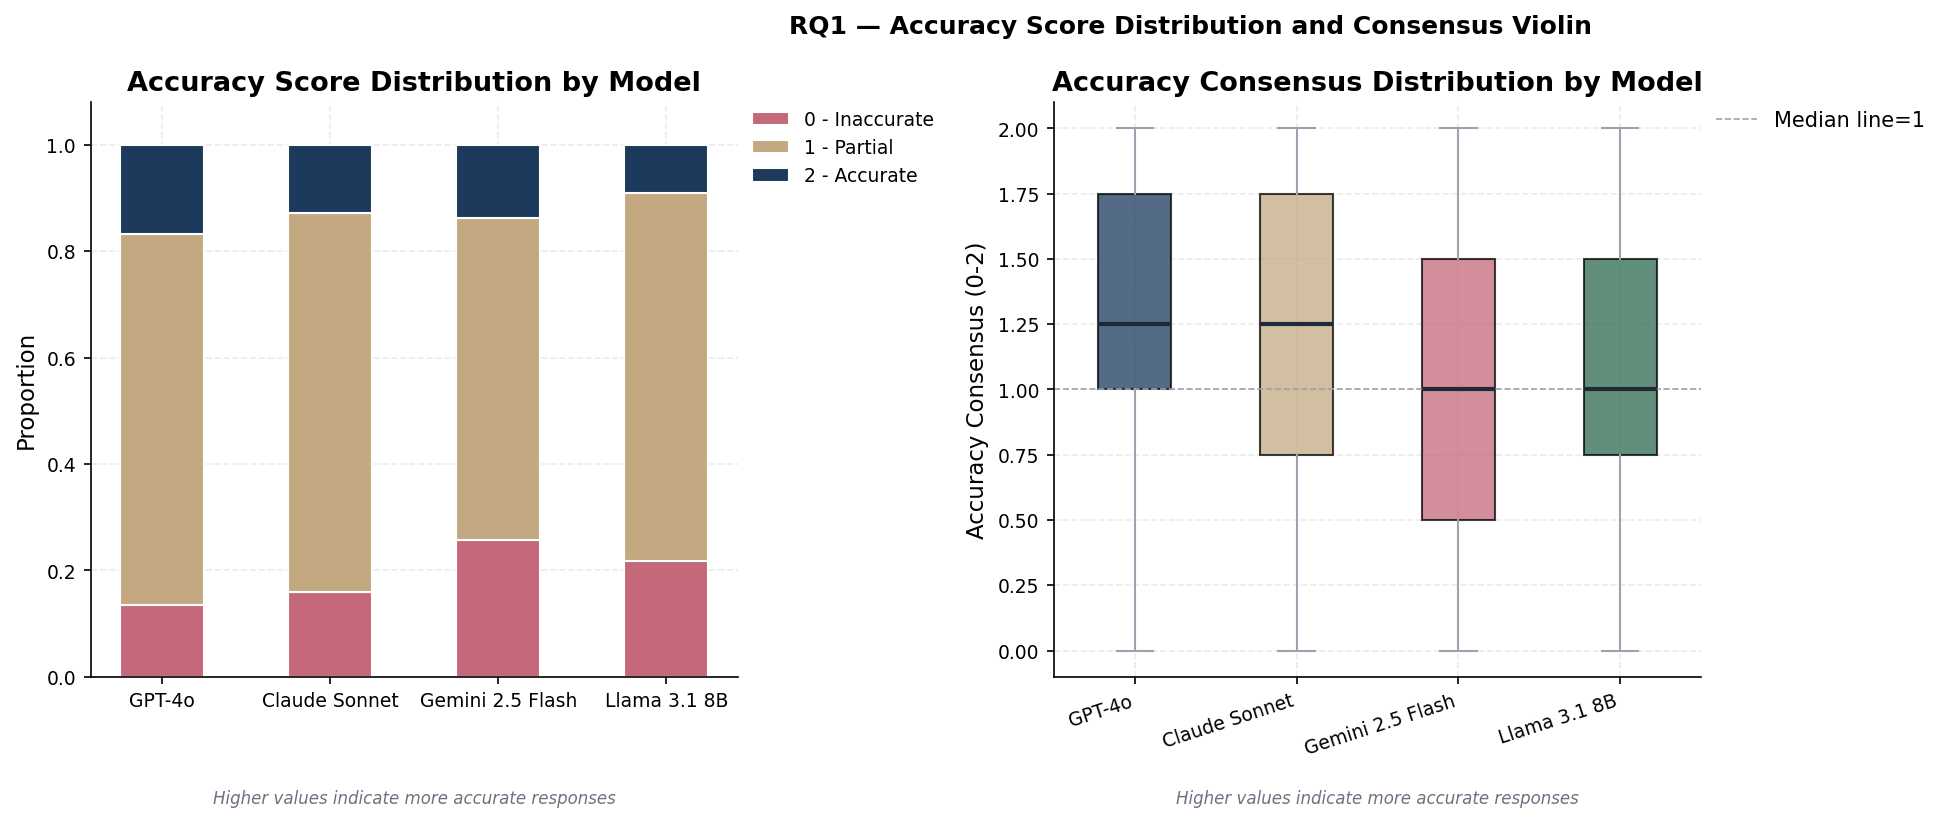

In [10]:
# Stacked accuracy score distribution + violin
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# stacked bar
x = np.arange(len(MODEL_ORDER))
w = 0.5
acc0_v = model_stats['acc0_rate'].values
acc1_v = model_stats['acc1_rate'].values
acc2_v = model_stats['acc2_rate'].values

axes[0].bar(x, acc0_v, width=w, label='0 - Inaccurate',         color=OUTCOME_COLORS['inaccurate'], edgecolor='white')
axes[0].bar(x, acc1_v, width=w, bottom=acc0_v,                   label='1 - Partial',          color=OUTCOME_COLORS['partial'],    edgecolor='white')
axes[0].bar(x, acc2_v, width=w, bottom=acc0_v+acc1_v,            label='2 - Accurate',          color=OUTCOME_COLORS['accurate'],   edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(MODEL_ORDER)
axes[0].set_ylabel('Proportion')
axes[0].set_title('Accuracy Score Distribution by Model', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.08)
for i, m in enumerate(MODEL_ORDER):
    # In-plot value labels removed for publication-quality readability.
    pass

# boxplot
box_data = [df[df['model_label']==m]['accuracy_consensus'].dropna().values for m in MODEL_ORDER]
bp = axes[1].boxplot(box_data, labels=MODEL_ORDER, patch_artist=True,
                     medianprops=dict(color='#1f2937', linewidth=2))
for patch, m in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.75)
for part in ['whiskers','caps','fliers']:
    for item in bp[part]:
        item.set_color('#9ca3af')
axes[1].set_xticklabels(MODEL_ORDER, rotation=18, ha='right')
axes[1].set_ylabel('Accuracy Consensus (0-2)')
axes[1].set_title('Accuracy Consensus Distribution by Model', fontweight='bold')
axes[1].set_ylim(-0.1, 2.1)
axes[1].axhline(1.0, color='#9ca3af', linestyle='--', linewidth=0.8, label='Median line=1')
axes[1].legend(fontsize=10)

plt.suptitle('RQ1 — Accuracy Score Distribution and Consensus Violin', fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_03_accuracy_by_model.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---

## 5. RQ2 Overview — RAG and Citation Prompting Effects

*Provides a model-by-condition overview of RAG and citation prompting effects before formal hypothesis sections.*

**RQ2:** *How do retrieval-augmented generation and citation prompting — separately and together — affect hallucination,
accuracy, and misinformation in large language model responses to medical questions, and do these effects differ
across models and question difficulty levels?*

RQ2 is addressed through four hypotheses (H2.1–H2.4), each examined in its own section below.
The full condition × model breakdown is shown here as an orientation.


In [11]:
cond_stats = df.groupby(['model_label','strategy_name']).agg(
    hallucination_rate  = ('hallucination_label', 'mean'),
    misinformation_rate = ('misinformation_label', 'mean'),
    accuracy_mean       = ('accuracy_consensus',   'mean'),
    n                   = ('response_id', 'count'),
).reset_index()

overall_cond = df.groupby('strategy_name').agg(
    hallucination_rate  = ('hallucination_label', 'mean'),
    misinformation_rate = ('misinformation_label', 'mean'),
    accuracy_mean       = ('accuracy_consensus',   'mean'),
    n                   = ('response_id', 'count'),
).reindex(COND_ORDER)

print("=== RQ2: Per-Condition Summary (all models) ===")
print(overall_cond.round(4).to_string())

groups_c = [df[df['strategy_name']==c]['accuracy_consensus'].values for c in COND_ORDER]
kw_c, kw_cp = kruskal(*groups_c)
print(f"\nKruskal-Wallis across conditions: H={kw_c:.3f}, p={kw_cp:.4f}")


=== RQ2: Per-Condition Summary (all models) ===
               hallucination_rate  misinformation_rate  accuracy_mean     n
strategy_name                                                              
ZS_NoRAG                   0.3808               0.0922         0.9424  4000
ZS_RAG                     0.6092               0.0230         1.3658  4000
CIT_NoRAG                  0.7328               0.1218         0.8315  4000
CIT_RAG                    0.7725               0.0315         1.3366  4000

Kruskal-Wallis across conditions: H=2364.222, p=0.0000


strategy_name unique values: ['ZS_NoRAG', 'ZS_RAG', 'CIT_NoRAG', 'CIT_RAG']


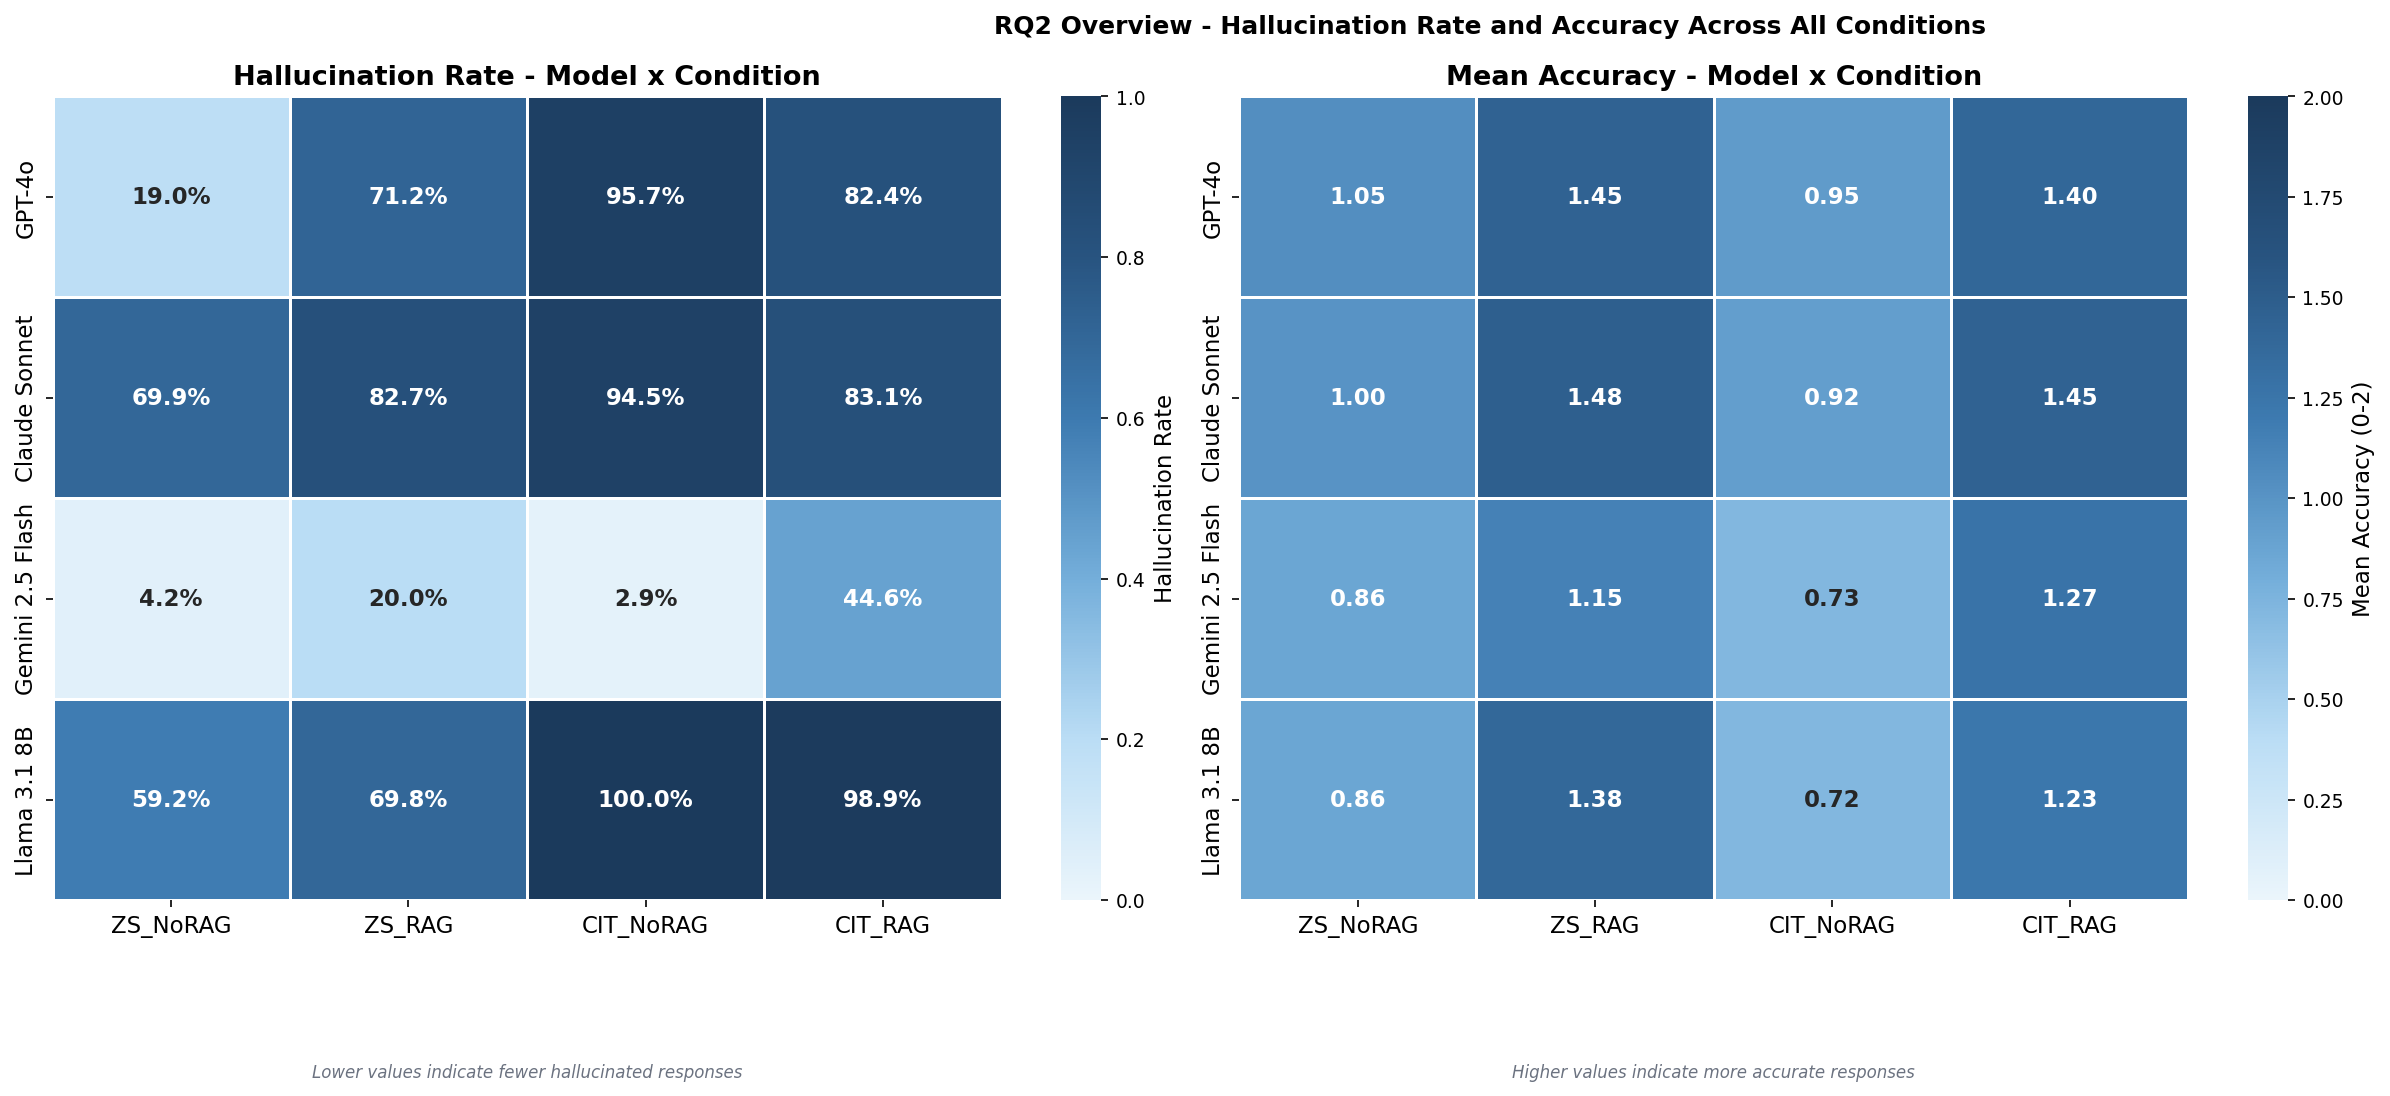

In [12]:
# orientation heatmap - all conditions x all models
print("strategy_name unique values:", df['strategy_name'].unique().tolist())

pivot_h = cond_stats.pivot(index='model_label', columns='strategy_name', values='hallucination_rate')
cond_cols = [c for c in COND_ORDER if c in pivot_h.columns] or pivot_h.columns.tolist()
model_rows = [m for m in MODEL_ORDER if m in pivot_h.index] or pivot_h.index.tolist()
pivot_h = pivot_h.reindex(index=model_rows, columns=cond_cols)

annot_h = pd.DataFrame('', index=model_rows, columns=cond_cols)
for model in model_rows:
    for cond in cond_cols:
        sub = df[(df['model_label'].eq(model)) & (df['strategy_name'].eq(cond))]
        est = sub['hallucination_label'].mean() * 100
        annot_h.loc[model, cond] = f"{est:.1f}%"

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(pivot_h, annot=annot_h, fmt='', annot_kws={'fontsize': 11, 'fontweight': 'bold'},
            cmap=ROSE_CMAP, vmin=0, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Hallucination Rate'}, ax=axes[0])
axes[0].set_title('Hallucination Rate - Model x Condition', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].set_ylabel('')

pivot_a = cond_stats.pivot(index='model_label', columns='strategy_name', values='accuracy_mean')
pivot_a = pivot_a.reindex(index=model_rows, columns=cond_cols)
sns.heatmap(pivot_a, annot=True, fmt='.2f', annot_kws={'fontsize': 11, 'fontweight': 'bold'},
            cmap=ROSE_CMAP, vmin=0, vmax=2,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Mean Accuracy (0-2)'}, ax=axes[1])
axes[1].set_title('Mean Accuracy - Model x Condition', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].set_ylabel('')

plt.suptitle('RQ2 Overview - Hallucination Rate and Accuracy Across All Conditions',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.82, 1])
standardize_figure(fig)
plt.savefig('charts/chart_04_rq2_overview_heatmap.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---

## 6. H2.1 — Effect of Retrieval-Augmented Generation

*Tests H2.1 by comparing RAG vs no-RAG conditions across all four models, with effect sizes and clustered bootstrap confidence intervals.*

**H2.1:** *Retrieval-augmented generation will reduce hallucination and misinformation rates and improve accuracy scores relative to the no-retrieval baseline.*

This section compares RAG conditions (ZS\_RAG + CIT\_RAG, N=8,000) against no-RAG conditions
(ZS\_NoRAG + CIT\_NoRAG, N=8,000).

**Statistical tests:**
- Mann-Whitney U on `accuracy_consensus` (RAG vs no-RAG)
- Chi-square on `hallucination_label × rag`
- Chi-square on `misinformation_label × rag`


In [13]:
print(f"df shape: {df.shape}  |  hallu_label dtype: {df['hallucination_label'].dtype}  |  rag dtype: {df['rag'].dtype}")
print(f"hallucination_label unique: {sorted(df['hallucination_label'].unique()[:5])}")
print(f"rag unique: {sorted(df['rag'].astype(str).unique())}")

no_rag   = df[df['rag'] == False].copy()
with_rag = df[df['rag'] == True].copy()
print(f"No-RAG rows: {len(no_rag):,}  |  RAG rows: {len(with_rag):,}")

u_acc, p_acc = mannwhitneyu(with_rag['accuracy_consensus'].dropna(), no_rag['accuracy_consensus'].dropna(), alternative='two-sided')

# use groupby instead of crosstab to avoid dropna edge cases
ct_h = df.groupby(['hallucination_label', 'rag']).size().unstack(fill_value=0)
ct_m = df.groupby(['misinformation_label','rag']).size().unstack(fill_value=0)
chi2_h, p_h, _, _ = chi2_contingency(ct_h)
chi2_m, p_m, _, _ = chi2_contingency(ct_m)

print("=== H2.1: RAG vs No-RAG (overall) ===")
print(f"  No-RAG   hallucination: {no_rag['hallucination_label'].mean():.3f}")
print(f"  RAG      hallucination: {with_rag['hallucination_label'].mean():.3f}")
print(f"  Delta:                  {with_rag['hallucination_label'].mean()-no_rag['hallucination_label'].mean():+.3f}")
print()
print(f"  No-RAG   misinformation:{no_rag['misinformation_label'].mean():.3f}")
print(f"  RAG      misinformation:{with_rag['misinformation_label'].mean():.3f}")
print(f"  Delta:                  {with_rag['misinformation_label'].mean()-no_rag['misinformation_label'].mean():+.3f}")
print()
print(f"  No-RAG   accuracy:      {no_rag['accuracy_consensus'].mean():.3f}")
print(f"  RAG      accuracy:      {with_rag['accuracy_consensus'].mean():.3f}")
print(f"  Delta:                  {with_rag['accuracy_consensus'].mean()-no_rag['accuracy_consensus'].mean():+.3f}")
print()
print(f"  Mann-Whitney U (accuracy):   U={u_acc:.0f}, p={p_acc:.4f}")
print(f"  Chi-square (hallucination):  chi2={chi2_h:.3f}, p={p_h:.4f}")
print(f"  Chi-square (misinformation): chi2={chi2_m:.3f}, p={p_m:.4f}")

h_supported = with_rag['hallucination_label'].mean() < no_rag['hallucination_label'].mean()
m_supported = with_rag['misinformation_label'].mean() < no_rag['misinformation_label'].mean() and p_m < 0.05
a_supported = with_rag['accuracy_consensus'].mean() > no_rag['accuracy_consensus'].mean() and p_acc < 0.05
n_h21 = sum([h_supported, m_supported, a_supported])
if n_h21 == 3:
    overall_h21 = 'Supported'
elif n_h21 == 0:
    overall_h21 = 'Not Supported'
else:
    overall_h21 = 'Partially Supported'
print(f"\n  H2.1 hallucination:  {'SUPPORTED' if h_supported else 'NOT SUPPORTED'} (RAG {'reduces' if h_supported else 'does not reduce'} hallucination, chi2 p={p_h:.4f})")
print(f"  H2.1 misinformation: {'SUPPORTED' if m_supported else 'NOT SUPPORTED'} (RAG {'reduces' if m_supported else 'does not reduce'} misinformation, chi2 p={p_m:.4f})")
print(f"  H2.1 accuracy:       {'SUPPORTED' if a_supported else 'NOT SUPPORTED'} (RAG {'improves' if a_supported else 'does not improve'} accuracy, MW p={p_acc:.4f})")
print(f"  H2.1 overall:        {overall_h21}  ({n_h21}/3 criteria met)")


r_acc_h21 = rank_biserial(u_acc, len(with_rag['accuracy_consensus'].dropna()), len(no_rag['accuracy_consensus'].dropna()))
v_h_h21 = cramers_v(chi2_h, len(df), min(ct_h.shape))
v_m_h21 = cramers_v(chi2_m, len(df), min(ct_m.shape))
print("\nEffect sizes (interpreted):")
print(f"  Accuracy Mann-Whitney: r={r_acc_h21:.3f} ({interpret_r(r_acc_h21)} effect)")
print(f"  Hallucination chi-square: V={v_h_h21:.3f} ({interpret_v(v_h_h21)} effect)")
print(f"  Misinformation chi-square: V={v_m_h21:.3f} ({interpret_v(v_m_h21)} effect)")

print("\nClustered bootstrap 95% CIs by item_id:")
for label, sub in [('No-RAG', no_rag), ('RAG', with_rag)]:
    ci_low, ci_high = clustered_bootstrap_ci(sub, 'hallucination_label')
    print(f"  {label:<6} hallucination: {sub['hallucination_label'].mean():.3f} [{ci_low:.3f}, {ci_high:.3f}]")
print("Confidence intervals are computed using clustered bootstrap resampling by item_id (n=1,000 clusters, 1,000 resamples) to account for the repeated-measures structure of the data, where each question appears across multiple model-condition combinations.")


df shape: (16000, 23)  |  hallu_label dtype: int64  |  rag dtype: bool
hallucination_label unique: [np.int64(0), np.int64(1)]
rag unique: ['False', 'True']
No-RAG rows: 8,000  |  RAG rows: 8,000
=== H2.1: RAG vs No-RAG (overall) ===
  No-RAG   hallucination: 0.557
  RAG      hallucination: 0.691
  Delta:                  +0.134

  No-RAG   misinformation:0.107
  RAG      misinformation:0.027
  Delta:                  -0.080

  No-RAG   accuracy:      0.887
  RAG      accuracy:      1.351
  Delta:                  +0.464

  Mann-Whitney U (accuracy):   U=45827188, p=0.0000
  Chi-square (hallucination):  chi2=306.063, p=0.0000
  Chi-square (misinformation): chi2=404.996, p=0.0000

  H2.1 hallucination:  NOT SUPPORTED (RAG does not reduce hallucination, chi2 p=0.0000)
  H2.1 misinformation: SUPPORTED (RAG reduces misinformation, chi2 p=0.0000)
  H2.1 accuracy:       SUPPORTED (RAG improves accuracy, MW p=0.0000)
  H2.1 overall:        Partially Supported  (2/3 criteria met)

Effect sizes 

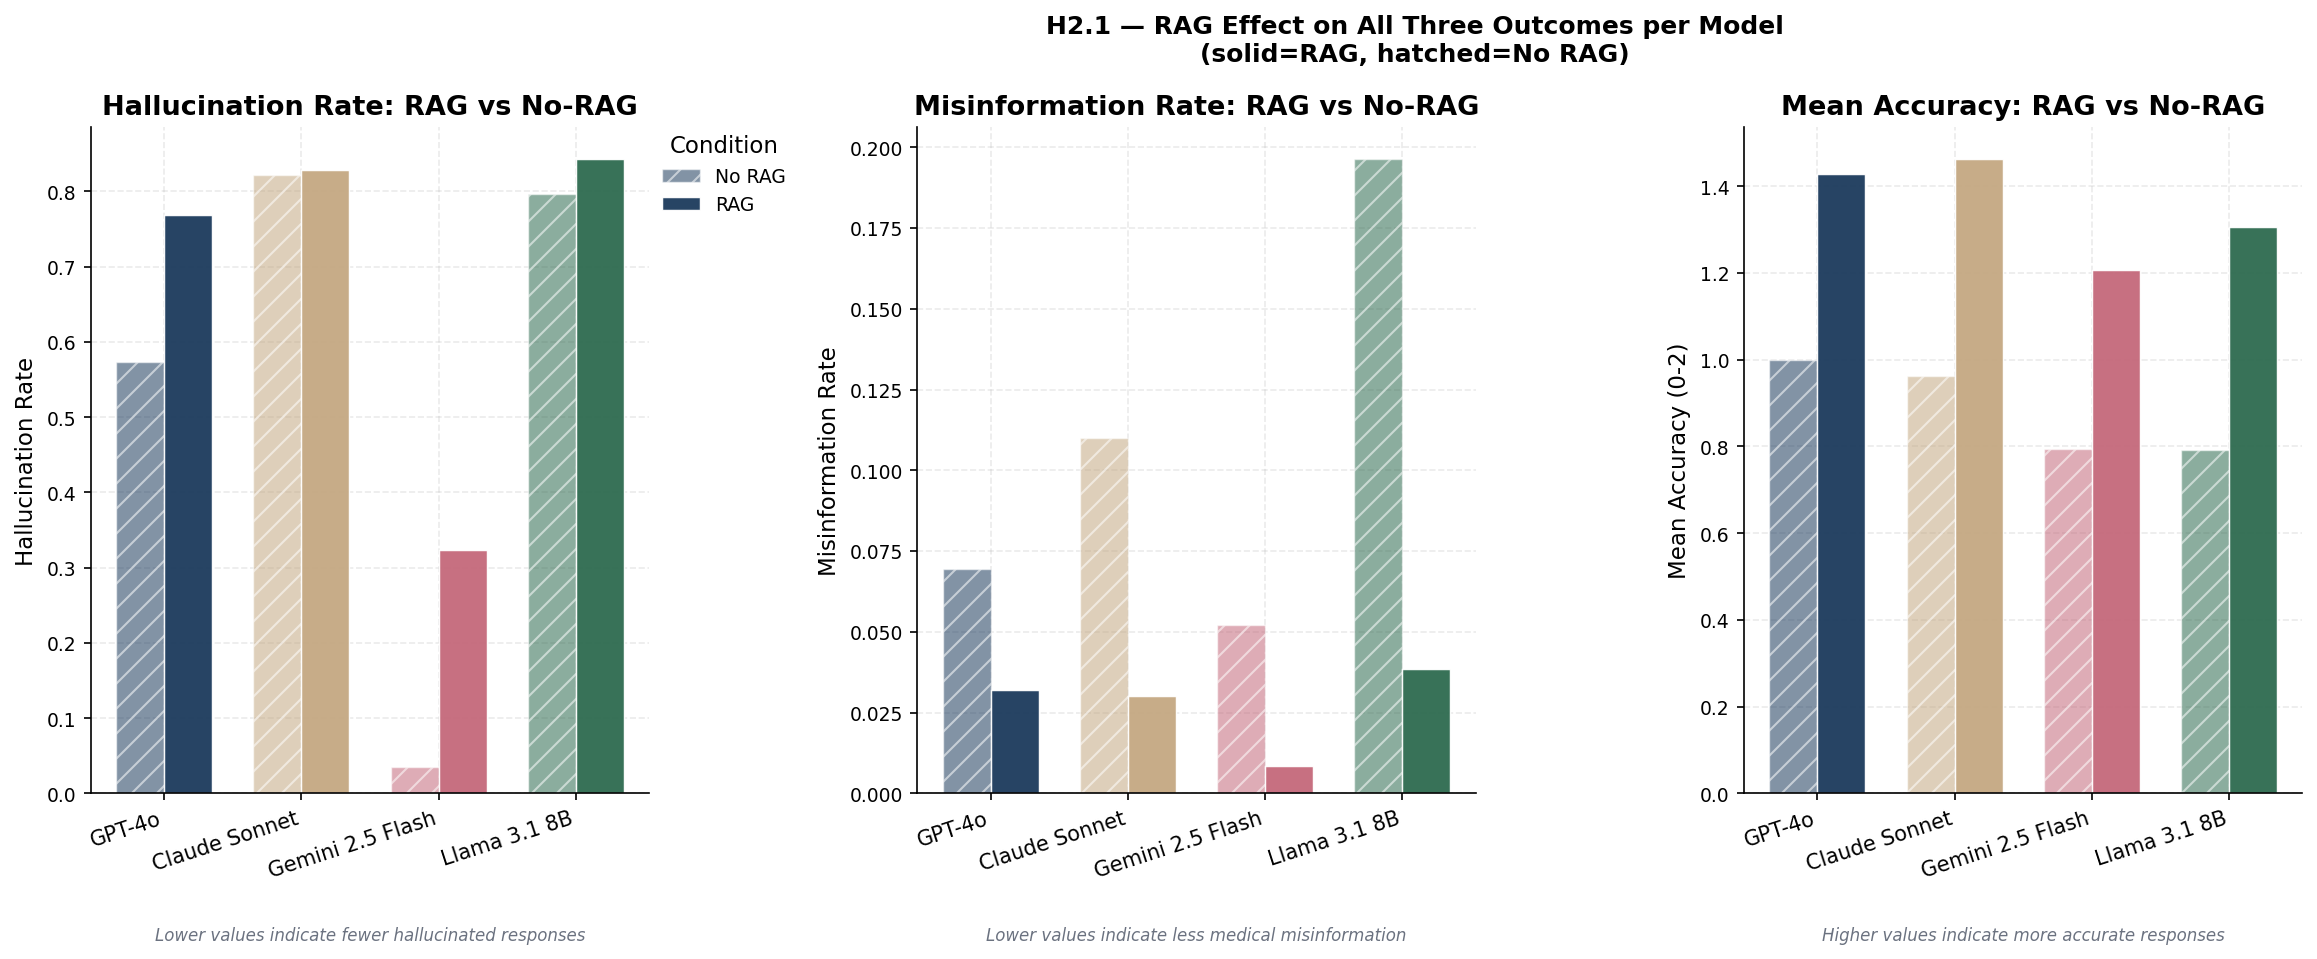

In [14]:
rag_stats = df.groupby(['model_label','rag']).agg(
    hallucination_rate  = ('hallucination_label', 'mean'),
    misinformation_rate = ('misinformation_label', 'mean'),
    accuracy_mean       = ('accuracy_consensus',   'mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
x = np.arange(len(MODEL_ORDER))
w = 0.35

for ax, col, ylabel, title in [
    (axes[0], 'hallucination_rate',  'Hallucination Rate',    'Hallucination Rate: RAG vs No-RAG'),
    (axes[1], 'misinformation_rate', 'Misinformation Rate',   'Misinformation Rate: RAG vs No-RAG'),
    (axes[2], 'accuracy_mean',       'Mean Accuracy (0-2)',   'Mean Accuracy: RAG vs No-RAG'),
]:
    for rag_val, label, offset, alpha, hatch in [
        (False, 'No RAG', -w/2, 0.55, '//'),
        (True,  'RAG',     w/2, 0.95, ''),
    ]:
        vals = []
        for m in MODEL_ORDER:
            sub = rag_stats[(rag_stats['model_label']==m) & (rag_stats['rag']==rag_val)]
            vals.append(sub[col].values[0] if len(sub) else 0)
        ax.bar(x+offset, vals, width=w,
               color=[MODEL_COLORS[m] for m in MODEL_ORDER],
               alpha=alpha, edgecolor='white', linewidth=0.7,
               label=label, hatch=hatch)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=18, ha='right', fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')

axes[0].legend(title='Condition')
plt.suptitle('H2.1 — RAG Effect on All Three Outcomes per Model\n(solid=RAG, hatched=No RAG)',
             fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.45, hspace=0.55, bottom=0.18)
standardize_figure(fig)
plt.savefig('charts/chart_05_h21_rag_effect.png', bbox_inches='tight')
plt.show()
plt.close(fig)


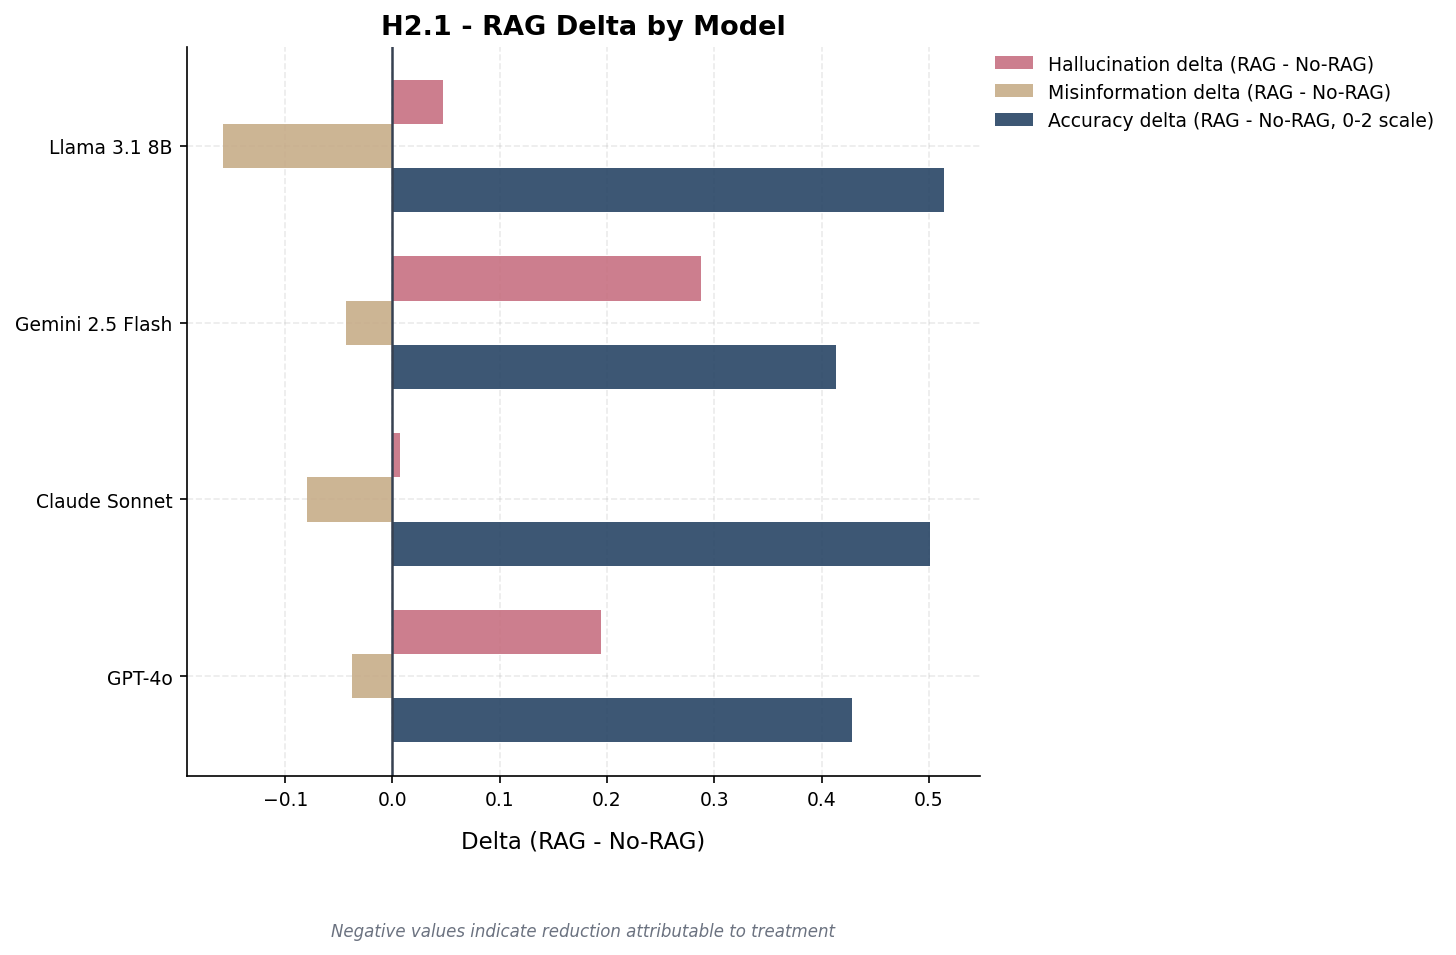

In [15]:
# RAG delta chart -- change in hallucination rate per model
deltas_h = []
deltas_m = []
deltas_a = []
for m in MODEL_ORDER:
    no_r = rag_stats[(rag_stats['model_label']==m) & (~rag_stats['rag'])]
    wi_r = rag_stats[(rag_stats['model_label']==m) & (rag_stats['rag'])]
    deltas_h.append(wi_r['hallucination_rate'].values[0]  - no_r['hallucination_rate'].values[0])
    deltas_m.append(wi_r['misinformation_rate'].values[0] - no_r['misinformation_rate'].values[0])
    deltas_a.append(wi_r['accuracy_mean'].values[0]       - no_r['accuracy_mean'].values[0])

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(MODEL_ORDER))
w = 0.25

ax.barh(y+w, deltas_h, height=w, label='Hallucination delta (RAG - No-RAG)',
        color=OUTCOME_COLORS['hallucination'], alpha=0.85)
ax.barh(y,   deltas_m, height=w, label='Misinformation delta (RAG - No-RAG)',
        color=OUTCOME_COLORS['misinformation'], alpha=0.85)
ax.barh(y-w, deltas_a, height=w, label='Accuracy delta (RAG - No-RAG, 0-2 scale)',
        color=OUTCOME_COLORS['accurate'], alpha=0.85)

ax.axvline(0, color='#374151', linewidth=1.2)
ax.set_yticks(y)
ax.set_yticklabels(MODEL_ORDER)
ax.set_xlabel('Delta (RAG - No-RAG)', labelpad=10)
ax.set_title('H2.1 - RAG Delta by Model', fontweight='bold')
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_06_h21_rag_delta.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---
## RAG Context Quality Analysis

*Explores whether retrieved-context length and qualitative examples help explain RAG successes and failures.*


In [16]:
context_col = 'context' if 'context' in rag_ctx.columns else 'knowledge_context'
rag_ctx['context_length'] = rag_ctx[context_col].fillna('').str.len()
df_rag_quality = df[df['rag']].merge(rag_ctx[['item_id','context_length', context_col]].rename(columns={context_col: 'context'}), on='item_id', how='left')
quality_corr = df_rag_quality[['context_length','hallucination_label','accuracy_consensus']].corr()
print("=== RAG Context-Length Proxy Correlations ===")
print(quality_corr.round(3).to_string())

examples = []
example_specs = [
    ('Good retrieval -> correct answer', (df_rag_quality['hallucination_label'].eq(0)) & (df_rag_quality['accuracy_consensus'].eq(2))),
    ('Poor/irrelevant retrieval -> hallucination', (df_rag_quality['hallucination_label'].eq(1)) & (df_rag_quality['accuracy_consensus'].eq(0))),
    ('Borderline retrieval -> partial accuracy', (df_rag_quality['accuracy_consensus'].eq(1))),
]
for label, mask in example_specs:
    ex = df_rag_quality[mask].merge(items[['item_id','question','ground_truth']], on='item_id', how='left')
    ex = ex.merge(responses[['response_id','response_text']], on='response_id', how='left')
    if len(ex):
        row = ex.iloc[0]
        examples.append({
            'Example Type': label,
            'Model': row['model_label'],
            'Condition': row['strategy_name'],
            'Question': str(row.get('question',''))[:350],
            'Retrieved Context': str(row.get('context',''))[:600],
            'Response': str(row.get('response_text',''))[:600],
            'Hallucination': int(row['hallucination_label']),
            'Accuracy': row['accuracy_consensus'],
        })
rag_quality_examples = pd.DataFrame(examples)
display(rag_quality_examples)


=== RAG Context-Length Proxy Correlations ===
                     context_length  hallucination_label  accuracy_consensus
context_length                1.000                0.026              -0.021
hallucination_label           0.026                1.000              -0.131
accuracy_consensus           -0.021               -0.131               1.000


,Example Type,Model,Condition,Question,Retrieved Context,Response,Hallucination,Accuracy
0,Good retrieval -> correct answer,Claude Sonnet,ZS_RAG,Do mitochondria play a role in remodelling lac...,Programmed cell death (PCD) is the regulated d...,# Mitochondria in Lace Plant Leaf Remodelling ...,0,2.0
1,Poor/irrelevant retrieval -> hallucination,GPT-4o,ZS_RAG,Is adjustment for reporting heterogeneity nece...,Anchoring vignettes are brief texts describing...,"Yes, adjustment for reporting heterogeneity is...",1,0.0
2,Borderline retrieval -> partial accuracy,Claude Sonnet,CIT_RAG,Landolt C and snellen e acuity: differences in...,Assessment of visual acuity depends on the opt...,## Landolt C vs. Snellen E Acuity in Strabismu...,1,1.0


---

## 7. H2.2 - Descriptive Model-Size Comparison

*Treats model-size moderation descriptively because only one open-source small model is included in the study.*

**H2.2:** *The effect of retrieval augmentation and citation prompting on hallucination and misinformation rates and accuracy scores will be stronger for smaller models than for larger models.*

H2.2 predicted that smaller models would benefit more from RAG and citation prompting. With only one open-source model (Llama 3.1 8B) in the study, this hypothesis is treated as a descriptive comparison between the observed models rather than a statistical test of model size as a category. The RAG delta for Llama 3.1 8B is reported alongside those of the three commercial models as an exploratory observation. Replication with multiple models per size tier is required before any size-based conclusion can be drawn.


In [17]:
# per-response RAG delta
# for each item x model, compare RAG vs no-RAG accuracy_consensus
rag_sub = df[df['rag']][['item_id','model_id','model_label','model_type_label','strategy_name','accuracy_consensus']].copy()
norag_sub = df[~df['rag']][['item_id','model_id','model_label','model_type_label','strategy_name','accuracy_consensus']].copy()
rag_sub['pair_strat'] = rag_sub['strategy_name'].map({'ZS_RAG':'ZS','CIT_RAG':'CIT'})
norag_sub['pair_strat'] = norag_sub['strategy_name'].map({'ZS_NoRAG':'ZS','CIT_NoRAG':'CIT'})
merged_rag = rag_sub.merge(
    norag_sub[['item_id','model_id','pair_strat','accuracy_consensus']].rename(columns={'accuracy_consensus':'acc_norag'}),
    on=['item_id','model_id','pair_strat']
)
merged_rag['rag_delta'] = merged_rag['accuracy_consensus'] - merged_rag['acc_norag']

print("=== H2.2: Descriptive RAG Delta by Model Type ===")
print(merged_rag.groupby('model_type_label')['rag_delta'].describe().round(4).to_string())
commercial_delta = merged_rag[merged_rag['model_type_label']=='Commercial Large']['rag_delta']
opensource_delta = merged_rag[merged_rag['model_type_label']=='Open Source Small']['rag_delta']
print(f"\nCommercial mean delta:  {commercial_delta.mean():+.4f}")
print(f"Open-source mean delta: {opensource_delta.mean():+.4f}")
print("No Mann-Whitney size-category test is reported because the open-source/small tier contains one model only; this is an exploratory descriptive comparison.")
h22_supported = False


=== H2.2: Descriptive RAG Delta by Model Type ===
                    count    mean     std  min  25%    50%  75%  max
model_type_label                                                    
Commercial Large   6000.0  0.4477  0.7476 -2.0  0.0  0.250  1.0  2.0
Open Source Small  2000.0  0.5140  0.7291 -2.0  0.0  0.375  1.0  2.0

Commercial mean delta:  +0.4477
Open-source mean delta: +0.5140
No Mann-Whitney size-category test is reported because the open-source/small tier contains one model only; this is an exploratory descriptive comparison.


In [18]:
u_h22, p_h22 = mannwhitneyu(opensource_delta, commercial_delta, alternative='two-sided')
r_h22 = rank_biserial(u_h22, len(opensource_delta), len(commercial_delta))
print(f"Mann-Whitney on delta distributions: U={u_h22:.0f}, p={p_h22:.4f}, r={r_h22:.3f} ({interpret_r(r_h22)} effect)")
print("Note: this tests whether the RAG delta distributions differ between the single open-source model and commercial models. It cannot establish model size as a generalised category effect.")

Mann-Whitney on delta distributions: U=6358664, p=0.0001, r=-0.060 (negligible effect)
Note: this tests whether the RAG delta distributions differ between the single open-source model and commercial models. It cannot establish model size as a generalised category effect.


In [19]:
# per-model RAG and citation deltas
rag_delta_by_model = merged_rag.groupby('model_label')['rag_delta'].mean()

# citation delta — same approach
cit_sub   = df[df['citation']][['item_id','model_id','model_label','model_type_label','strategy_name','accuracy_consensus']].copy()
nocit_sub = df[~df['citation']][['item_id','model_id','model_label','model_type_label','strategy_name','accuracy_consensus']].copy()
cit_sub['pair_strat']   = cit_sub['strategy_name'].map({'CIT_NoRAG':'NoRAG','CIT_RAG':'RAG'})
nocit_sub['pair_strat'] = nocit_sub['strategy_name'].map({'ZS_NoRAG':'NoRAG','ZS_RAG':'RAG'})

merged_cit = cit_sub.merge(
    nocit_sub[['item_id','model_id','pair_strat','accuracy_consensus']].rename(columns={'accuracy_consensus':'acc_nocit'}),
    on=['item_id','model_id','pair_strat']
)
merged_cit['cit_delta'] = merged_cit['accuracy_consensus'] - merged_cit['acc_nocit']
cit_delta_by_model = merged_cit.groupby('model_label')['cit_delta'].mean()

print("=== H2.2: RAG and Citation Deltas per Model ===")
summary_h22 = pd.DataFrame({'RAG delta': rag_delta_by_model, 'Citation delta': cit_delta_by_model}).reindex(MODEL_ORDER)
print(summary_h22.round(4).to_string())


=== H2.2: RAG and Citation Deltas per Model ===
                  RAG delta  Citation delta
model_label                                
GPT-4o               0.4281         -0.0699
Claude Sonnet        0.5014         -0.0556
Gemini 2.5 Flash     0.4135         -0.0088
Llama 3.1 8B         0.5140         -0.1460


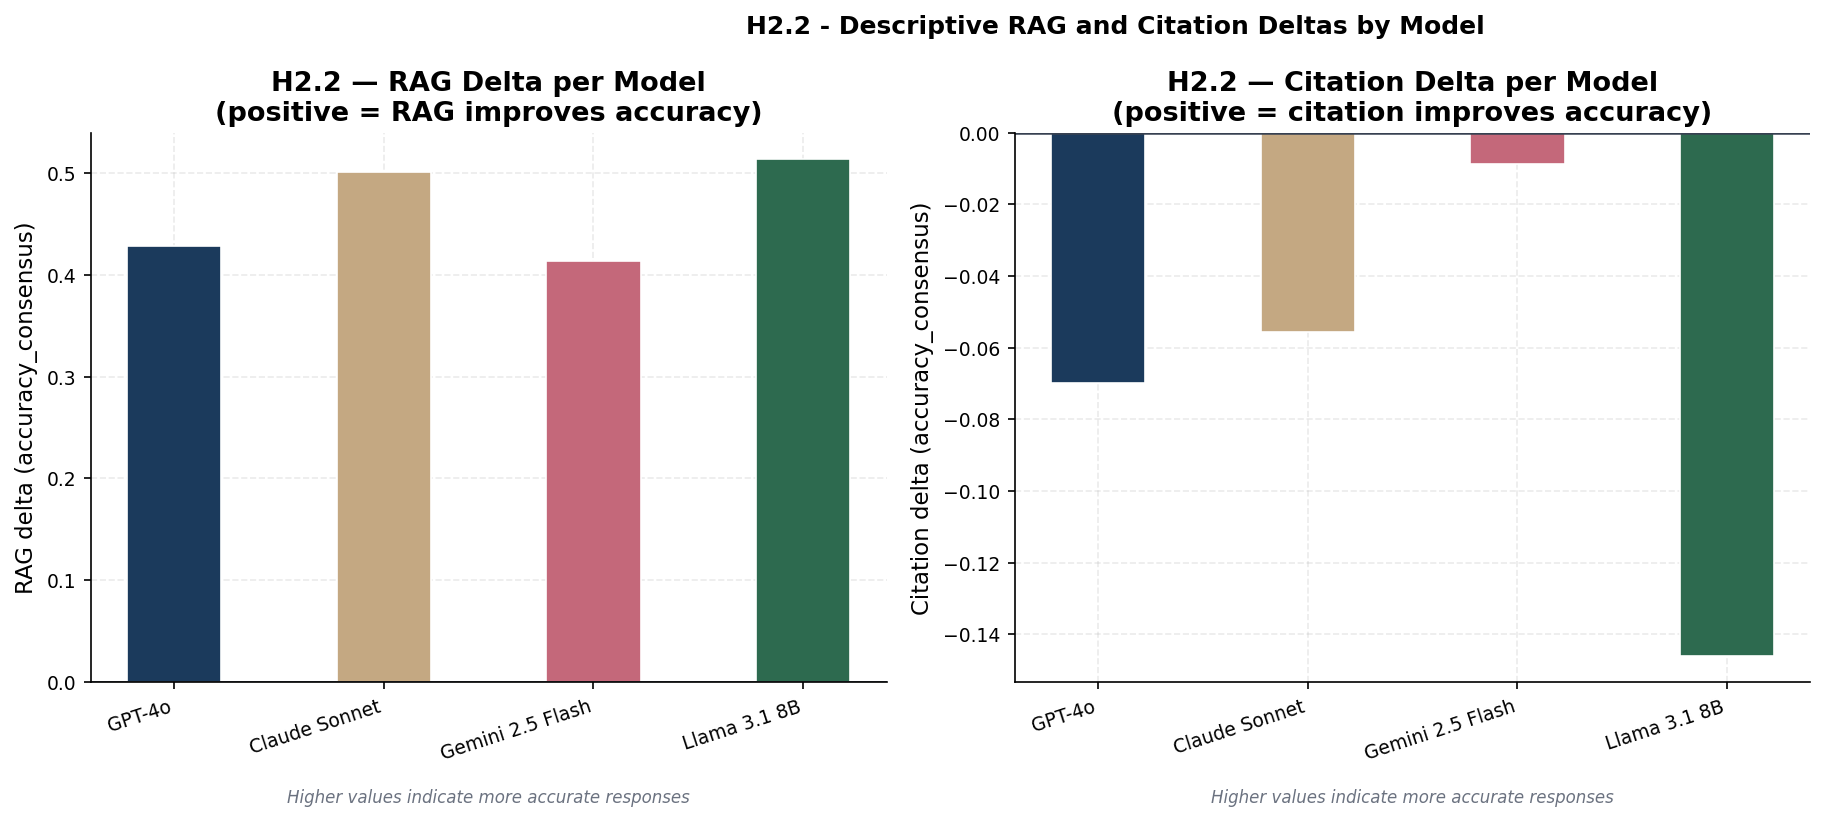

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(MODEL_ORDER))
w = 0.45

for ax, deltas, title, xlabel in [
    (axes[0], rag_delta_by_model.reindex(MODEL_ORDER).values,
     'H2.2 — RAG Delta per Model\n(positive = RAG improves accuracy)', 'RAG delta (accuracy_consensus)'),
    (axes[1], cit_delta_by_model.reindex(MODEL_ORDER).values,
     'H2.2 — Citation Delta per Model\n(positive = citation improves accuracy)', 'Citation delta (accuracy_consensus)'),
]:
    bars = ax.bar(x, deltas, width=w, color=[MODEL_COLORS[m] for m in MODEL_ORDER],
                   edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='#374151', linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=18, ha='right')
    ax.set_ylabel(xlabel)
    ax.set_title(title, fontweight='bold')
    for bar, d in zip(bars, deltas):
        # In-plot value labels removed for publication-quality readability.
        pass



plt.suptitle('H2.2 - Descriptive RAG and Citation Deltas by Model', fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_07_h22_model_size_moderation.png', bbox_inches='tight')
plt.show()
plt.close(fig)


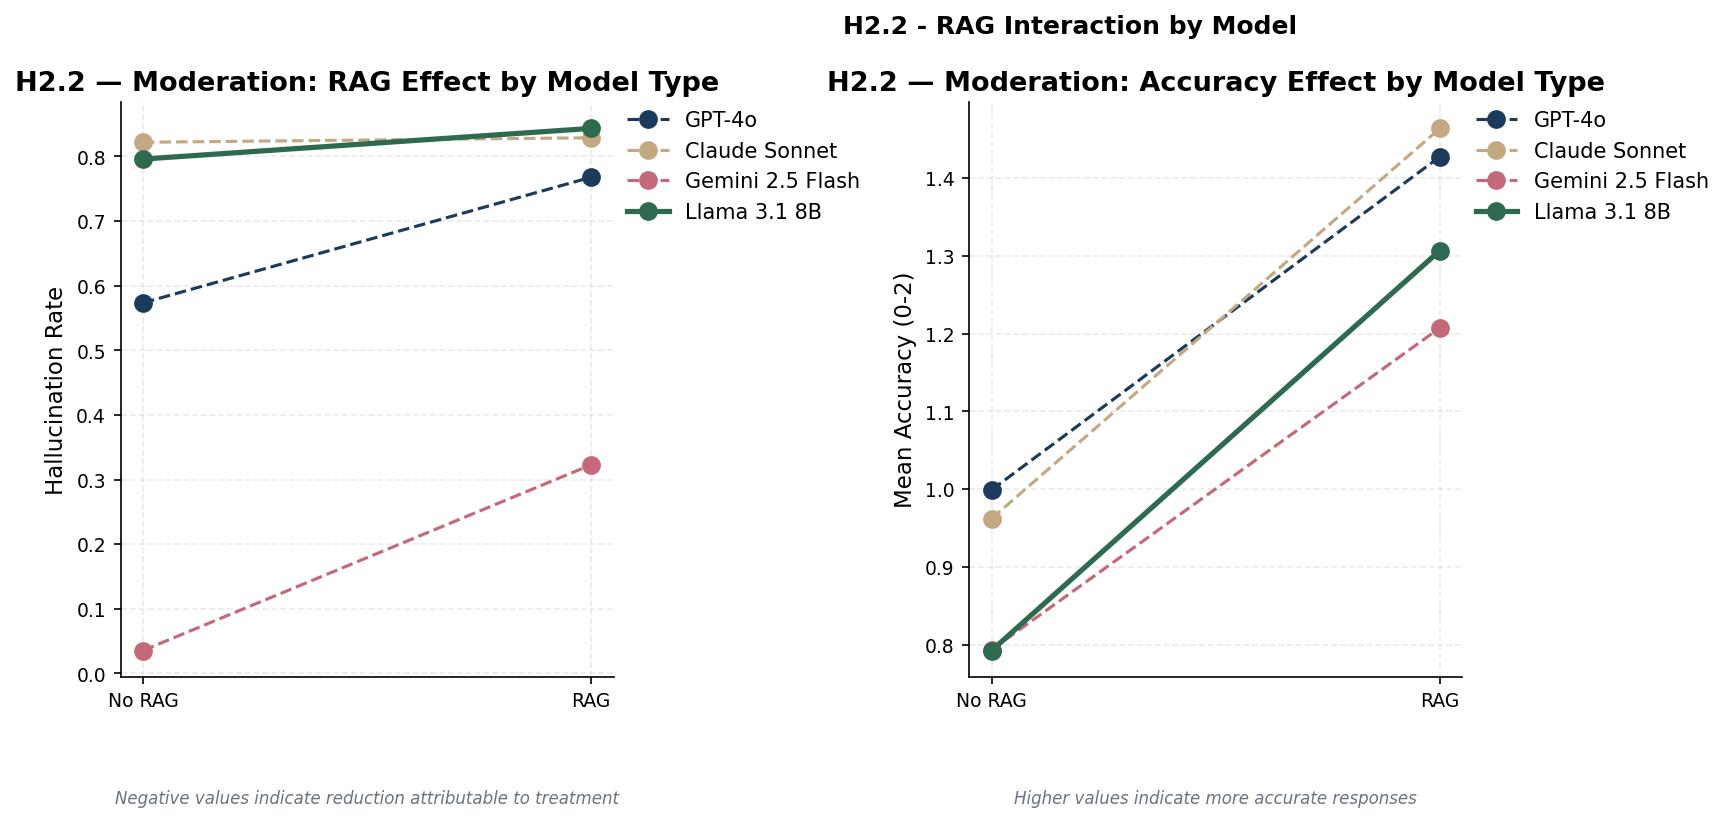

In [21]:
# interaction plot — RAG effect by model type (visual moderation test)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel, title in [
    (axes[0], 'hallucination_rate',  'Hallucination Rate',    'H2.2 — Moderation: RAG Effect by Model Type'),
    (axes[1], 'accuracy_mean',       'Mean Accuracy (0-2)',   'H2.2 — Moderation: Accuracy Effect by Model Type'),
]:
    for model in MODEL_ORDER:
        sub = rag_stats[rag_stats['model_label']==model].copy()
        sub = sub.set_index('rag').reindex([False, True])
        ax.plot([0, 1], sub[metric].values,
                'o-', color=MODEL_COLORS[model],
                linewidth=2.5 if model=='Llama 3.1 8B' else 1.5,
                markersize=8, label=model,
                linestyle='-' if model=='Llama 3.1 8B' else '--')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No RAG', 'RAG'])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=10)

plt.suptitle('H2.2 - RAG Interaction by Model', fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_08_h22_interaction_rag.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---

## 8. H2.3 — Effect of Citation Prompting

*Tests whether citation prompting is associated with hallucination, misinformation, and accuracy changes overall and by model.*

**H2.3:** *Citation prompting will reduce hallucination and misinformation rates and improve accuracy scores relative to zero-shot prompting.*

This section compares citation-required conditions (CIT\_NoRAG + CIT\_RAG) against zero-shot conditions
(ZS\_NoRAG + ZS\_RAG). The hypothesis predicts that requiring models to cite evidence forces more careful,
grounded responses, reducing hallucination.

The no-RAG subset (ZS\_NoRAG vs CIT\_NoRAG) isolates the pure citation effect without any retrieved context.
The RAG subset (ZS\_RAG vs CIT\_RAG) shows whether citation requirements add further benefit when context is provided.


In [22]:
no_cit = df[~df['citation']]
with_cit = df[df['citation']]

u_acc, p_acc = mannwhitneyu(with_cit['accuracy_consensus'], no_cit['accuracy_consensus'], alternative='two-sided')
chi2_h, p_h, _, _ = chi2_contingency(pd.crosstab(df['hallucination_label'], df['citation']))
chi2_m, p_m, _, _ = chi2_contingency(pd.crosstab(df['misinformation_label'], df['citation']))

print("=== H2.3: Citation vs Zero-Shot (overall) ===")
print(f"  Zero-Shot  hallucination: {no_cit['hallucination_label'].mean():.3f}")
print(f"  Citation   hallucination: {with_cit['hallucination_label'].mean():.3f}")
print(f"  Delta:                    {with_cit['hallucination_label'].mean()-no_cit['hallucination_label'].mean():+.3f}")
print()
print(f"  Zero-Shot  misinformation:{no_cit['misinformation_label'].mean():.3f}")
print(f"  Citation   misinformation:{with_cit['misinformation_label'].mean():.3f}")
print(f"  Delta:                    {with_cit['misinformation_label'].mean()-no_cit['misinformation_label'].mean():+.3f}")
print()
print(f"  Zero-Shot  accuracy:      {no_cit['accuracy_consensus'].mean():.3f}")
print(f"  Citation   accuracy:      {with_cit['accuracy_consensus'].mean():.3f}")
print(f"  Delta:                    {with_cit['accuracy_consensus'].mean()-no_cit['accuracy_consensus'].mean():+.3f}")
print()
print(f"  Mann-Whitney U (accuracy):   U={u_acc:.0f}, p={p_acc:.4f}")
print(f"  Chi-square (hallucination):  chi2={chi2_h:.3f}, p={p_h:.4f}")
print(f"  Chi-square (misinformation): chi2={chi2_m:.3f}, p={p_m:.4f}")

h_supported = with_cit['hallucination_label'].mean() < no_cit['hallucination_label'].mean()
m_supported = with_cit['misinformation_label'].mean() < no_cit['misinformation_label'].mean()
a_supported = with_cit['accuracy_consensus'].mean() > no_cit['accuracy_consensus'].mean()
print(f"\n  H2.3 hallucination:  {'SUPPORTED' if h_supported else 'NOT SUPPORTED'} (citation {'reduces' if h_supported else 'does not reduce'} hallucination, chi2 p={p_h:.4f})")
print(f"  H2.3 misinformation: {'SUPPORTED' if m_supported else 'NOT SUPPORTED'} (citation {'reduces' if m_supported else 'does not reduce'} misinformation, chi2 p={p_m:.4f})")
print(f"  H2.3 accuracy:       {'SUPPORTED' if a_supported else 'NOT SUPPORTED'} (citation {'improves' if a_supported else 'does not improve'} accuracy, MW p={p_acc:.4f})")
n_h23 = sum([h_supported, m_supported, a_supported])
if n_h23 == 3:
    overall_h23 = 'Supported'
elif n_h23 == 0:
    overall_h23 = 'Not Supported'
else:
    overall_h23 = 'Partially Supported'
print(f"  H2.3 overall:        {overall_h23}  ({n_h23}/3 criteria met)")

# within no-RAG and within RAG
for rag_label, rag_mask in [('No-RAG only', ~df['rag']), ('RAG only', df['rag'])]:
    sub = df[rag_mask]
    delta_h = sub[sub['citation']]['hallucination_label'].mean() - sub[~sub['citation']]['hallucination_label'].mean()
    print(f"  [{rag_label}] citation delta on hallucination: {delta_h:+.3f}")


r_acc_h23 = rank_biserial(u_acc, len(with_cit['accuracy_consensus'].dropna()), len(no_cit['accuracy_consensus'].dropna()))
v_h_h23 = cramers_v(chi2_h, len(df), min(pd.crosstab(df['hallucination_label'], df['citation']).shape))
v_m_h23 = cramers_v(chi2_m, len(df), min(pd.crosstab(df['misinformation_label'], df['citation']).shape))
print("\nEffect sizes (interpreted):")
print(f"  Accuracy Mann-Whitney: r={r_acc_h23:.3f} ({interpret_r(r_acc_h23)} effect)")
print(f"  Hallucination chi-square: V={v_h_h23:.3f} ({interpret_v(v_h_h23)} effect)")
print(f"  Misinformation chi-square: V={v_m_h23:.3f} ({interpret_v(v_m_h23)} effect)")


=== H2.3: Citation vs Zero-Shot (overall) ===
  Zero-Shot  hallucination: 0.495
  Citation   hallucination: 0.753
  Delta:                    +0.258

  Zero-Shot  misinformation:0.058
  Citation   misinformation:0.077
  Delta:                    +0.019

  Zero-Shot  accuracy:      1.154
  Citation   accuracy:      1.084
  Delta:                    -0.070

  Mann-Whitney U (accuracy):   U=29686378, p=0.0000
  Chi-square (hallucination):  chi2=1130.202, p=0.0000
  Chi-square (misinformation): chi2=22.758, p=0.0000

  H2.3 hallucination:  NOT SUPPORTED (citation does not reduce hallucination, chi2 p=0.0000)
  H2.3 misinformation: NOT SUPPORTED (citation does not reduce misinformation, chi2 p=0.0000)
  H2.3 accuracy:       NOT SUPPORTED (citation does not improve accuracy, MW p=0.0000)
  H2.3 overall:        Not Supported  (0/3 criteria met)
  [No-RAG only] citation delta on hallucination: +0.352
  [RAG only] citation delta on hallucination: +0.163

Effect sizes (interpreted):
  Accuracy M

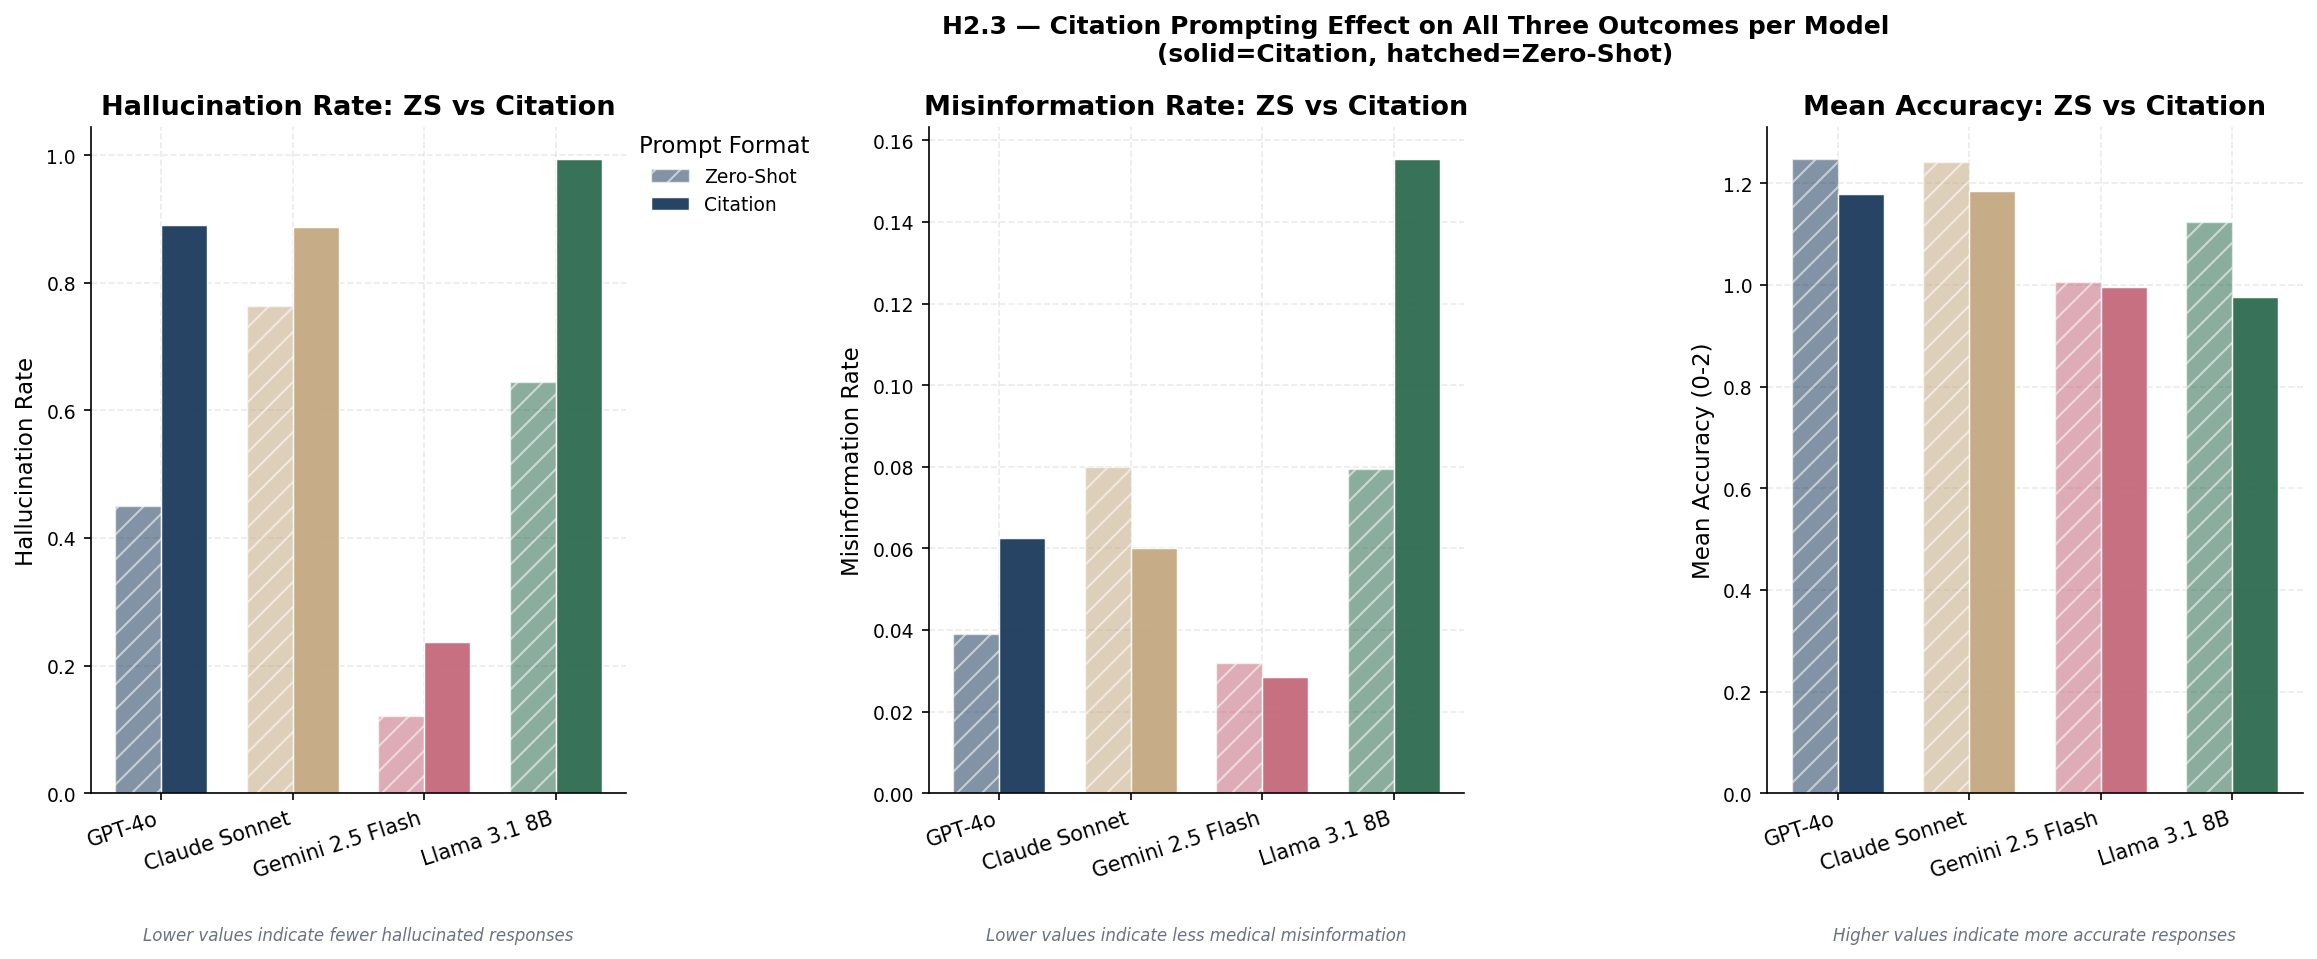

In [23]:
cit_stats = df_sig.groupby(['model_label','citation']).agg(
    hallucination_rate  = ('hallucination_label', 'mean'),
    misinformation_rate = ('misinformation_label', 'mean'),
    accuracy_mean       = ('accuracy_consensus',   'mean'),
    fake_cit_mean       = ('citation_fake_count',  'mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
x = np.arange(len(MODEL_ORDER))
w = 0.35

for ax, col, ylabel, title in [
    (axes[0], 'hallucination_rate',  'Hallucination Rate',    'Hallucination Rate: ZS vs Citation'),
    (axes[1], 'misinformation_rate', 'Misinformation Rate',   'Misinformation Rate: ZS vs Citation'),
    (axes[2], 'accuracy_mean',       'Mean Accuracy (0-2)',   'Mean Accuracy: ZS vs Citation'),
]:
    for cit_val, label, offset, alpha, hatch in [
        (False, 'Zero-Shot', -w/2, 0.55, '//'),
        (True,  'Citation',   w/2, 0.95, ''),
    ]:
        vals = []
        for m in MODEL_ORDER:
            sub = cit_stats[(cit_stats['model_label']==m) & (cit_stats['citation']==cit_val)]
            vals.append(sub[col].values[0] if len(sub) else 0)
        ax.bar(x+offset, vals, width=w,
               color=[MODEL_COLORS[m] for m in MODEL_ORDER],
               alpha=alpha, edgecolor='white', linewidth=0.7,
               label=label, hatch=hatch)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=18, ha='right', fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')

axes[0].legend(title='Prompt Format')
plt.suptitle('H2.3 — Citation Prompting Effect on All Three Outcomes per Model\n(solid=Citation, hatched=Zero-Shot)',
             fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.45, hspace=0.55, bottom=0.18)
standardize_figure(fig)
plt.savefig('charts/chart_09_h23_citation_effect.png', bbox_inches='tight')
plt.show()
plt.close(fig)


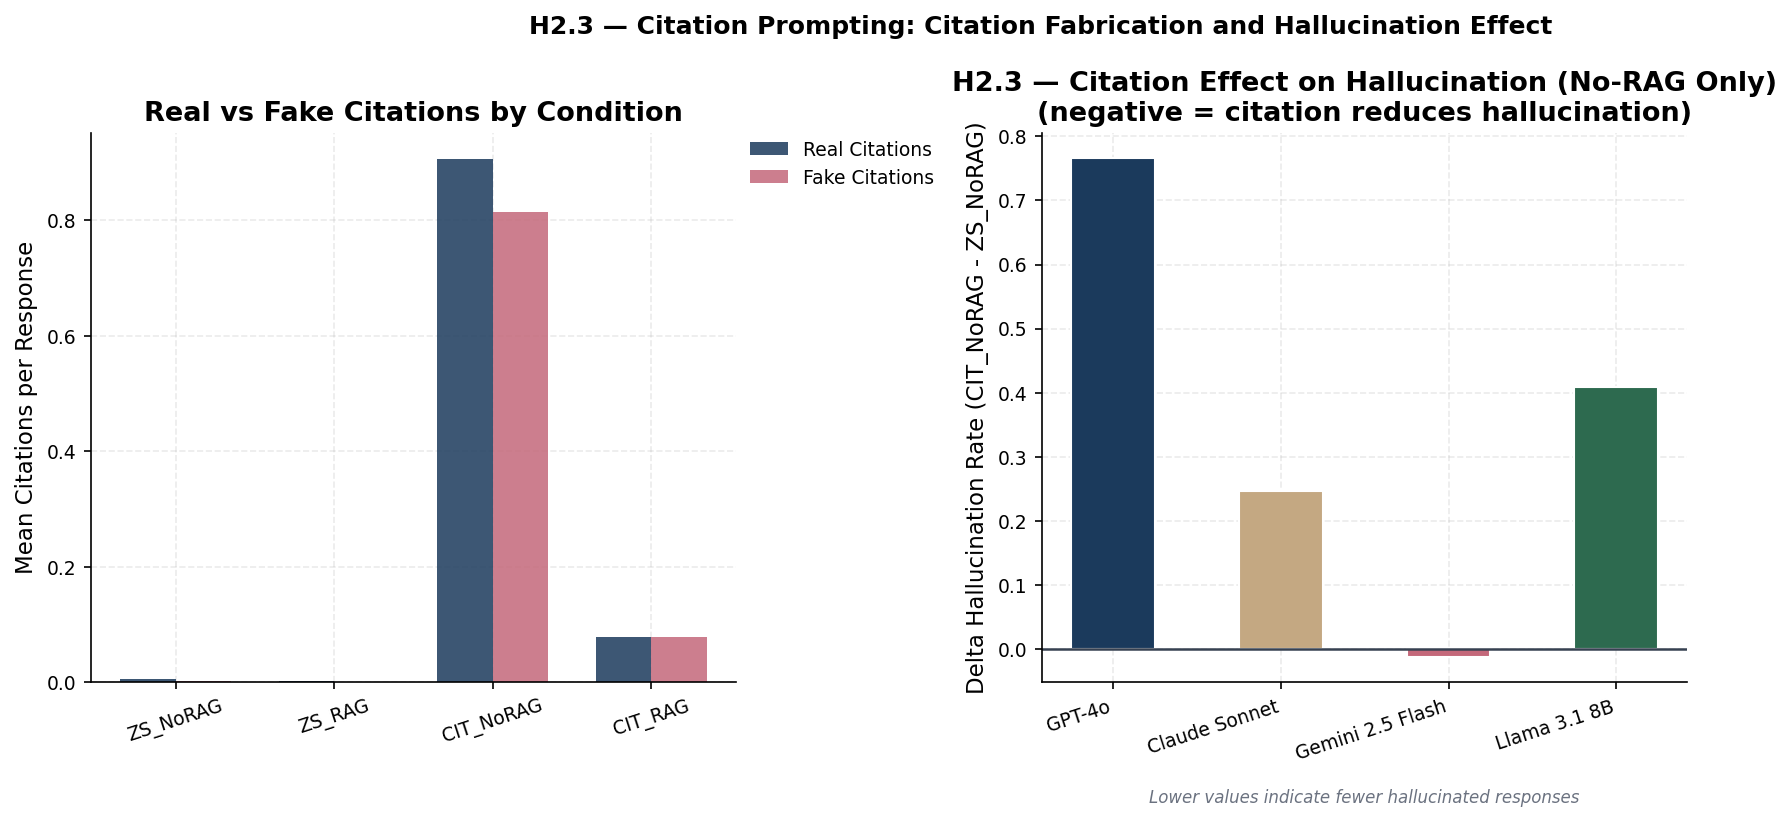

In [24]:
# fake citations — does citation prompting cause more fabrication?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# fake citation count by condition
cond_cit = df_sig.groupby('strategy_name').agg(
    fake_cit_mean = ('citation_fake_count', 'mean'),
    real_cit_mean = ('citation_real_count', 'mean'),
).reindex(COND_ORDER)

x = np.arange(len(COND_ORDER))
w = 0.35
axes[0].bar(x-w/2, cond_cit['real_cit_mean'], width=w, color=OUTCOME_COLORS['real_citation'], label='Real Citations', alpha=0.85)
axes[0].bar(x+w/2, cond_cit['fake_cit_mean'], width=w, color=OUTCOME_COLORS['fake_citation'], label='Fake Citations', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(COND_ORDER, rotation=18)
axes[0].set_ylabel('Mean Citations per Response')
axes[0].set_title('Real vs Fake Citations by Condition', fontweight='bold')
axes[0].legend()

# citation delta per model (no-RAG only)
no_rag_cit = df[df['rag']==False].groupby(['model_label','citation'])['hallucination_label'].mean().unstack()
cit_delta_norag = (no_rag_cit[True] - no_rag_cit[False]).reindex(MODEL_ORDER)
axes[1].bar(np.arange(len(MODEL_ORDER)), cit_delta_norag.values,
            color=[MODEL_COLORS[m] for m in MODEL_ORDER],
            width=0.5, edgecolor='white')
axes[1].axhline(0, color='#374151', linewidth=1.2)
axes[1].set_xticks(np.arange(len(MODEL_ORDER)))
axes[1].set_xticklabels(MODEL_ORDER, rotation=18, ha='right')
axes[1].set_ylabel('Delta Hallucination Rate (CIT_NoRAG - ZS_NoRAG)')
axes[1].set_title('H2.3 — Citation Effect on Hallucination (No-RAG Only)\n(negative = citation reduces hallucination)',
                  fontweight='bold')
for i, v in enumerate(cit_delta_norag.values):
    # In-plot value labels removed for publication-quality readability.
    pass

plt.suptitle('H2.3 — Citation Prompting: Citation Fabrication and Hallucination Effect',
             fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_10_h23_citation_detail.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---

## 9. H2.4 — Combined RAG and Citation Prompting

*Evaluates whether the combined CIT_RAG condition outperforms single-intervention and baseline conditions.*

**H2.4:** *The combination of retrieval-augmented generation and citation prompting will yield lower hallucination
and misinformation rates and higher accuracy scores than retrieval augmentation or citation prompting applied independently.*

This hypothesis predicts that CIT\_RAG is the best condition overall — associated with higher performance than ZS\_RAG (RAG alone) or
CIT\_NoRAG (citation alone). Statistical test: pairwise Mann-Whitney U comparisons between CIT\_RAG and
the other three conditions, Bonferroni corrected (3 comparisons, alpha = 0.05/3 ≈ 0.017).


In [25]:
print("=== H2.4: CIT_RAG vs All Other Conditions ===")
cit_rag  = df[df['strategy_name']=='CIT_RAG']
print(f"  CIT_RAG hallucination rate:  {cit_rag['hallucination_label'].mean():.3f}")
print(f"  CIT_RAG misinformation rate: {cit_rag['misinformation_label'].mean():.3f}")
print(f"  CIT_RAG accuracy consensus:  {cit_rag['accuracy_consensus'].mean():.3f}")
print()

for other in ['ZS_NoRAG','ZS_RAG','CIT_NoRAG']:
    other_df = df[df['strategy_name']==other]
    u, p = mannwhitneyu(cit_rag['accuracy_consensus'], other_df['accuracy_consensus'], alternative='greater')
    r = rank_biserial(u, len(cit_rag['accuracy_consensus']), len(other_df['accuracy_consensus']))
    sig = '***' if p < 0.0033 else ('**' if p < 0.017 else ('*' if p < 0.05 else 'ns'))
    delta_h = cit_rag['hallucination_label'].mean() - other_df['hallucination_label'].mean()
    print(f"  CIT_RAG vs {other:<12}  hallu delta={delta_h:+.3f}  Mann-Whitney U={u:.0f} p={p:.4f} r={r:.3f} ({interpret_r(r)} effect)  {sig}")

# H2.4 four-line verdict
best_h  = overall_cond['hallucination_rate'].idxmin()
best_m  = overall_cond['misinformation_rate'].idxmin()
best_a  = overall_cond['accuracy_mean'].idxmax()
h24_h = best_h == 'CIT_RAG'
h24_m = best_m == 'CIT_RAG'
h24_a = best_a == 'CIT_RAG'
n_h24 = sum([h24_h, h24_m, h24_a])
if n_h24 == 3:
    overall_h24 = 'Supported'
elif n_h24 == 0:
    overall_h24 = 'Not Supported'
else:
    overall_h24 = 'Partially Supported'
print(f"\n  H2.4 hallucination:  {'SUPPORTED' if h24_h else 'NOT SUPPORTED'} (lowest hallu rate: {best_h} = {overall_cond.loc[best_h,'hallucination_rate']:.3f})")
print(f"  H2.4 misinformation: {'SUPPORTED' if h24_m else 'NOT SUPPORTED'} (lowest misinfo rate: {best_m} = {overall_cond.loc[best_m,'misinformation_rate']:.3f})")
print(f"  H2.4 accuracy:       {'SUPPORTED' if h24_a else 'NOT SUPPORTED'} (highest accuracy: {best_a} = {overall_cond.loc[best_a,'accuracy_mean']:.3f})")
print(f"  H2.4 overall:        {overall_h24}  ({n_h24}/3 criteria met)")


h24_effect_rows = []
for other in ['ZS_NoRAG','ZS_RAG','CIT_NoRAG']:
    other_df = df[df['strategy_name']==other]
    u_tmp, p_tmp = mannwhitneyu(cit_rag['accuracy_consensus'], other_df['accuracy_consensus'], alternative='greater')
    r_tmp = rank_biserial(u_tmp, len(cit_rag), len(other_df))
    h24_effect_rows.append({'Comparison': f'CIT_RAG vs {other}', 'p': p_tmp, 'r': r_tmp, 'Interpretation': interpret_r(r_tmp)})
h24_effects = pd.DataFrame(h24_effect_rows)
print("\nH2.4 Mann-Whitney effect sizes:")
print(h24_effects.to_string(index=False, formatters={'p': '{:.4f}'.format, 'r': '{:.3f}'.format}))


=== H2.4: CIT_RAG vs All Other Conditions ===
  CIT_RAG hallucination rate:  0.772
  CIT_RAG misinformation rate: 0.032
  CIT_RAG accuracy consensus:  1.337

  CIT_RAG vs ZS_NoRAG      hallu delta=+0.392  Mann-Whitney U=10876926 p=0.0000 r=-0.360 (moderate effect)  ***
  CIT_RAG vs ZS_RAG        hallu delta=+0.163  Mann-Whitney U=7639266 p=0.9998 r=0.045 (negligible effect)  ns
  CIT_RAG vs CIT_NoRAG     hallu delta=+0.040  Mann-Whitney U=11880004 p=0.0000 r=-0.485 (moderate effect)  ***

  H2.4 hallucination:  NOT SUPPORTED (lowest hallu rate: ZS_NoRAG = 0.381)
  H2.4 misinformation: NOT SUPPORTED (lowest misinfo rate: ZS_RAG = 0.023)
  H2.4 accuracy:       NOT SUPPORTED (highest accuracy: ZS_RAG = 1.366)
  H2.4 overall:        Not Supported  (0/3 criteria met)

H2.4 Mann-Whitney effect sizes:
          Comparison      p      r Interpretation
 CIT_RAG vs ZS_NoRAG 0.0000 -0.360       moderate
   CIT_RAG vs ZS_RAG 0.9998  0.045     negligible
CIT_RAG vs CIT_NoRAG 0.0000 -0.485       mod

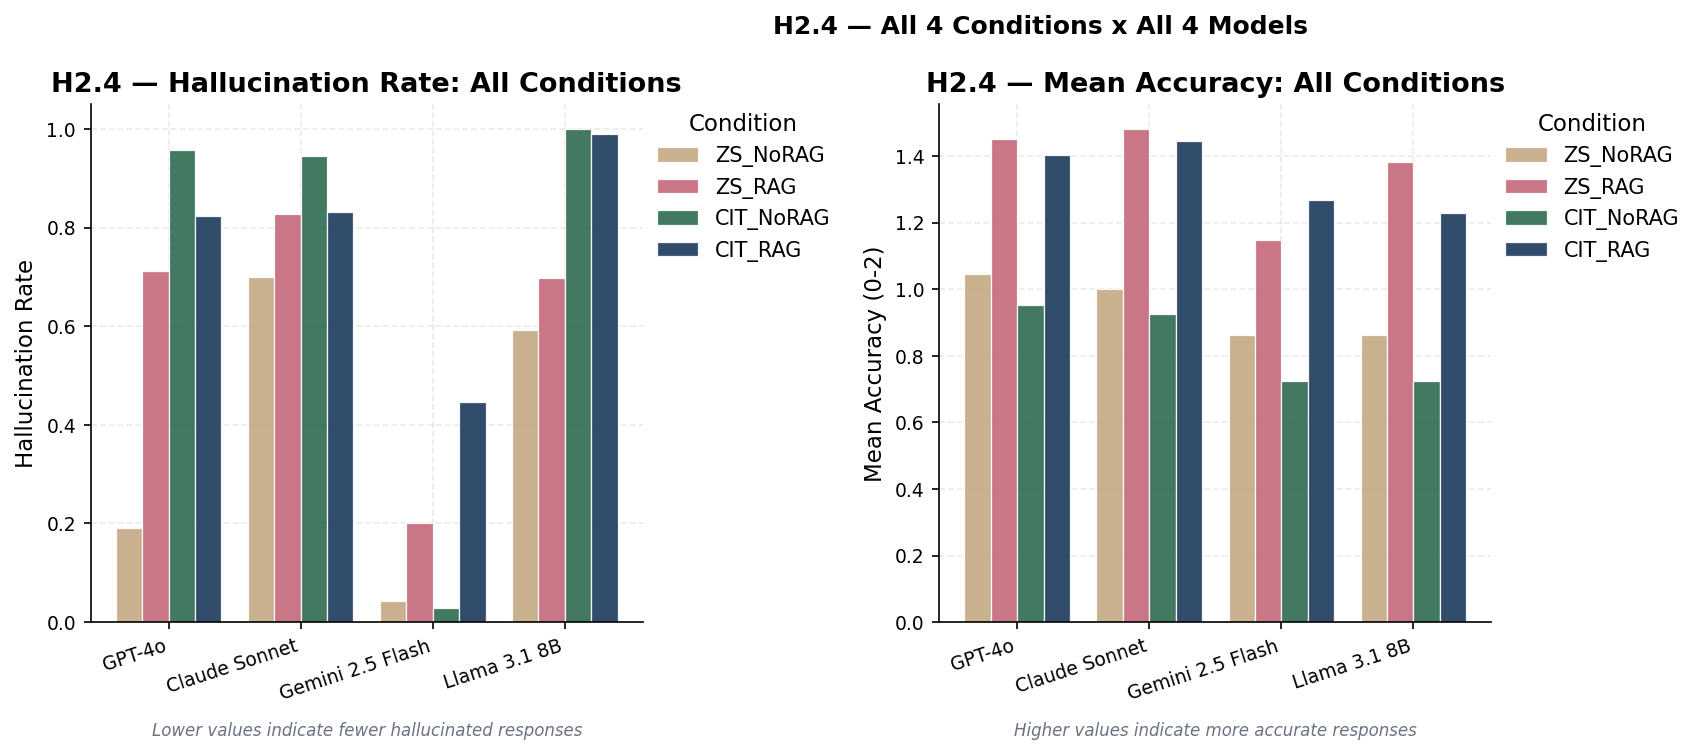

In [26]:
# full 4-condition grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(MODEL_ORDER))
w = 0.2
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * w

for ax, metric, ylabel, title in [
    (axes[0], 'hallucination_rate', 'Hallucination Rate', 'H2.4 — Hallucination Rate: All Conditions'),
    (axes[1], 'accuracy_mean',      'Mean Accuracy (0-2)', 'H2.4 — Mean Accuracy: All Conditions'),
]:
    for cond, offset in zip(COND_ORDER, offsets):
        vals = []
        for m in MODEL_ORDER:
            sub = cond_stats[(cond_stats['model_label']==m) & (cond_stats['strategy_name']==cond)]
            vals.append(sub[metric].values[0] if len(sub) else 0)
        ax.bar(x+offset, vals, width=w, color=COND_COLORS[cond],
               edgecolor='white', linewidth=0.6, label=cond, alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=18, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(title='Condition', fontsize=10)

plt.suptitle('H2.4 — All 4 Conditions x All 4 Models', fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.45, hspace=0.55, bottom=0.18)
standardize_figure(fig)
plt.savefig('charts/chart_11_h24_all_conditions.png', bbox_inches='tight')
plt.show()
plt.close(fig)


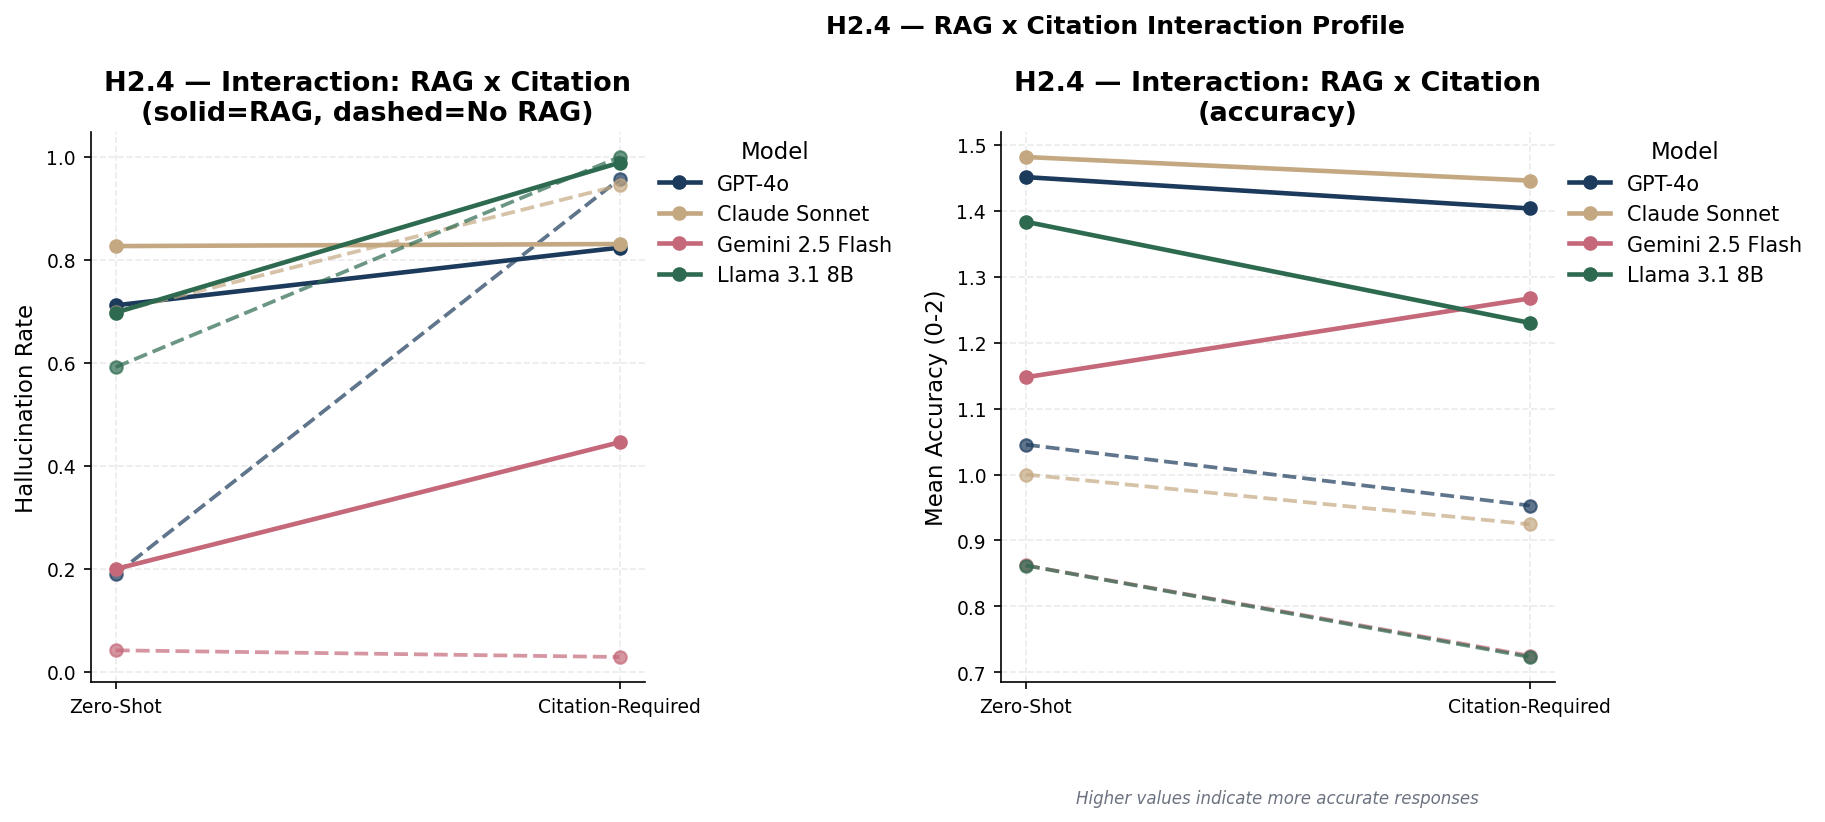

In [27]:
# interaction profile — RAG x Citation per model
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, metric, ylabel, title in [
    (axes[0], 'hallucination_rate', 'Hallucination Rate',
     'H2.4 — Interaction: RAG x Citation\n(solid=RAG, dashed=No RAG)'),
    (axes[1], 'accuracy_mean',      'Mean Accuracy (0-2)',
     'H2.4 — Interaction: RAG x Citation\n(accuracy)'),
]:
    for model in MODEL_ORDER:
        sub = cond_stats[cond_stats['model_label']==model].set_index('strategy_name')
        try:
            no_rag_pts = [sub.loc['ZS_NoRAG', metric], sub.loc['CIT_NoRAG', metric]]
            rag_pts    = [sub.loc['ZS_RAG',   metric], sub.loc['CIT_RAG',   metric]]
        except KeyError:
            continue
        ax.plot([0,1], no_rag_pts, 'o--', color=MODEL_COLORS[model], linewidth=1.8, alpha=0.7)
        ax.plot([0,1], rag_pts,    'o-',  color=MODEL_COLORS[model], linewidth=2.2, label=model)

    ax.set_xticks([0,1])
    ax.set_xticklabels(['Zero-Shot', 'Citation-Required'])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(title='Model', fontsize=10)

plt.suptitle('H2.4 — RAG x Citation Interaction Profile', fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.45, hspace=0.40, bottom=0.16)
standardize_figure(fig)
plt.savefig('charts/chart_12_h24_interaction_profile.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---

## 10. Difficulty and Hallucination Category Analysis

*Assesses whether question difficulty and MedHallu category moderate hallucination and RAG effects.*

RQ2 asks explicitly whether the effects of RAG and citation prompting *differ across question difficulty levels*.
This section examines (1) baseline hallucination rates by difficulty and (2) whether RAG/citation effects
are moderated by difficulty.


In [28]:
diff_stats = df.groupby('difficulty').agg(
    hallucination_rate  = ('hallucination_label', 'mean'),
    misinformation_rate = ('misinformation_label', 'mean'),
    accuracy_mean       = ('accuracy_consensus',   'mean'),
    n                   = ('response_id', 'count'),
)

cat_stats = df.groupby('hallucination_category').agg(
    hallucination_rate  = ('hallucination_label', 'mean'),
    misinformation_rate = ('misinformation_label', 'mean'),
    accuracy_mean       = ('accuracy_consensus',   'mean'),
    n                   = ('response_id', 'count'),
).sort_values('hallucination_rate', ascending=False)

print("=== By Difficulty ===")
print(diff_stats.round(4).to_string())
print("\n=== By Hallucination Category ===")
print(cat_stats.round(4).to_string())

# does RAG help more on hard questions?
for diff in df['difficulty'].unique():
    sub = df[df['difficulty']==diff]
    delta = sub[sub['rag']]['hallucination_label'].mean() - sub[~sub['rag']]['hallucination_label'].mean()
    print(f"  [{diff}] RAG delta on hallucination: {delta:+.3f}")


=== By Difficulty ===
            hallucination_rate  misinformation_rate  accuracy_mean     n
difficulty                                                              
easy                    0.6152               0.0468         1.2060  4384
hard                    0.6313               0.0838         1.0244  6528
medium                  0.6217               0.0633         1.1656  5088

=== By Hallucination Category ===
                                         hallucination_rate  misinformation_rate  accuracy_mean      n
hallucination_category                                                                                
Misinterpretation of #Question#                      0.6248               0.0688         1.1126  12032
Incomplete Information                               0.6247               0.0622         1.1122   3392
Mechanism and Pathway Misattribution                 0.6042               0.0530         1.3030    528
Methodological and Evidence Fabrication              0.5208    

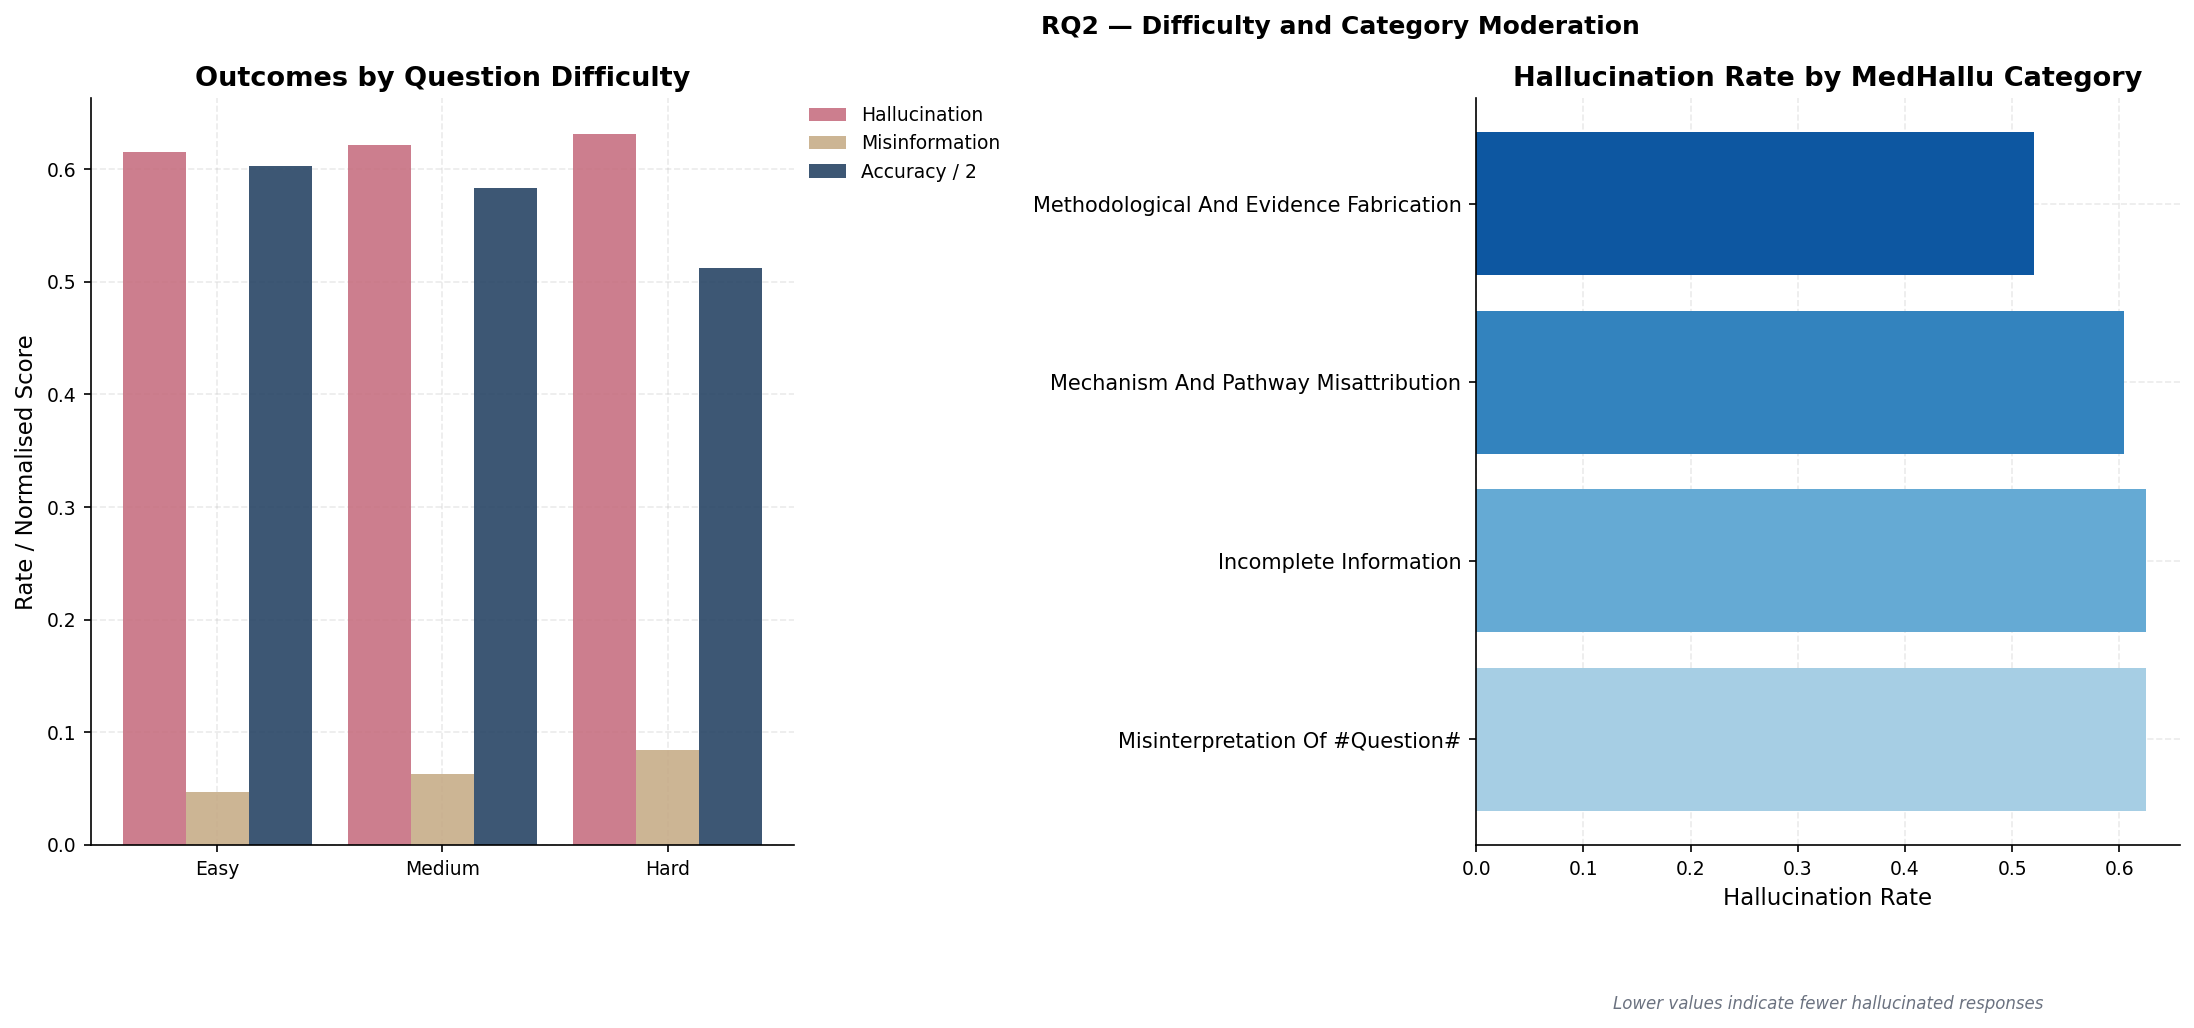

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

diff_order = [d for d in ['easy','medium','hard'] if d in diff_stats.index]
diff_order = diff_order if diff_order else diff_stats.index.tolist()
diff_s = diff_stats.reindex(diff_order)

x = np.arange(len(diff_order))
w = 0.28
axes[0].bar(x-w,   diff_s['hallucination_rate'],  width=w, color=OUTCOME_COLORS['hallucination'], alpha=0.85, label='Hallucination')
axes[0].bar(x,     diff_s['misinformation_rate'],  width=w, color=OUTCOME_COLORS['misinformation'], alpha=0.85, label='Misinformation')
axes[0].bar(x+w,   diff_s['accuracy_mean']/2,      width=w, color=OUTCOME_COLORS['accurate'], alpha=0.85, label='Accuracy / 2')
axes[0].set_xticks(x)
axes[0].set_xticklabels([d.capitalize() for d in diff_order])
axes[0].set_ylabel('Rate / Normalised Score')
axes[0].set_title('Outcomes by Question Difficulty', fontweight='bold')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=9)

cat_h = cat_stats['hallucination_rate']
y_pos = np.arange(len(cat_h))
axes[1].barh(y_pos, cat_h.values,
             color=plt.cm.Blues(np.linspace(0.35, 0.85, len(cat_h))))
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([c.replace('_',' ').title() for c in cat_h.index], fontsize=10)
axes[1].set_xlabel('Hallucination Rate')
axes[1].set_title('Hallucination Rate by MedHallu Category', fontweight='bold')
for i, v in enumerate(cat_h.values):
    # In-plot value labels removed for publication-quality readability.
    pass

plt.suptitle('RQ2 — Difficulty and Category Moderation', fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.45, hspace=0.35, bottom=0.16)
standardize_figure(fig)
plt.savefig('charts/chart_13_difficulty_category.png', bbox_inches='tight')
plt.show()
plt.close(fig)


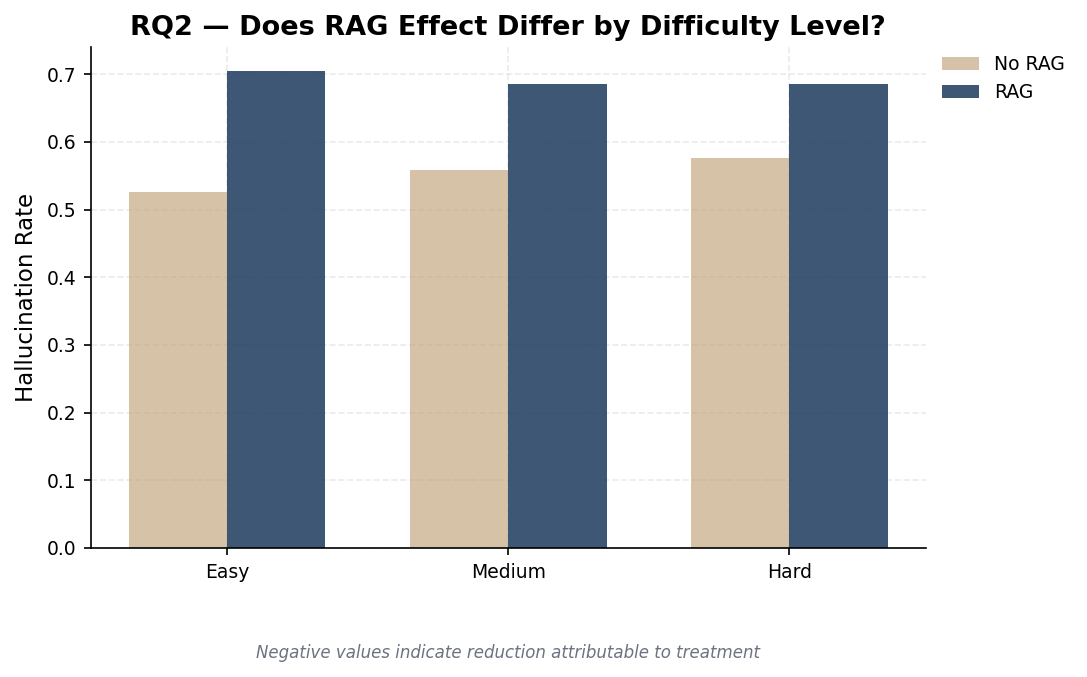

In [30]:
# RAG effect moderated by difficulty
rag_diff = df.groupby(['difficulty','rag'])['hallucination_label'].mean().unstack()
diff_order_plot = [d for d in ['easy','medium','hard'] if d in rag_diff.index]
if not diff_order_plot:
    diff_order_plot = rag_diff.index.tolist()
rag_diff = rag_diff.reindex(diff_order_plot)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(diff_order_plot))
w = 0.35
ax.bar(x-w/2, rag_diff[False].values, width=w, color=OUTCOME_COLORS['no_rag'], alpha=0.7, label='No RAG')
ax.bar(x+w/2, rag_diff[True].values,  width=w, color=OUTCOME_COLORS['rag'], alpha=0.85, label='RAG')
ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in diff_order_plot])
ax.set_ylabel('Hallucination Rate')
ax.set_title('RQ2 — Does RAG Effect Differ by Difficulty Level?', fontweight='bold')
ax.legend()
for i, (no_r, wi_r) in enumerate(zip(rag_diff[False].values, rag_diff[True].values)):
    delta = wi_r - no_r
# In-plot value labels removed for publication-quality readability.
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_14_difficulty_rag_moderation.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---
## 11. Automated Evaluation Signals

*Examines whether automated evaluation signals align with final judge-panel outcomes.*


In [31]:
print("=== Automated Signal Overview ===")
print("\nBioBERT F1 (semantic similarity to ground truth):")
print(df_sig['biobert_f1'].describe().round(3).to_string())
print("\nFActScore F1 (atomic claim grounding via PubMed):")
print(df_sig['factscore_f1'].describe().round(3).to_string())
print("\nMedNLI (misinformation signal — claim vs ground truth):")
print(df_sig['misinfo_nli_signal'].value_counts().to_string())
print("\nAutomated track verdict:")
print(df_sig['automated_track_verdict'].value_counts().to_string())

# do automated signals predict hallucination?
for col in ['biobert_f1','factscore_f1']:
    a = df_sig[df_sig['hallucination_label']==0][col].dropna().values
    b = df_sig[df_sig['hallucination_label']==1][col].dropna().values
    if len(a) > 0 and len(b) > 0:
        u, p = mannwhitneyu(a, b, alternative='greater')
        r = rank_biserial(u, len(a), len(b))
        print(f"  {col} not-hallu vs hallu: U={u:.0f} p={p:.4f} r={r:.3f} ({interpret_r(r)} effect)  ({'signal valid' if p<0.05 else 'not significant'})")


=== Automated Signal Overview ===

BioBERT F1 (semantic similarity to ground truth):
count    16000.000
mean         0.705
std          0.062
min          0.517
25%          0.658
50%          0.706
75%          0.751
max          0.922

FActScore F1 (atomic claim grounding via PubMed):
count    16000.000
mean         0.458
std          0.308
min          0.000
25%          0.200
50%          0.400
75%          0.667
max          1.000

MedNLI (misinformation signal — claim vs ground truth):
misinfo_nli_signal
entailment       12855
contradiction     3099
neutral             46

Automated track verdict:
automated_track_verdict
uncertain              14078
likely_accurate         1448
likely_hallucinated      474
  biobert_f1 not-hallu vs hallu: U=47199635 p=0.0000 r=-0.571 (large effect)  (signal valid)
  factscore_f1 not-hallu vs hallu: U=37012443 p=0.0000 r=-0.232 (small effect)  (signal valid)


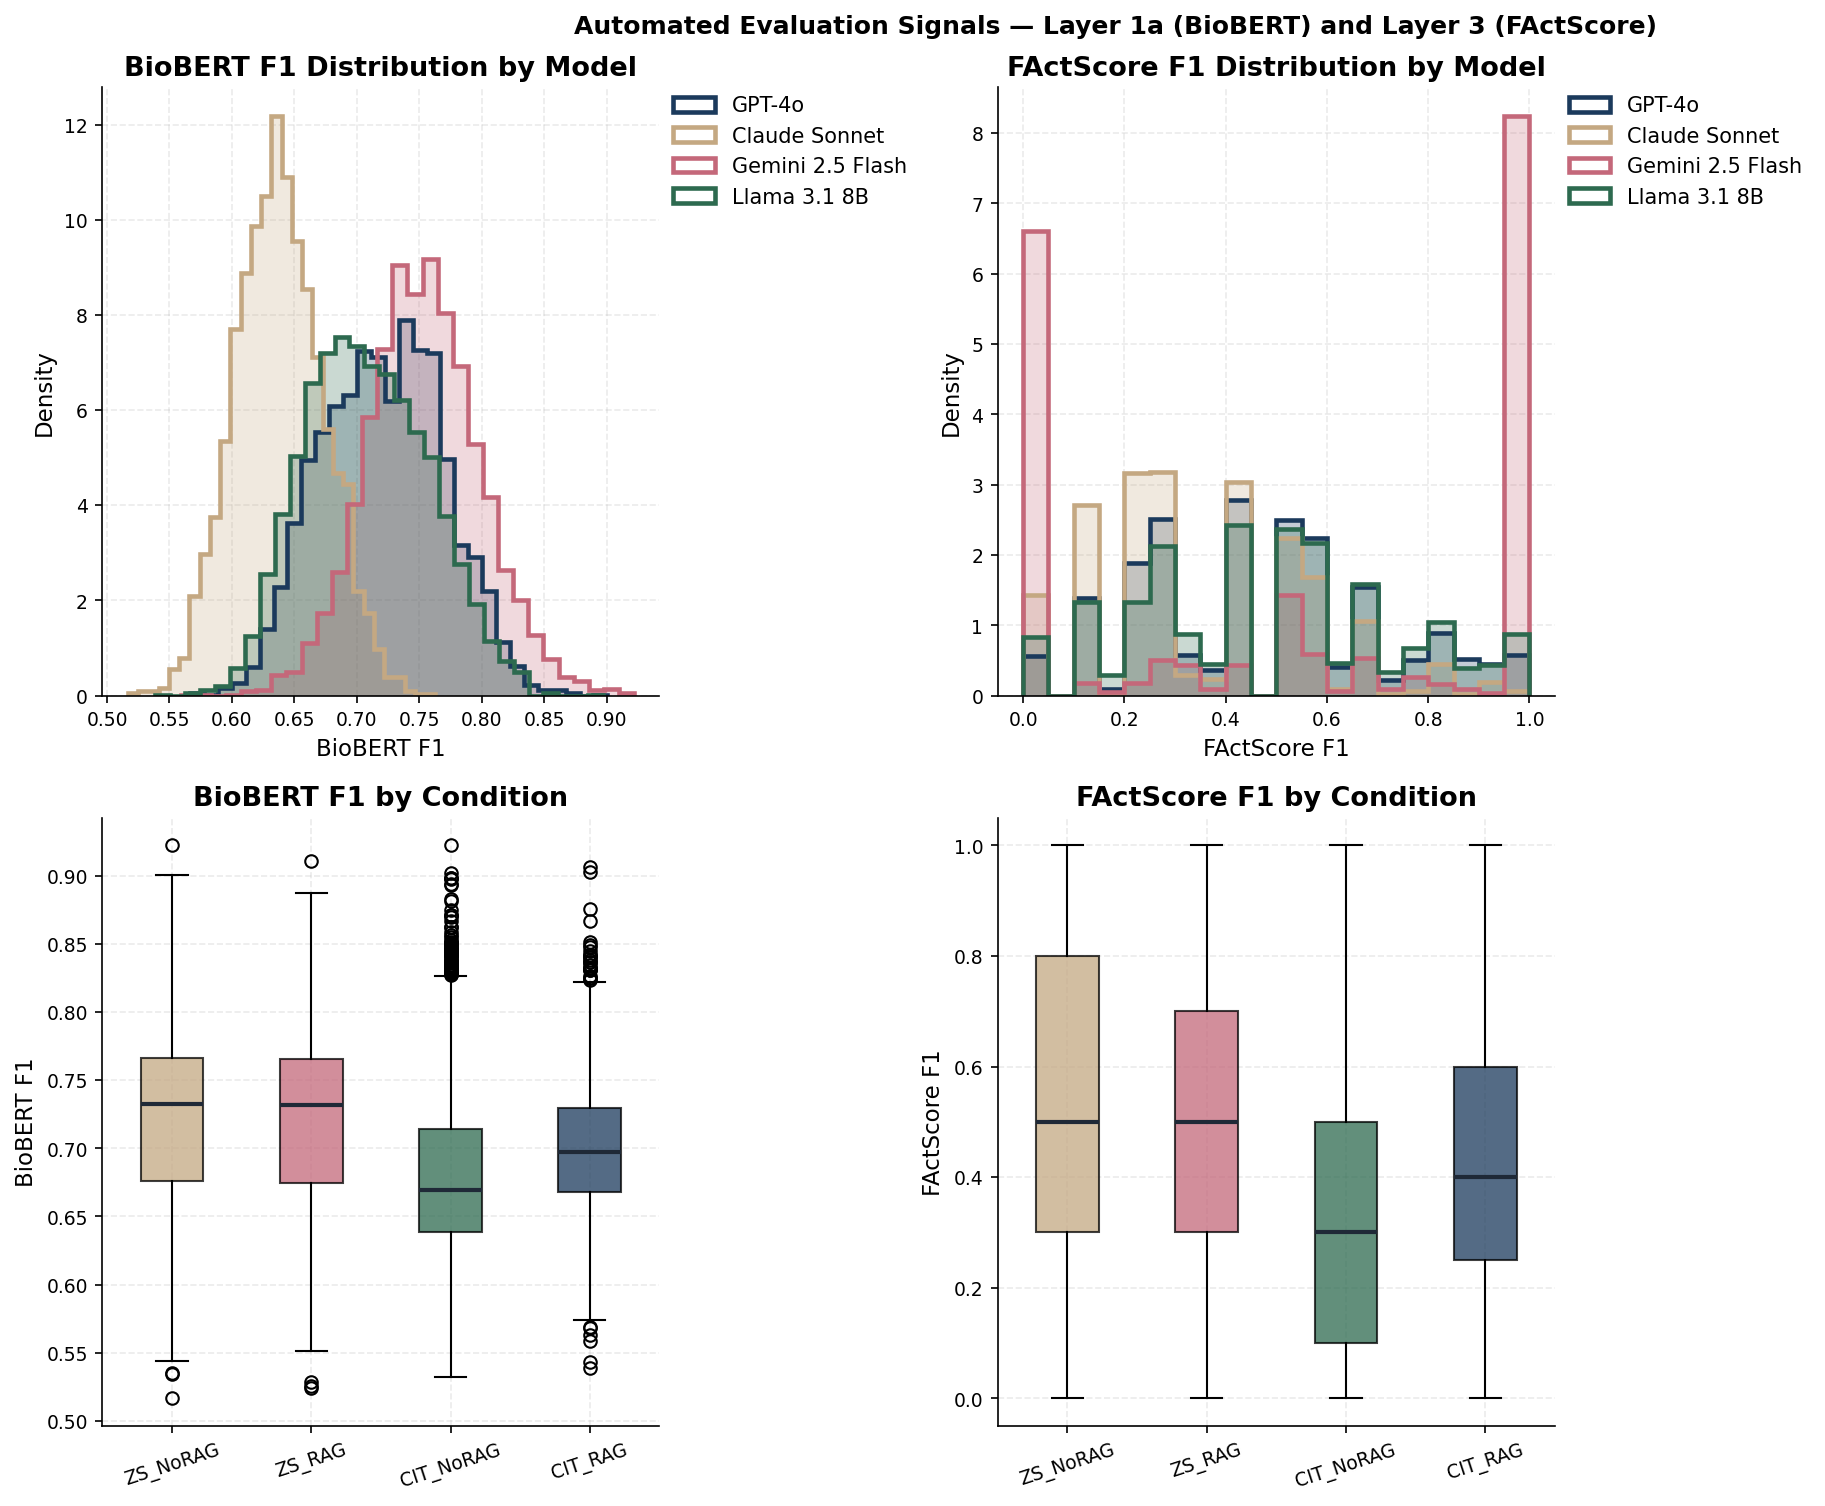

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# BioBERT by model
for model in MODEL_ORDER:
    sub = df_sig[df_sig['model_label']==model]
    axes[0,0].hist(sub['biobert_f1'].dropna(), bins=30,
                   histtype='stepfilled', alpha=0.25, color=MODEL_COLORS[model], density=True)
    axes[0,0].hist(sub['biobert_f1'].dropna(), bins=30,
                   histtype='step', linewidth=2.2, color=MODEL_COLORS[model], label=model, density=True)
axes[0,0].set_xlabel('BioBERT F1')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('BioBERT F1 Distribution by Model', fontweight='bold')
axes[0,0].legend(fontsize=10)

# FActScore by model
for model in MODEL_ORDER:
    sub = df_sig[df_sig['model_label']==model]
    axes[0,1].hist(sub['factscore_f1'].dropna(), bins=20,
                   histtype='stepfilled', alpha=0.25, color=MODEL_COLORS[model], density=True)
    axes[0,1].hist(sub['factscore_f1'].dropna(), bins=20,
                   histtype='step', linewidth=2.2, color=MODEL_COLORS[model], label=model, density=True)
axes[0,1].set_xlabel('FActScore F1')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('FActScore F1 Distribution by Model', fontweight='bold')
axes[0,1].legend(fontsize=10)

# BioBERT by condition
bp_b = [df_sig[df_sig['strategy_name']==c]['biobert_f1'].dropna().values for c in COND_ORDER]
bp = axes[1,0].boxplot(bp_b, labels=COND_ORDER, patch_artist=True, medianprops=dict(color='#1f2937',linewidth=2))
for patch, cond in zip(bp['boxes'], COND_ORDER):
    patch.set_facecolor(COND_COLORS[cond])
    patch.set_alpha(0.75)
axes[1,0].set_ylabel('BioBERT F1')
axes[1,0].set_title('BioBERT F1 by Condition', fontweight='bold')
axes[1,0].set_xticklabels(COND_ORDER, rotation=18)

# FActScore by condition
bp_f = [df_sig[df_sig['strategy_name']==c]['factscore_f1'].dropna().values for c in COND_ORDER]
bp2 = axes[1,1].boxplot(bp_f, labels=COND_ORDER, patch_artist=True, medianprops=dict(color='#1f2937',linewidth=2))
for patch, cond in zip(bp2['boxes'], COND_ORDER):
    patch.set_facecolor(COND_COLORS[cond])
    patch.set_alpha(0.75)
axes[1,1].set_ylabel('FActScore F1')
axes[1,1].set_title('FActScore F1 by Condition', fontweight='bold')
axes[1,1].set_xticklabels(COND_ORDER, rotation=18)

plt.suptitle('Automated Evaluation Signals — Layer 1a (BioBERT) and Layer 3 (FActScore)',
             fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_15_automated_signals.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---
## Signal-Outcome Correlation Matrix

*Visualises the relationship between automated signals and final judge-panel outcomes.*


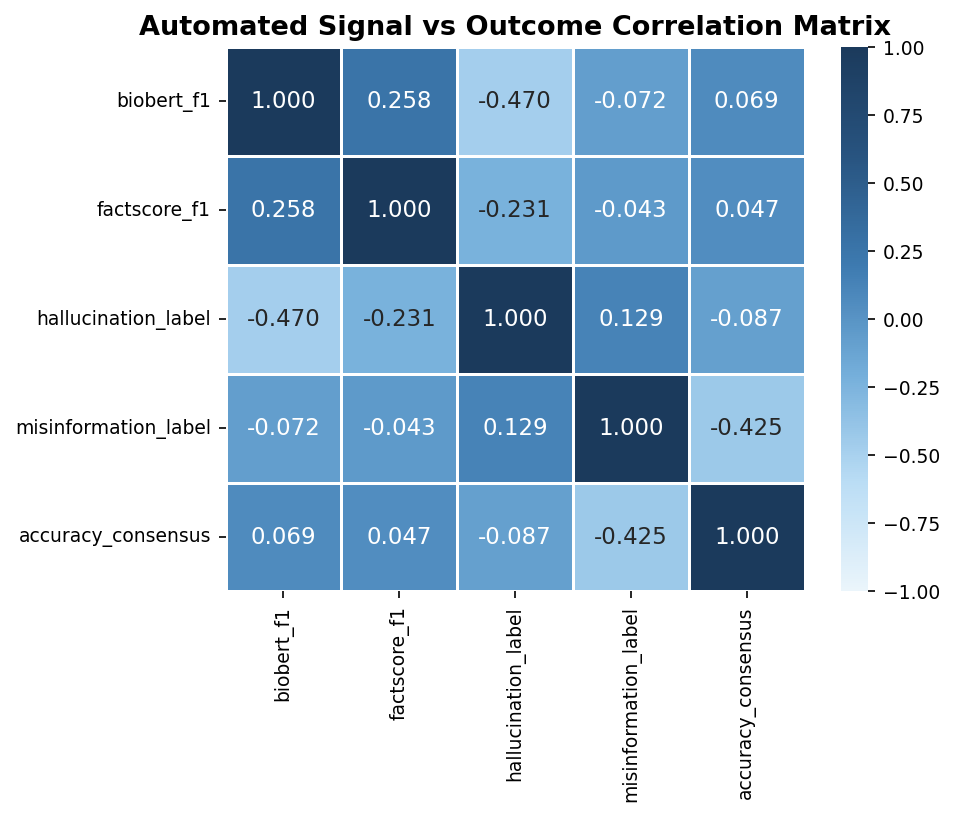

In [33]:
corr_cols = ['biobert_f1','factscore_f1','hallucination_label','misinformation_label','accuracy_consensus']
corr_matrix = df_sig[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap=ROSE_CMAP, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Automated Signal vs Outcome Correlation Matrix', fontweight='bold')
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_18_signal_outcome_correlation.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---
## 12. Judge Panel Analysis

*Summarises judge-panel behaviour before inter-rater reliability and sensitivity analyses.*


In [34]:
print("=== Judge Consensus Distributions ===")
for col, label in [('accuracy_consensus','Accuracy (0-2)'),
                   ('hallucination_consensus','Hallucination (0-1)'),
                   ('misinformation_consensus','Misinformation (0-1)')]:
    print(f"\n{label}:")
    print(df[col].describe().round(3).to_string())

tc = df['track_consensus'].mean()
print(f"\nOverall automated-judge track consensus: {tc:.1%}")

judge_df = judges.merge(
    models_df[['model_id','model_name']],
    left_on='judge_id', right_on='model_id', how='left'
)
jname_map = {
    'GPT-4o':            'GPT-4o',
    'Claude Sonnet 4.6': 'Claude Sonnet',
    'Gemini 2.5 Flash':  'Gemini 2.5 Flash',
    'DeepSeek V4 Flash': 'DeepSeek V4 Flash',
}
judge_df['judge_label'] = judge_df['model_name'].map(jname_map).fillna(judge_df['model_name'])
judge_order = ['GPT-4o','Claude Sonnet','Gemini 2.5 Flash','DeepSeek V4 Flash']

judge_summary = judge_df.groupby('judge_label').agg(
    mean_accuracy    = ('judge_accuracy_score',    'mean'),
    hallu_rate       = ('judge_hallucination_vote', 'mean'),
    misinfo_rate     = ('judge_misinformation_vote','mean'),
    n                = ('evaluation_id', 'count'),
).reindex(judge_order)
print("\n=== Per-Judge Voting Summary ===")
print(judge_summary.round(4).to_string())


=== Judge Consensus Distributions ===

Accuracy (0-2):
count    16000.000
mean         1.119
std          0.605
min          0.000
25%          0.750
50%          1.250
75%          1.500
max          2.000

Hallucination (0-1):
count    16000.000
mean         0.545
std          0.394
min          0.000
25%          0.250
50%          0.500
75%          1.000
max          1.000

Misinformation (0-1):
count    16000.000
mean         0.073
std          0.173
min          0.000
25%          0.000
50%          0.000
75%          0.000
max          1.000

Overall automated-judge track consensus: 98.2%

=== Per-Judge Voting Summary ===
                   mean_accuracy  hallu_rate  misinfo_rate      n
judge_label                                                      
GPT-4o                    0.9776      0.7094        0.1269  16000
Claude Sonnet             1.1660      0.5611        0.0316  16000
Gemini 2.5 Flash          1.0733      0.4382        0.0340  16000
DeepSeek V4 Flash         1.2594

---
## Inter-Rater Reliability and Judge Sensitivity

*Reports Fleiss' Kappa and DeepSeek-only sensitivity checks for label reliability and circularity risk.*


In [35]:
kappa_rows = []
for metric, vote_col in [
    ('Hallucination', 'judge_hallucination_vote'),
    ('Misinformation', 'judge_misinformation_vote'),
    ('Accuracy', 'judge_accuracy_score'),
]:
    matrix = fleiss_matrix_from_votes(judge_df, 'response_id', vote_col)
    kappa = fleiss_kappa(matrix, method='fleiss')
    kappa_rows.append({'Metric': metric, 'Kappa': kappa, 'Interpretation': kappa_interpretation(kappa)})
kappa_table = pd.DataFrame(kappa_rows)
print("=== Fleiss' Kappa Inter-Rater Reliability ===")
display(kappa_table.round({'Kappa': 3}))

deepseek_votes = judge_df[judge_df['judge_label']=='DeepSeek V4 Flash'].copy()
deepseek_merged = deepseek_votes.merge(df[['response_id','model_label','strategy_name','rag','citation']], on='response_id')
deepseek_by_model = deepseek_merged.groupby('model_label').agg(
    hallu_rate=('judge_hallucination_vote','mean'),
    acc_mean=('judge_accuracy_score','mean')
).reindex(MODEL_ORDER)
panel_by_model = df.groupby('model_label').agg(
    hallu_rate=('hallucination_label','mean'),
    acc_mean=('accuracy_consensus','mean')
).reindex(MODEL_ORDER)
comparison = pd.DataFrame({
    'Hallucination - Full Panel': panel_by_model['hallu_rate'],
    'Hallucination - DeepSeek Only': deepseek_by_model['hallu_rate'],
    'Accuracy - Full Panel': panel_by_model['acc_mean'],
    'Accuracy - DeepSeek Only': deepseek_by_model['acc_mean'],
})
comparison['Hallucination Absolute Difference'] = (comparison['Hallucination - Full Panel'] - comparison['Hallucination - DeepSeek Only']).abs()
comparison['Accuracy Absolute Difference'] = (comparison['Accuracy - Full Panel'] - comparison['Accuracy - DeepSeek Only']).abs()
print("\n=== DeepSeek-Only Sensitivity Analysis ===")
display(comparison.round(4))
print("Interpretation: if the DeepSeek-only model ordering and rates closely track the full panel, circularity bias from evaluated models also acting as judges did not materially distort the aggregate labels.")


=== Fleiss' Kappa Inter-Rater Reliability ===


,Metric,Kappa,Interpretation
0,Hallucination,0.500,Moderate
1,Misinformation,0.258,Fair
2,Accuracy,0.426,Moderate



=== DeepSeek-Only Sensitivity Analysis ===


,Hallucination - Full Panel,Hallucination - DeepSeek Only,Accuracy - Full Panel,Accuracy - DeepSeek Only,Hallucination Absolute Difference,Accuracy Absolute Difference
model_label,,,,,,
GPT-4o,0.6708,0.5042,1.2132,1.3735,0.1665,0.1603
Claude Sonnet,0.8255,0.5805,1.2129,1.3710,0.2450,0.1581
Gemini 2.5 Flash,0.1792,0.1500,1.0005,1.0735,0.0292,0.0730
Llama 3.1 8B,0.8198,0.6490,1.0496,1.2195,0.1707,0.1699


Interpretation: if the DeepSeek-only model ordering and rates closely track the full panel, circularity bias from evaluated models also acting as judges did not materially distort the aggregate labels.


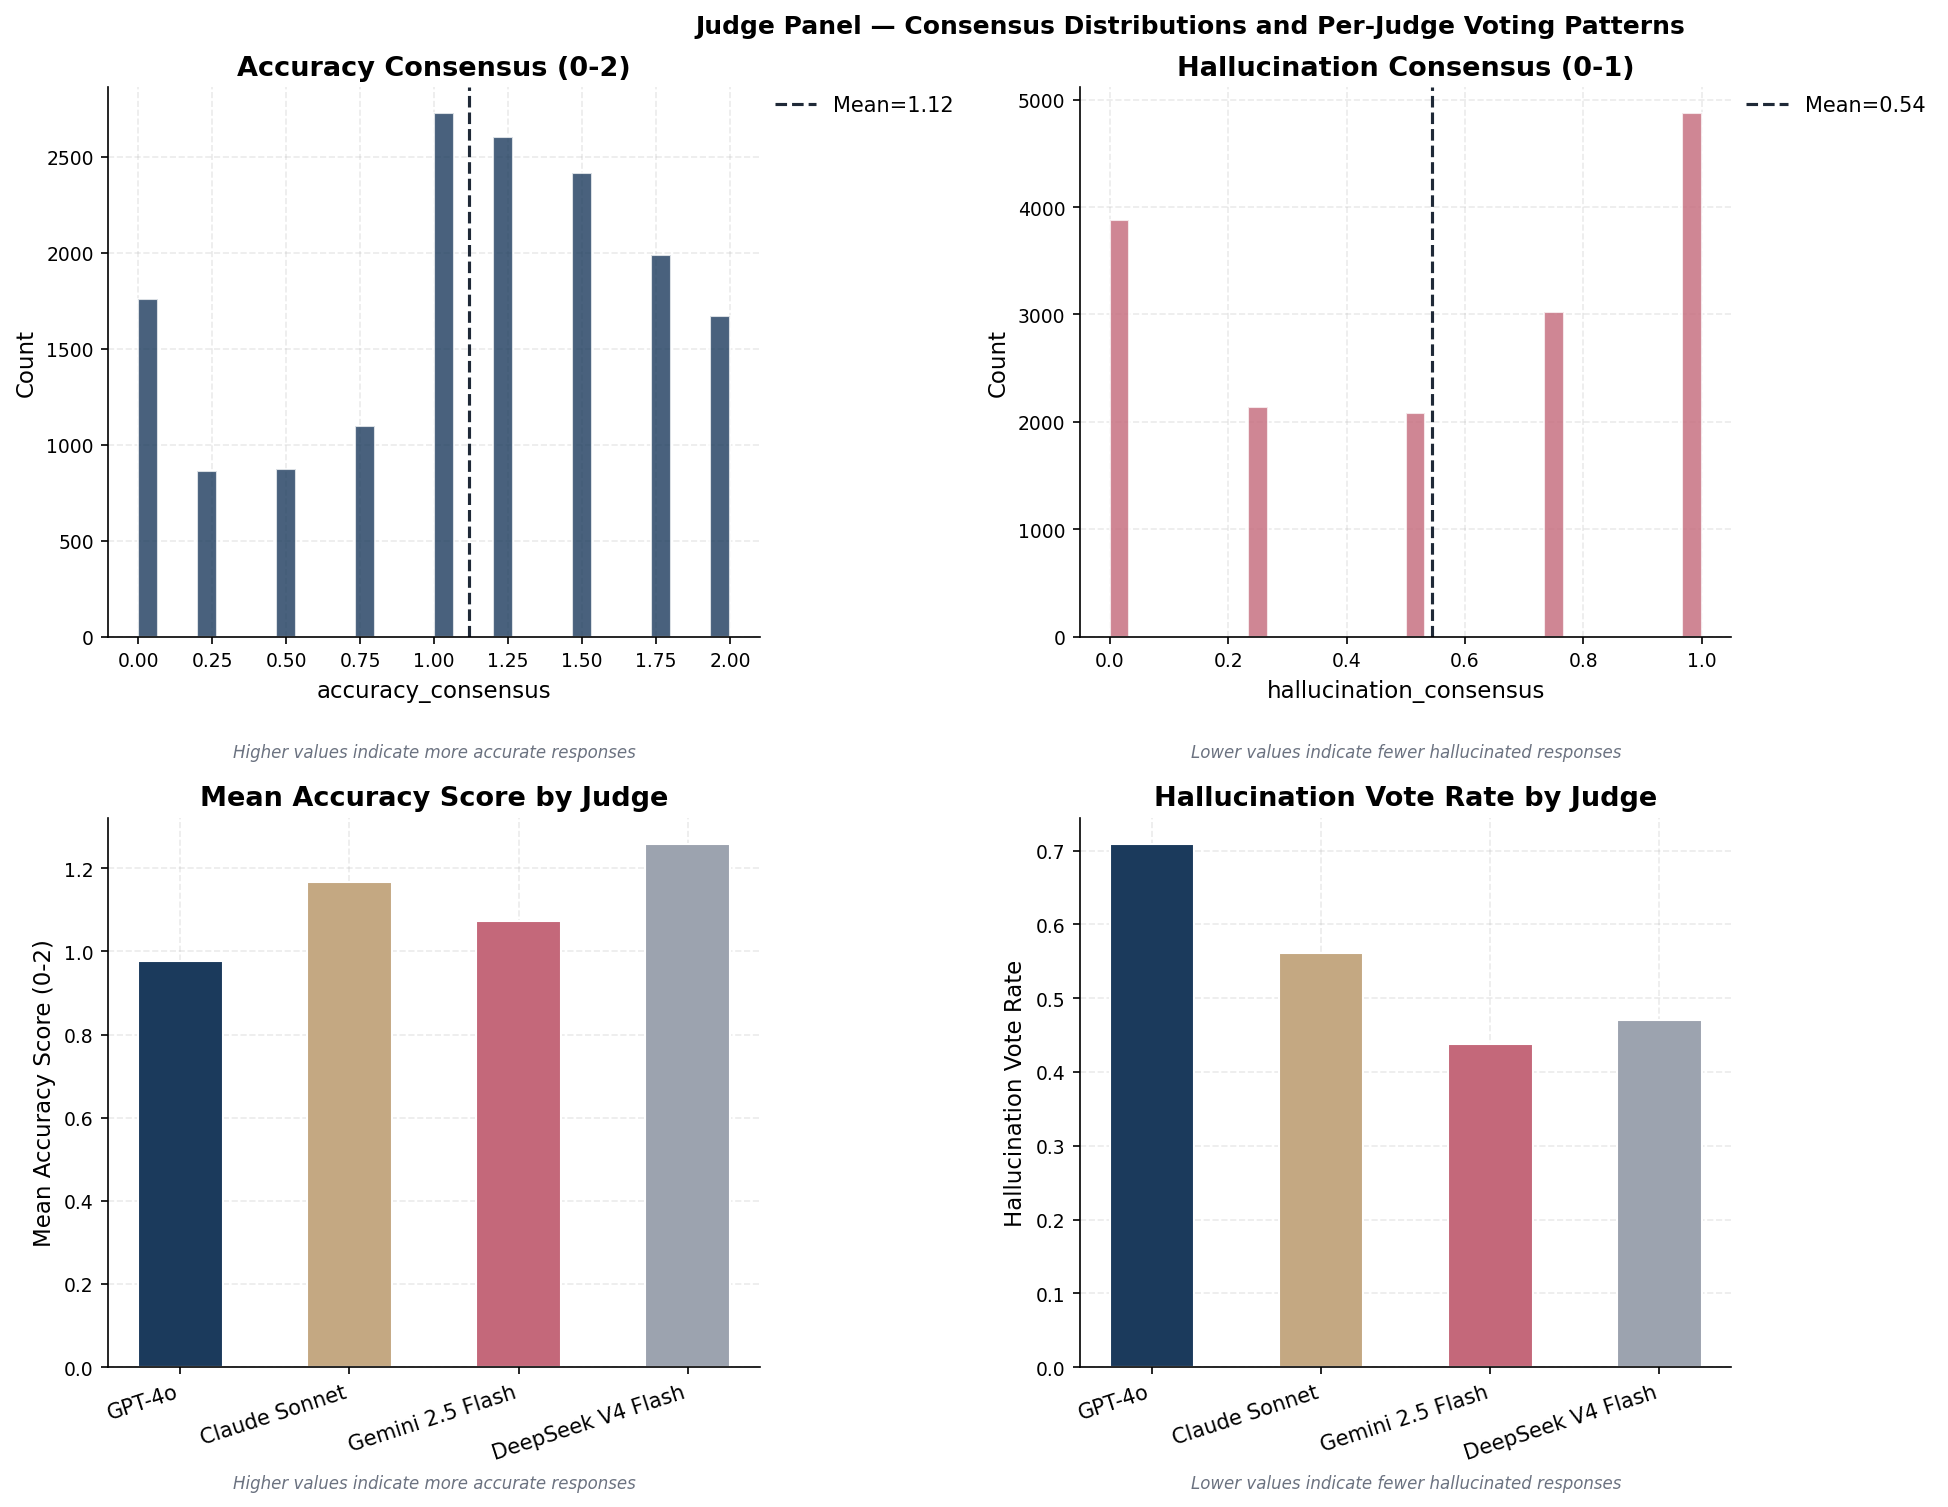

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# consensus histograms
for ax, col, title, color in [
    (axes[0,0], 'accuracy_consensus',       'Accuracy Consensus (0-2)',       OUTCOME_COLORS['accurate']),
    (axes[0,1], 'hallucination_consensus',  'Hallucination Consensus (0-1)',  OUTCOME_COLORS['hallucination']),
]:
    ax.hist(df[col].dropna(), bins=30, color=color, alpha=0.8, edgecolor='white')
    mu = df[col].mean()
    ax.axvline(mu, color='#1f2937', linestyle='--', linewidth=1.5, label=f'Mean={mu:.2f}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=10)

# per-judge accuracy
judge_colors = {k: MODEL_COLORS.get(k, '#9ca3af') for k in ['GPT-4o','Claude Sonnet','Gemini 2.5 Flash','DeepSeek V4 Flash']}
jorder_avail = [j for j in judge_order if j in judge_summary.index]
vals_acc = [judge_summary.loc[j,'mean_accuracy'] for j in jorder_avail]
bars = axes[1,0].bar(jorder_avail, vals_acc,
                     color=[judge_colors.get(j, '#9ca3af') for j in jorder_avail],
                     width=0.5, edgecolor='white')
axes[1,0].set_title('Mean Accuracy Score by Judge', fontweight='bold')
axes[1,0].set_ylabel('Mean Accuracy Score (0-2)')
axes[1,0].set_xticklabels(jorder_avail, rotation=18, ha='right', fontsize=10)
for bar, v in zip(bars, vals_acc):
    # In-plot value labels removed for publication-quality readability.
    pass

# per-judge hallucination vote rate
vals_h = [judge_summary.loc[j,'hallu_rate'] for j in jorder_avail]
bars2 = axes[1,1].bar(jorder_avail, vals_h,
                      color=[judge_colors.get(j, '#9ca3af') for j in jorder_avail],
                      width=0.5, edgecolor='white')
axes[1,1].set_title('Hallucination Vote Rate by Judge', fontweight='bold')
axes[1,1].set_ylabel('Hallucination Vote Rate')
axes[1,1].set_xticklabels(jorder_avail, rotation=18, ha='right', fontsize=10)
for bar, v in zip(bars2, vals_h):
    # In-plot value labels removed for publication-quality readability.
    pass

plt.suptitle('Judge Panel — Consensus Distributions and Per-Judge Voting Patterns',
             fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.45, hspace=0.55, bottom=0.18)
standardize_figure(fig)
plt.savefig('charts/chart_16_judge_panel.png', bbox_inches='tight')
plt.show()
plt.close(fig)


In [37]:
from statsmodels.stats.inter_rater import fleiss_kappa
import numpy as np

# each row is one response; columns are the four judges; values are their binary/ordinal votes
judge_cols = [c for c in df.columns if c.startswith("judge_")]

def build_fleiss_matrix(votes_df, categories):
    n_items = len(votes_df)
    n_cats  = len(categories)
    mat = np.zeros((n_items, n_cats), dtype=int)
    for j, cat in enumerate(categories):
        mat[:, j] = (votes_df == cat).sum(axis=1).values
    return mat

metrics = [
    ("hallucination",  [c for c in judge_cols if "hallucination" in c],  [0, 1]),
    ("misinformation", [c for c in judge_cols if "misinformation" in c], [0, 1]),
    ("accuracy",       [c for c in judge_cols if "accuracy" in c],       [0, 1, 2]),
]

def interpret_kappa(k):
    if k < 0:    return "poor"
    if k < 0.20: return "slight"
    if k < 0.40: return "fair"
    if k < 0.60: return "moderate"
    if k < 0.80: return "substantial"
    return "almost perfect"

print(f"{'Metric':<18} {'Kappa':>8}  Interpretation")
print("-" * 46)
for label, cols, cats in metrics:
    if not cols:
        print(f"{label:<18}  (no judge columns found)")
        continue
    mat = build_fleiss_matrix(df[cols], cats)
    k   = fleiss_kappa(mat)
    print(f"{label:<18} {k:>8.4f}  {interpret_kappa(k)}")


Metric                Kappa  Interpretation
----------------------------------------------
hallucination       (no judge columns found)
misinformation      (no judge columns found)
accuracy            (no judge columns found)


---
## 13. Comparative Performance Summary and RQ Answers

*Synthesises comparative model performance and prepares the hypothesis verdict table.*


In [38]:
performance_summary = df.groupby('model_label').agg(
    hallucination_rate  = ('hallucination_label',  'mean'),
    misinformation_rate = ('misinformation_label', 'mean'),
    mean_accuracy       = ('accuracy_consensus',   'mean'),
    pct_accurate        = ('accuracy_score', lambda x: (x==2).mean()),
).reindex(MODEL_ORDER)

sig_lb = df_sig.groupby('model_label').agg(
    mean_biobert   = ('biobert_f1',   'mean'),
    mean_factscore = ('factscore_f1', 'mean'),
).reindex(MODEL_ORDER)
performance_summary = performance_summary.join(sig_lb)

print("=== Comparative Performance Summary (by mean accuracy) ===")
print(performance_summary.sort_values('mean_accuracy', ascending=False).round(4).to_string())

print("\n=== HIGHEST-PERFORMING CONDITION PER MODEL (lowest hallucination) ===")
for m in MODEL_ORDER:
    sub = cond_stats[cond_stats['model_label']==m].sort_values('hallucination_rate')
    best = sub.iloc[0]
    print(f"  {m:<22} top-ranked={best['strategy_name']:<12} hallu={best['hallucination_rate']:.3f}  acc={best['accuracy_mean']:.3f}")


=== Comparative Performance Summary (by mean accuracy) ===
                  hallucination_rate  misinformation_rate  mean_accuracy  pct_accurate  mean_biobert  mean_factscore
model_label                                                                                                         
GPT-4o                        0.6708               0.0508         1.2132        0.1678        0.7209          0.4668
Claude Sonnet                 0.8255               0.0700         1.2129        0.1285        0.6379          0.3453
Llama 3.1 8B                  0.8198               0.1175         1.0496        0.0908        0.7079          0.4785
Gemini 2.5 Flash              0.1792               0.0302         1.0005        0.1372        0.7535          0.5394

=== HIGHEST-PERFORMING CONDITION PER MODEL (lowest hallucination) ===
  GPT-4o                 top-ranked=ZS_NoRAG     hallu=0.190  acc=1.045
  Claude Sonnet          top-ranked=ZS_NoRAG     hallu=0.699  acc=1.000
  Gemini 2.5 Flash      

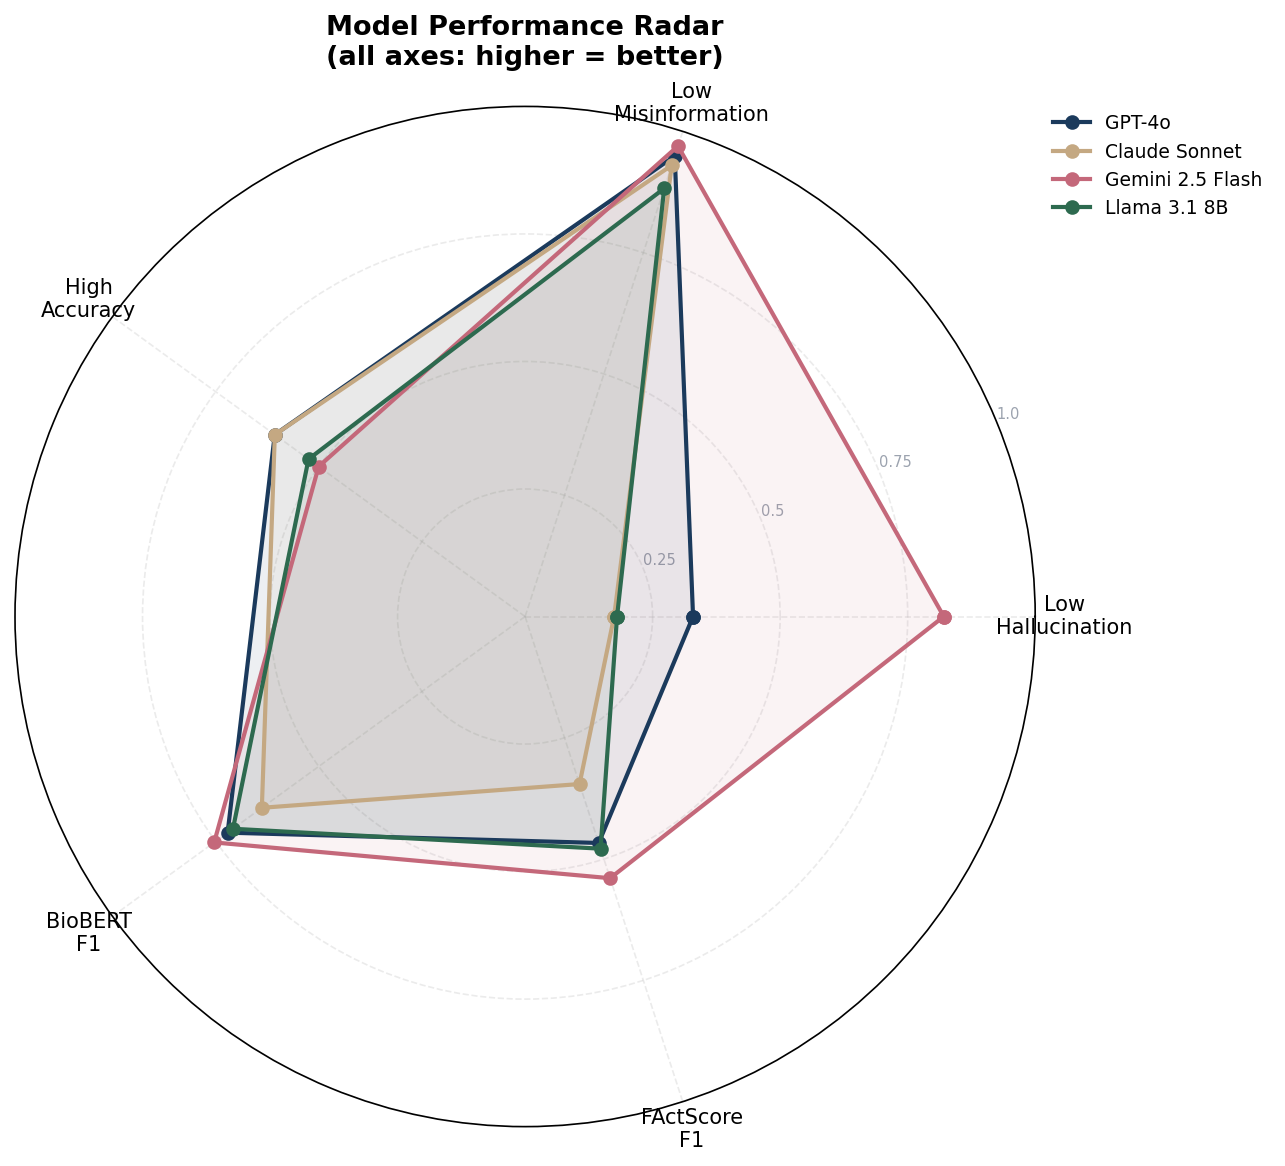

In [39]:
# radar chart
categories = ['Low\nHallucination', 'Low\nMisinformation', 'High\nAccuracy',
              'BioBERT\nF1', 'FActScore\nF1']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

radar_data = {}
for m in MODEL_ORDER:
    r = performance_summary.loc[m]
    radar_data[m] = [
        1 - r['hallucination_rate'],
        1 - r['misinformation_rate'],
        r['mean_accuracy'] / 2,
        r['mean_biobert'],
        r['mean_factscore'],
    ]

fig = plt.figure(figsize=(11, 8.5))
ax = fig.add_subplot(111, polar=True)
for model, vals in radar_data.items():
    v = vals + vals[:1]
    ax.plot(angles, v, 'o-', linewidth=2, color=MODEL_COLORS[model], label=model)
    ax.fill(angles, v, alpha=0.08, color=MODEL_COLORS[model])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=7, color='#9ca3af')
ax.set_title('Model Performance Radar\n(all axes: higher = better)', fontweight='bold', pad=20)
ax.legend(loc='center left', bbox_to_anchor=(1.12, 0.5), borderaxespad=0)
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_17_model_radar.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---
## Treatment Effect Summary - Forest Plot

*Summarises treatment effect sizes and clustered uncertainty in a forest plot.*


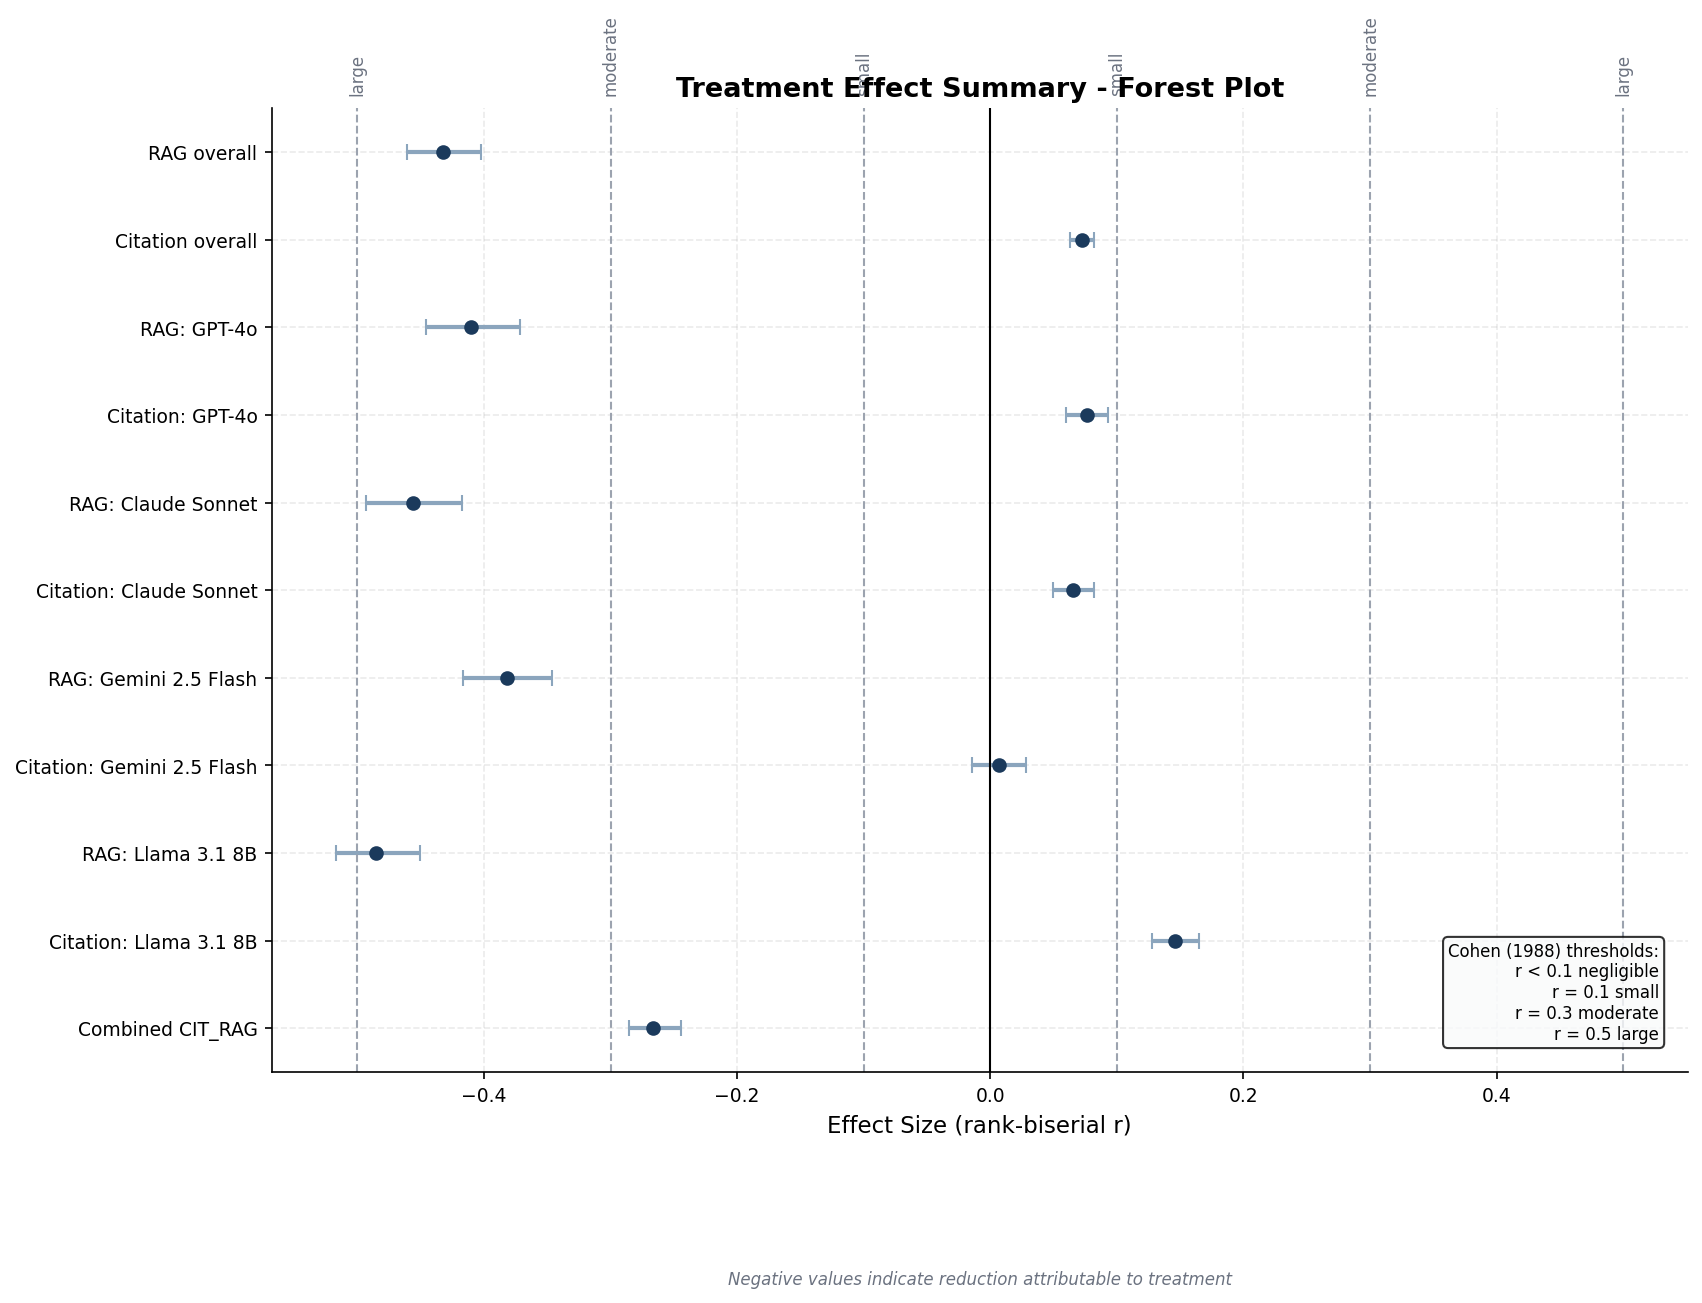

In [40]:
def bootstrap_effect_ci(df_in, treatment_col, outcome_col='accuracy_consensus', treated_value=True, cluster_col='item_id', n_resamples=1000):
    rng = np.random.default_rng(RANDOM_SEED)
    clusters = df_in[cluster_col].dropna().unique()
    grouped = {c: g for c, g in df_in.groupby(cluster_col)}
    effects = []
    for _ in range(n_resamples):
        sample_clusters = rng.choice(clusters, size=len(clusters), replace=True)
        boot = pd.concat([grouped[c] for c in sample_clusters], ignore_index=True)
        treated = boot[boot[treatment_col].eq(treated_value)][outcome_col].dropna()
        control = boot[~boot[treatment_col].eq(treated_value)][outcome_col].dropna()
        if len(treated) and len(control):
            u, _ = mannwhitneyu(treated, control, alternative='two-sided')
            effects.append(rank_biserial(u, len(treated), len(control)))
    return np.percentile(effects, [2.5, 97.5]) if effects else (np.nan, np.nan)

forest_rows = []
for label, subset, treatment_col in [('RAG overall', df, 'rag'), ('Citation overall', df, 'citation')]:
    treated = subset[subset[treatment_col]]['accuracy_consensus'].dropna()
    control = subset[~subset[treatment_col]]['accuracy_consensus'].dropna()
    u, _ = mannwhitneyu(treated, control, alternative='two-sided')
    r = rank_biserial(u, len(treated), len(control))
    lo, hi = bootstrap_effect_ci(subset, treatment_col)
    forest_rows.append({'Comparison': label, 'r': r, 'ci_low': lo, 'ci_high': hi})
for model in MODEL_ORDER:
    for label, treatment_col in [('RAG', 'rag'), ('Citation', 'citation')]:
        subset = df[df['model_label'].eq(model)]
        treated = subset[subset[treatment_col]]['accuracy_consensus'].dropna()
        control = subset[~subset[treatment_col]]['accuracy_consensus'].dropna()
        u, _ = mannwhitneyu(treated, control, alternative='two-sided')
        r = rank_biserial(u, len(treated), len(control))
        lo, hi = bootstrap_effect_ci(subset, treatment_col)
        forest_rows.append({'Comparison': f'{label}: {model}', 'r': r, 'ci_low': lo, 'ci_high': hi})
combined = df.assign(is_cit_rag=df['strategy_name'].eq('CIT_RAG'))
treated = combined[combined['is_cit_rag']]['accuracy_consensus'].dropna()
control = combined[~combined['is_cit_rag']]['accuracy_consensus'].dropna()
u, _ = mannwhitneyu(treated, control, alternative='two-sided')
r = rank_biserial(u, len(treated), len(control))
lo, hi = bootstrap_effect_ci(combined, 'is_cit_rag')
forest_rows.append({'Comparison': 'Combined CIT_RAG', 'r': r, 'ci_low': lo, 'ci_high': hi})

forest_df = pd.DataFrame(forest_rows)
fig, ax = plt.subplots(figsize=(14, 9.5))
y = np.arange(len(forest_df))
ax.errorbar(forest_df['r'], y, xerr=[forest_df['r']-forest_df['ci_low'], forest_df['ci_high']-forest_df['r']],
            fmt='o', color=OUTCOME_COLORS['accurate'], ecolor='#8BA5BD', elinewidth=2, capsize=4)
ax.axvline(0, color='black', linewidth=1)
for xref, label in [(-0.5, 'large'), (-0.3, 'moderate'), (-0.1, 'small'), (0.1, 'small'), (0.3, 'moderate'), (0.5, 'large')]:
    ax.axvline(xref, color='#9ca3af', linestyle='--', linewidth=1)
    ax.text(xref, -0.65, label, rotation=90, ha='center', va='bottom', fontsize=8, color='#6b7280')
ax.set_yticks(y)
ax.set_yticklabels(forest_df['Comparison'])
ax.invert_yaxis()
ax.set_xlabel('Effect Size (rank-biserial r)')
ax.set_title('Treatment Effect Summary - Forest Plot', fontweight='bold')
ax.text(0.98, 0.03, "Cohen (1988) thresholds:\nr < 0.1 negligible\nr = 0.1 small\nr = 0.3 moderate\nr = 0.5 large", transform=ax.transAxes, ha='right', va='bottom', fontsize=8, bbox=dict(boxstyle='round', facecolor='#f9fafb', alpha=0.8))
plt.subplots_adjust(wspace=0.35, hspace=0.35)
standardize_figure(fig)
plt.savefig('charts/chart_19_treatment_effect_forest_plot.png', bbox_inches='tight')
plt.show()
plt.close(fig)


---

## RQ and Hypothesis Verdicts

*Generates a programmatic verdict table linking each hypothesis to the computed statistical evidence.*

The table below is generated from the statistical objects computed in the preceding sections so the verdicts remain tied to the notebook outputs.


In [41]:
# ── Recompute stats needed for verdicts from data directly ───────────────────
# H2.1 (RAG)
ct_h21_h = df.groupby(['hallucination_label','rag']).size().unstack(fill_value=0)
ct_h21_m = df.groupby(['misinformation_label','rag']).size().unstack(fill_value=0)
_, p_h21_h, _, _ = chi2_contingency(ct_h21_h)
_, p_h21_m, _, _ = chi2_contingency(ct_h21_m)
u_h21_a, p_h21_a = mannwhitneyu(
    with_rag['accuracy_consensus'].dropna(),
    no_rag['accuracy_consensus'].dropna(),
    alternative='two-sided')

h21_hallu_ok   = (with_rag['hallucination_label'].mean()  < no_rag['hallucination_label'].mean())  and (p_h21_h < 0.05)
h21_misinfo_ok = (with_rag['misinformation_label'].mean() < no_rag['misinformation_label'].mean()) and (p_h21_m < 0.05)
h21_acc_ok     = (with_rag['accuracy_consensus'].mean()   > no_rag['accuracy_consensus'].mean())   and (p_h21_a < 0.05)

_h21_labels = ['hallucination reduction', 'misinformation reduction', 'accuracy improvement']
_h21_checks = [h21_hallu_ok, h21_misinfo_ok, h21_acc_ok]
_h21_confirmed = [l for l, c in zip(_h21_labels, _h21_checks) if c]
_h21_n = len(_h21_confirmed)

if _h21_n == 3:
    h21_verdict = f"Supported — all three outcomes confirmed: {', '.join(_h21_confirmed)}"
elif _h21_n > 0:
    h21_verdict = f"Partially Supported — confirmed: {', '.join(_h21_confirmed)}"
else:
    h21_verdict = "Not Supported — none of the three predicted outcomes confirmed"

# H2.3 (Citation)
ct_h23_h = df.groupby(['hallucination_label','citation']).size().unstack(fill_value=0)
ct_h23_m = df.groupby(['misinformation_label','citation']).size().unstack(fill_value=0)
_, p_h23_h, _, _ = chi2_contingency(ct_h23_h)
_, p_h23_m, _, _ = chi2_contingency(ct_h23_m)
u_h23_a, p_h23_a = mannwhitneyu(
    with_cit['accuracy_consensus'].dropna(),
    no_cit['accuracy_consensus'].dropna(),
    alternative='two-sided')

h23_hallu_ok   = (with_cit['hallucination_label'].mean()  < no_cit['hallucination_label'].mean())  and (p_h23_h < 0.05)
h23_misinfo_ok = (with_cit['misinformation_label'].mean() < no_cit['misinformation_label'].mean()) and (p_h23_m < 0.05)
h23_acc_ok     = (with_cit['accuracy_consensus'].mean()   > no_cit['accuracy_consensus'].mean())   and (p_h23_a < 0.05)

_h23_labels = ['hallucination reduction', 'misinformation reduction', 'accuracy improvement']
_h23_checks = [h23_hallu_ok, h23_misinfo_ok, h23_acc_ok]
_h23_confirmed = [l for l, c in zip(_h23_labels, _h23_checks) if c]
_h23_n = len(_h23_confirmed)

if _h23_n == 3:
    h23_verdict = f"Supported — all three outcomes confirmed: {', '.join(_h23_confirmed)}"
elif _h23_n > 0:
    h23_verdict = f"Partially Supported — confirmed: {', '.join(_h23_confirmed)}"
else:
    h23_verdict = "Not Supported — none of the three predicted outcomes confirmed"

# H2.4 (CIT_RAG vs all other conditions)
cond_overall = df.groupby('strategy_name').agg(
    hallucination_rate  = ('hallucination_label',  'mean'),
    misinformation_rate = ('misinformation_label', 'mean'),
    accuracy_mean       = ('accuracy_consensus',   'mean'),
)
h24_hallu_ok   = cond_overall['hallucination_rate'].idxmin()  == 'CIT_RAG'
h24_misinfo_ok = cond_overall['misinformation_rate'].idxmin() == 'CIT_RAG'
h24_acc_ok     = cond_overall['accuracy_mean'].idxmax()       == 'CIT_RAG'

_h24_labels = ['lowest hallucination', 'lowest misinformation', 'highest accuracy']
_h24_checks = [h24_hallu_ok, h24_misinfo_ok, h24_acc_ok]
_h24_confirmed = [l for l, c in zip(_h24_labels, _h24_checks) if c]
_h24_n = len(_h24_confirmed)

if _h24_n == 3:
    h24_verdict = f"Supported — CIT_RAG leads on all three: {', '.join(_h24_confirmed)}"
elif _h24_n > 0:
    h24_verdict = f"Partially Supported — CIT_RAG leads on: {', '.join(_h24_confirmed)}"
else:
    h24_verdict = "Not Supported — CIT_RAG does not lead on any of the three outcomes"

# ── Helper values for key evidence ───────────────────────────────────────────
commercial_delta_mean = commercial_delta.mean() if 'commercial_delta' in globals() else np.nan
opensource_delta_mean = opensource_delta.mean() if 'opensource_delta' in globals() else np.nan

r_acc_h21 = rank_biserial(u_h21_a,
    len(with_rag['accuracy_consensus'].dropna()),
    len(no_rag['accuracy_consensus'].dropna()))

r_acc_h23 = rank_biserial(u_h23_a,
    len(with_cit['accuracy_consensus'].dropna()),
    len(no_cit['accuracy_consensus'].dropna()))

# ── Verdicts DataFrame ────────────────────────────────────────────────────────
verdicts = pd.DataFrame([
    {
        'ID': 'RQ1',
        'Hypothesis': 'Extent of hallucination, inaccuracy, and misinformation',
        'Verdict': 'Characterised',
        'Key Evidence': (f"Mean hallucination={df['hallucination_label'].mean():.3f}; "
                         f"mean accuracy={df['accuracy_consensus'].mean():.3f}"),
    },
    {
        'ID': 'H2.1',
        'Hypothesis': 'RAG reduces hallucination, misinformation, and improves accuracy',
        'Verdict': h21_verdict,
        'Key Evidence': (f"Hallu delta={with_rag['hallucination_label'].mean()-no_rag['hallucination_label'].mean():+.3f} (p={p_h21_h:.4f}); "
                         f"Misinfo delta={with_rag['misinformation_label'].mean()-no_rag['misinformation_label'].mean():+.3f} (p={p_h21_m:.4f}); "
                         f"Acc delta={with_rag['accuracy_consensus'].mean()-no_rag['accuracy_consensus'].mean():+.3f} (p={p_h21_a:.4f}, r={r_acc_h21:.3f})"),
    },
    {
        'ID': 'H2.2',
        'Hypothesis': 'Effects stronger for smaller/open-source models',
        'Verdict': 'Descriptive Only — single open-source model precludes formal test',
        'Key Evidence': f'Llama delta={opensource_delta_mean:+.3f}; Commercial mean={commercial_delta_mean:+.3f}',
    },
    {
        'ID': 'H2.3',
        'Hypothesis': 'Citation prompting reduces hallucination, misinformation, and improves accuracy',
        'Verdict': h23_verdict,
        'Key Evidence': (f"Hallu delta={with_cit['hallucination_label'].mean()-no_cit['hallucination_label'].mean():+.3f} (p={p_h23_h:.4f}); "
                         f"Misinfo delta={with_cit['misinformation_label'].mean()-no_cit['misinformation_label'].mean():+.3f} (p={p_h23_m:.4f}); "
                         f"Acc delta={with_cit['accuracy_consensus'].mean()-no_cit['accuracy_consensus'].mean():+.3f} (p={p_h23_a:.4f}, r={r_acc_h23:.3f})"),
    },
    {
        'ID': 'H2.4',
        'Hypothesis': 'CIT_RAG achieves lowest hallucination, lowest misinformation, highest accuracy',
        'Verdict': h24_verdict,
        'Key Evidence': (f"Lowest hallu condition={cond_overall['hallucination_rate'].idxmin()} "
                         f"({cond_overall['hallucination_rate'].min():.3f}); "
                         f"Lowest misinfo condition={cond_overall['misinformation_rate'].idxmin()} "
                         f"({cond_overall['misinformation_rate'].min():.3f}); "
                         f"Highest acc condition={cond_overall['accuracy_mean'].idxmax()} "
                         f"({cond_overall['accuracy_mean'].max():.3f})"),
    },
])
display(verdicts)


,ID,Hypothesis,Verdict,Key Evidence
0,RQ1,"Extent of hallucination, inaccuracy, and misin...",Characterised,Mean hallucination=0.624; mean accuracy=1.119
1,H2.1,"RAG reduces hallucination, misinformation, and...",Partially Supported — confirmed: misinformatio...,Hallu delta=+0.134 (p=0.0000); Misinfo delta=-...
2,H2.2,Effects stronger for smaller/open-source models,Descriptive Only — single open-source model pr...,Llama delta=+0.514; Commercial mean=+0.448
3,H2.3,"Citation prompting reduces hallucination, misi...",Not Supported — none of the three predicted ou...,Hallu delta=+0.258 (p=0.0000); Misinfo delta=+...
4,H2.4,"CIT_RAG achieves lowest hallucination, lowest ...",Not Supported — CIT_RAG does not lead on any o...,Lowest hallu condition=ZS_NoRAG (0.381); Lowes...


---
## Limitations

*States the methodological constraints that bound interpretation and generalisability.*

This analysis has several important limitations. First, the inferential tests treat response-level observations as independent even though each of the same 1,000 items appears across multiple model-condition combinations. Clustered bootstrap confidence intervals reduce this problem for uncertainty estimates, but mixed-effects models with random intercepts for `item_id` would be the more rigorous approach. A mixed-effects logistic regression with random intercepts for item_id would provide the most rigorous treatment of this clustering structure and represents the natural methodological extension of this work. Second, H2.2 cannot be generalised as a model-size finding because the study includes only one open-source small model, Llama 3.1 8B. Third, the judge panel has potential circularity because three of the four judges are also evaluated models; the DeepSeek-only sensitivity analysis is included to assess whether this materially changes the conclusions. Fourth, RAG context quality is not experimentally controlled, so retrieval length and relevance may confound the observed RAG effects. Fifth, MedHallu category imbalance, especially dominance by "Misinterpretation of Question", may shape aggregate rates. Sixth, ground truths derived from PubMed abstracts may themselves be incomplete or contested in fast-moving clinical domains. Finally, external validity is bounded by four models, 1,000 questions, and a single medical QA benchmark.


---
## Ethical Considerations

*Frames the patient-safety and responsible-deployment implications of residual hallucination and misinformation.*

Even the highest-performing condition in this benchmark retains a non-trivial hallucination rate: under `CIT_RAG`, the lowest observed hallucination rate is 44.6% for Gemini 2.5 Flash. This residual error rate is incompatible with autonomous clinical deployment. The models evaluated here should therefore be treated as decision-support systems only, with mandatory human oversight, explicit uncertainty communication, and clinical review before any answer informs patient care.

As a Responsible Data Science study, this analysis must also account for the asymmetry of harm in medical question answering. A false negative, such as missing a diagnosis or omitting a contraindication, can be categorically more harmful than a false positive because it may delay treatment or falsely reassure a patient. Even comparatively low misinformation rates can compound over millions of real-world queries, creating population-level risk from individually rare failures.

Benchmark performance should not be interpreted as clinical validity. Prospective validation in real clinical workflows is required before deployment, including evaluation with clinicians, patient-safety monitoring, and task-specific risk assessment. The use of a multi-judge panel in this study models a responsible evaluation approach because it reduces reliance on a single evaluator and partially mitigates single-source bias, although it does not eliminate the need for human expert validation.


---
## Narrative Conclusion

*Synthesises the results into an academic interpretation suitable for the final report.*

Retrieval-augmented generation was associated with a statistically significant improvement in accuracy overall, with the Mann-Whitney test for H2.1 yielding p < 0.0001 and a rank-biserial effect size of r = -0.432, a moderate effect where the sign reflects the ordering of the test groups. The mean accuracy score increased from 0.887 without RAG to 1.351 with RAG, indicating that retrieval was associated with a substantial gain in answer correctness across the full benchmark.

However, RAG did not uniformly reduce hallucination. The hallucination delta chart shows that RAG increased hallucination for GPT-4o (+0.195), Gemini 2.5 Flash (+0.288), Claude Sonnet (+0.007), and Llama 3.1 8B (+0.048). This pattern indicates that retrieval can improve ordinal accuracy while still increasing unsupported or over-extended claims, especially when models integrate retrieved context imperfectly or use it to justify claims beyond the evidence.

Citation prompting is therefore useful but not sufficient as a safety mechanism. H2.3 provides evidence of an overall citation effect on hallucination, with Cramer's V = 0.266, a small-to-moderate association, but the direction and magnitude are model dependent. The fake-citation analysis also shows that citation requirements can produce fabricated references, particularly in citation-only settings, so citation prompting is most defensible when combined with high-quality retrieval and verification rather than used as a superficial formatting constraint.

The comparative performance summary does not identify a universally dominant model. GPT-4o has the highest mean accuracy in the study (1.213), narrowly ahead of Claude Sonnet, while Gemini 2.5 Flash has the lowest overall hallucination rate (0.179) and the lowest `CIT_RAG` hallucination rate (0.446). For medical QA, this means reliability depends on the operational priority: GPT-4o is strongest on average accuracy, whereas Gemini is stronger when hallucination minimisation is treated as the primary safety criterion.

The difficulty findings suggest that retrieval is most practically valuable on harder questions. RAG produced the largest accuracy gain for hard questions (+0.573), compared with medium (+0.441) and easy (+0.329) questions. This implies that retrieval is most useful when questions require evidence integration beyond the model's internal parametric knowledge, but the simultaneous hallucination increases show that retrieval quality and response discipline remain essential.

The three most important next research steps are methodological and empirical. First, mixed-effects modelling should be used to account for repeated observations clustered by `item_id`. Second, H2.2 should be replicated with multiple open-source models across size tiers so that model-size moderation can be tested rather than described. Third, future work should add controlled retrieval-quality annotations so that context relevance, coverage, and contradiction can be separated from the effect of RAG as a prompting condition.


---

## Charts Index

| # | File | Section |
|---|---|---|
| 01 | `chart_01_overall_distributions.png` | Dataset overview |
| 02 | `chart_02_rates_by_model.png` | RQ1 — hallucination & misinformation rates |
| 03 | `chart_03_accuracy_by_model.png` | RQ1 — accuracy distribution & violin |
| 04 | `chart_04_rq2_overview_heatmap.png` | RQ2 — orientation heatmap |
| 05 | `chart_05_h21_rag_effect.png` | H2.1 — RAG vs no-RAG per model |
| 06 | `chart_06_h21_rag_delta.png` | H2.1 — RAG delta waterfall |
| 07 | `chart_07_h22_model_size_moderation.png` | H2.2 — RAG/citation delta by model size |
| 08 | `chart_08_h22_interaction_rag.png` | H2.2 — Interaction plot |
| 09 | `chart_09_h23_citation_effect.png` | H2.3 — Citation effect per model |
| 10 | `chart_10_h23_citation_detail.png` | H2.3 — Fake citations & delta |
| 11 | `chart_11_h24_all_conditions.png` | H2.4 — All 4 conditions × all 4 models |
| 12 | `chart_12_h24_interaction_profile.png` | H2.4 — Interaction profile |
| 13 | `chart_13_difficulty_category.png` | RQ2 — Difficulty & category analysis |
| 14 | `chart_14_difficulty_rag_moderation.png` | RQ2 — RAG moderated by difficulty |
| 15 | `chart_15_automated_signals.png` | Automated signals (BioBERT, FActScore) |
| 16 | `chart_16_judge_panel.png` | Judge panel analysis |
| 17 | `chart_17_model_radar.png` | Comparative performance radar |
| 18 | `chart_18_signal_outcome_correlation.png` | Signal-outcome correlation matrix |
| 19 | `chart_19_treatment_effect_forest_plot.png` | Treatment effect forest plot |

---

*MedHAM Analysis Notebook — Hussam Alqahtani*
